# F410M − F480M vs F480M − F560W color-color diagram

Combines NIRCam (F410M, F480M) and MIRI (F560W) photometry from the
cleaned W51 catalog (`nmatch_bands > 3`). Shows the CT06 (Chiar & Tielens
2006, Milky Way local-ISM) mid-IR dust extinction vector and a pure-blackbody
color locus for reference, then tests whether sources on the red side of
F480M − F560W form a physically distinct population (different spatial
distribution, A_V, or other properties) from the bulk of sources.

In [1]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)
os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits
from dust_extinction.averages import CT06_MWLoc

plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.linewidth'] = 3
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.major.width'] = 3
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.major.width'] = 3

ext = CT06_MWLoc()

In [2]:
image_filenames = {
    "f162m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits",
    "f480m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
}

catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits')
catalog = catalog[catalog['nmatch_bands'] > 3]
print(f'{len(catalog)} sources after the nmatch_bands>3 cleancat cut')

def get_mag(catalog, ww, filtername):
    """Vega magnitude from the catalog's native MJy/sr surface-brightness flux,
    matching the convention already used for the *_vegamag columns baked into
    this catalog (verified to agree to <1e-10 mag for filters that have both)."""
    flux = (catalog['flux_fit_' + filtername] * u.MJy / u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux = (catalog['flux_err_' + filtername] * u.MJy / u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    inst = 'NIRCam' if int(filtername[1:-1]) < 500 else 'MIRI'
    zp = u.Quantity(jfilts.loc[f'JWST/{inst}.{filtername.upper()}']['ZeroPoint'], u.Jy)
    mag = (-2.5 * np.log10(flux / zp)).value
    magerr = (2.5 / np.log(10) * np.abs(eflux / flux)).value
    return mag, magerr, zp

headers = {f: fits.getheader(image_filenames[f], ext=('SCI', 1)) for f in image_filenames}
mags, magerrs, zps = {}, {}, {}
for f in image_filenames:
    mags[f], magerrs[f], zps[f] = get_mag(catalog, WCS(headers[f]), f)
    print(f, 'zero point (Vega) =', zps[f], ' n finite =', np.isfinite(mags[f]).sum())

f162, f210, f360, f410, f480, f560, f770, f405n = mags['f162m'], mags['f210m'], mags['f360m'], mags['f410m'], mags['f480m'], mags['f560w'], mags['f770w'], mags['f405n']

15004 sources after the nmatch_bands>3 cleancat cut


Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:06:02.819' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


f162m zero point (Vega) = 1023.0385411698 Jy  n finite = 12582
f210m zero point (Vega) = 688.03251394796 Jy  n finite = 14384
f360m zero point (Vega) = 260.30648962313 Jy  n finite = 11878
f410m zero point (Vega) = 208.75045059896 Jy  n finite = 11469
f480m zero point (Vega) = 153.22388044927 Jy  n finite = 9964
f560w zero point (Vega) = 115.28910738511 Jy  n finite = 2179


f770w zero point (Vega) = 65.079869393146 Jy  n finite = 637
f405n zero point (Vega) = 206.96939908611 Jy  n finite = 8199


/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T16:06:02.828' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/f

## A$_V$ estimate

Same isochrone + extinction-vector geometry method used throughout the other
CMD/CCD notebooks in this project: a zero-age (log age = 6) PARSEC isochrone
line in F162M−F210M vs F162M defines the unreddened locus, and each
source's A$_V$ is the distance from that locus to the source along the CT06
reddening vector anchored at F162M.

In [3]:
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
m_init = parsec_av0['col4']
parsec_av0 = parsec_av0[m_init < 300]
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']
F162Mmag_av0 = parsec_av0['col40'] + 5 * np.log10(5400) - 5
F210Mmag_av0 = parsec_av0['col42'] + 5 * np.log10(5400) - 5

age_idx = logage_av0 == 6
idx_01msun = np.argmin(np.abs(mass_av0[age_idx] - 0.1))
idx_20msun = np.argmin(np.abs(mass_av0[age_idx] - 20))
isochrone_x_start = F162Mmag_av0[age_idx][idx_01msun] - F210Mmag_av0[age_idx][idx_01msun]
isochrone_x_end = F162Mmag_av0[age_idx][idx_20msun] - F210Mmag_av0[age_idx][idx_20msun]
isochrone_y_start = F162Mmag_av0[age_idx][idx_01msun]
isochrone_y_end = F162Mmag_av0[age_idx][idx_20msun]
color_slope = (isochrone_y_end - isochrone_y_start) / (isochrone_x_end - isochrone_x_start)
color_intercept = isochrone_y_start - color_slope * isochrone_x_start

def get_av(color, mag, ext, color1, mag1, isochrone_line_params):
    m_iso, b_iso = isochrone_line_params
    w_color1_1 = int(color1[0][1:-1]) / 100 * u.um
    w_color1_2 = int(color1[1][1:-1]) / 100 * u.um
    w_mag1 = int(mag1[0][1:-1]) / 100 * u.um
    e_color1_1, e_color1_2, e_mag1 = ext(1 / w_color1_1), ext(1 / w_color1_2), ext(1 / w_mag1)
    m_ext = e_mag1 / (e_color1_1 - e_color1_2)
    b_ext = mag - m_ext * color
    x_int = (b_ext - b_iso) / (m_iso - m_ext)
    y_int = m_iso * x_int + b_iso
    av = (mag - y_int) / ext(1 / w_mag1)
    av[av < 0] = 0
    return av

av_estimate = get_av(f162 - f210, f162, ext, ('f162m', 'f210m'), ('f162m',),
                      (color_slope, color_intercept))

# demarcation line separating embedded W51 sources from foreground field stars
# in F162M-F210M vs F162M (same line used in the other CMD/CCD notebooks)
line_slope = (27 - 7) / (1.3 - 0.4)
line_intercept = 7 - line_slope * 0.4
idx_red_sources = f162 - (line_slope * (f162 - f210) + line_intercept) < 0
print(f'{idx_red_sources.sum()} sources are on the embedded/reddened side of the F162M-F210M demarcation line')

3780 sources are on the embedded/reddened side of the F162M-F210M demarcation line


## Populations from color_magnitude_diagram_cleancat.ipynb

For reference, reproduces the same three population definitions used in
`color_magnitude_diagram_cleancat.ipynb` (the F360M/F480M vs F162M/F210M
notebook), using this notebook's own `f162`, `f210`, `f480`, and
`av_estimate` (identical method) plus `f360` computed here for the
F360M−F480M diagnostic color that notebook is built around:

- **upper branch**: F360M−F480M above the diagonal cut, at A>12$
- **lower branch**: F360M−F480M at or below the diagonal cut, at A>12$
- **very red / NIR-dropout sources**: no F162M or F210M detection at all,
  and F360M−F480M $>1.5$

These are overlaid on this notebook's F480M−F560W vs F410M−F480M
diagram below to see whether the same three groups separate here too.

In [4]:
upper_idx = (f360 - f480 > 0.15 + (1.5 / 6) * (f162 - f210)) & (av_estimate > 12)
lower_idx = (f360 - f480 <= 0.15 + (1.5 / 6) * (f162 - f210)) & (av_estimate > 12)
missing_nir_idx = ~np.isfinite(f162) | ~np.isfinite(f210)
missing_nir_idx_red = missing_nir_idx & (f360 - f480 > 1.5)

print('upper branch:', np.sum(upper_idx))
print('lower branch:', np.sum(lower_idx))
print('very red / NIR-dropout sources:', np.sum(missing_nir_idx_red))

upper branch: 1106
lower branch: 2260
very red / NIR-dropout sources: 466


## Color-color diagram: F480M − F560W vs F410M − F480M

The CT06 vector and a pure-blackbody locus (Planck function averaged over
each filter's full SVO bandpass, then ratioed between filters, so it needs no
assumption about stellar radius or distance) are overplotted for reference.

CT06 reddening-vector slope (dy/dx): 1.496556274912684
blackbody-locus local slope range: 0.725279100522405 - 1.3862965759362922
vector slope exceeds the locus slope everywhere: True


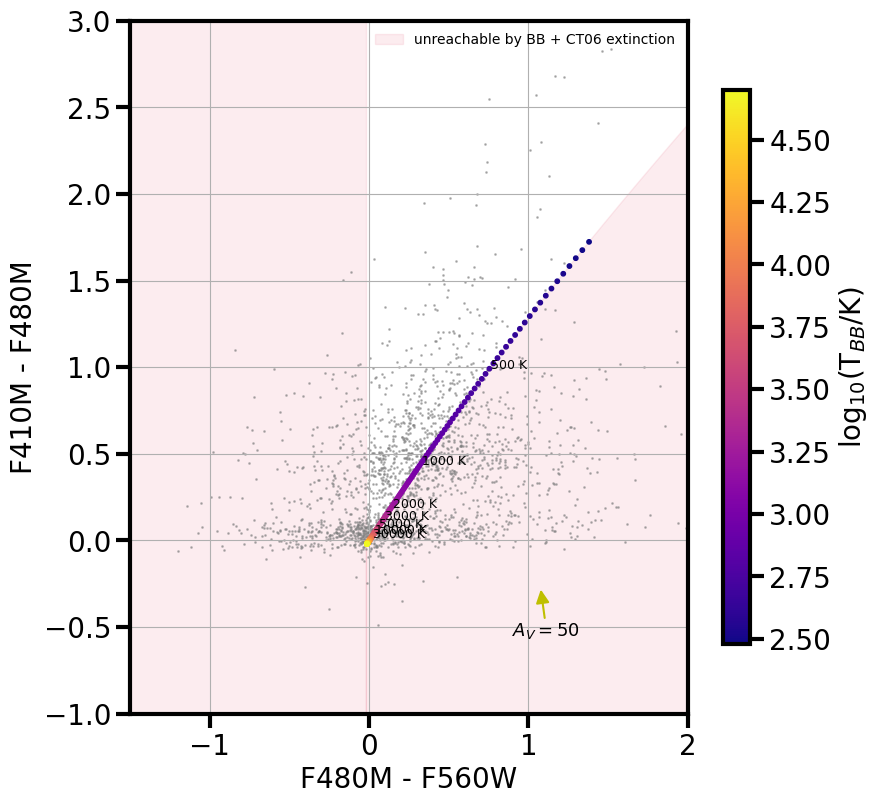

In [5]:
def get_wave(c):
    return int(c[1:-1]) / 100 * u.um

def plot_extvec_ccd(ax, color1, color2, ext, extvec_scale=30, start=None,
                     color='y', label=None, fontsize=13):
    w1, w2 = get_wave(color1[0]), get_wave(color1[1])
    w3, w4 = get_wave(color2[0]), get_wave(color2[1])
    if w1 > w2:
        w1, w2 = w2, w1
    if w3 > w4:
        w3, w4 = w4, w3
    e_1, e_2 = ext(1 / w1) * extvec_scale, ext(1 / w2) * extvec_scale
    e_3, e_4 = ext(1 / w3) * extvec_scale, ext(1 / w4) * extvec_scale
    ax.annotate(f'$A_V={extvec_scale}$', xy=(start[0] + (e_1 - e_2), start[1] + (e_3 - e_4)),
                xytext=start, fontsize=fontsize,
                arrowprops=dict(arrowstyle='-|>', color=color, shrinkA=0, shrinkB=0,
                                 mutation_scale=20, linewidth=1.5))
    if label is not None:
        ax.plot([], [], color=color, marker='>', markersize=8, label=label,
                linestyle='-', linewidth=2)

_bandpasses = {}

def get_bandpass(filtername):
    """SVO transmission curve (wavelength, throughput) for a JWST filter, cached."""
    if filtername not in _bandpasses:
        inst = 'NIRCam' if int(filtername[1:-1]) < 500 else 'MIRI'
        ttab = SvoFps.get_transmission_data(f'JWST/{inst}.{filtername.upper()}')
        _bandpasses[filtername] = (ttab['Wavelength'].quantity.to(u.um),
                                   np.asarray(ttab['Transmission'], dtype=float))
    return _bandpasses[filtername]

def bb_band_flux(T_grid, filtername):
    """Band-averaged F_nu of a unit blackbody for each T in T_grid.
    Photon-counting average <F_nu> = int F_nu S dlam/lam / int S dlam/lam,
    the same convention as the SVO Vega zero points and the JWST pipeline's
    flux calibration, so the result can be divided directly by zps[filtername].
    """
    from astropy.modeling.models import BlackBody
    wav, trans = get_bandpass(filtername)
    bb = BlackBody(temperature=np.atleast_1d(T_grid)[:, None] * u.K)
    fnu = bb(wav[None, :]).to(u.Jy / u.sr).value
    weight = trans / wav.value
    return np.trapezoid(fnu * weight, wav.value, axis=1) / np.trapezoid(weight, wav.value)

def bb_locus(T_grid, filt1, filt2, filt3):
    """Color-color locus of a pure blackbody, sweeping temperature:
    x = filt2 - filt3, y = filt1 - filt2 (Vega mag).
    Integrates the Planck function over each filter's full bandpass instead
    of evaluating it at a single nominal wavelength -- this matters for cool
    blackbodies, whose steep Wien tail shifts the flux-weighted wavelength
    toward each filter's red edge (most strongly for the wide MIRI bands).
    Uses flux-density RATIOS between filters, so no stellar radius, distance,
    or extinction is needed -- those cancel between filters at fixed T.
    """
    m1, m2, m3 = [-2.5 * np.log10(bb_band_flux(T_grid, f) / zps[f].to(u.Jy).value)
                  for f in (filt1, filt2, filt3)]
    return m2 - m3, m1 - m2

color_x = f480 - f560   # F480M - F560W
color_y = f410 - f480   # F410M - F480M

# Extended temperature grid (30 K - 2x10^5 K) so the locus safely spans the
# full observed color range on both the hot/blue and cool/red ends -- this
# same locus is reused below to test whether sources CAN be reproduced by
# blackbody + extinction at all.
T_grid_wide = np.logspace(np.log10(30), np.log10(2e5), 500)
bb_x, bb_y = bb_locus(T_grid_wide, 'f410m', 'f480m', 'f560w')

# sorted-by-x version of the locus, for interpolating "curve y at a given x"
_order = np.argsort(bb_x)
bb_x_sorted, bb_y_sorted = bb_x[_order], bb_y[_order]
bb_local_slope = np.gradient(bb_y_sorted, bb_x_sorted)

dx_per_av = (ext(1 / get_wave('f480m')) - ext(1 / get_wave('f560w')))
dy_per_av = (ext(1 / get_wave('f410m')) - ext(1 / get_wave('f480m')))
vec_slope = dy_per_av / dx_per_av
print('CT06 reddening-vector slope (dy/dx):', vec_slope)
print('blackbody-locus local slope range:', bb_local_slope.min(), '-', bb_local_slope.max())
print('vector slope exceeds the locus slope everywhere:', bool(np.all(bb_local_slope < vec_slope)))
# Because the reddening vector is STEEPER than the locus everywhere, adding
# any amount of positive A_V to any point on the locus always moves it to
# lie ABOVE the locus (larger F410M-F480M at fixed F480M-F560W), never
# below. So: a source below this curve cannot be produced by ANY blackbody
# temperature reddened by ANY amount of CT06 extinction -- see the
# classification section below.

T_grid_plot = np.logspace(np.log10(300), np.log10(50000), 200)
bb_x_plot, bb_y_plot = bb_locus(T_grid_plot, 'f410m', 'f480m', 'f560w')

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111)

# shade the region that is UNREACHABLE by any blackbody + non-negative CT06
# extinction: below the locus (in y, at fixed x), plus everything bluer in
# x than the hottest blackbody in the grid (x < bb_x_sorted.min())
ylo = -1.5
ax.fill_between(bb_x_sorted, ylo, bb_y_sorted, color='crimson', alpha=0.08,
                 zorder=0, label='unreachable by BB + CT06 extinction')
ax.axvspan(-2.5, bb_x_sorted.min(), color='crimson', alpha=0.08, zorder=0)

ax.scatter(color_x, color_y, s=1, c='gray', alpha=0.5)

sc = ax.scatter(bb_x_plot, bb_y_plot, c=np.log10(T_grid_plot), cmap='plasma', s=10, zorder=3)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label(r'log$_{10}$(T$_{BB}$/K)')
for Tmark in [500, 1000, 2000, 3000, 5000, 10000, 30000]:
    i = np.argmin(np.abs(T_grid_plot - Tmark))
    ax.annotate(f'{Tmark} K', (bb_x_plot[i], bb_y_plot[i]), fontsize=9, color='k',
                textcoords='offset points', xytext=(4, 4))

plot_extvec_ccd(ax, ('f480m', 'f560w'), ('f410m', 'f480m'), ext,
                 extvec_scale=50, start=(0.9, -0.55), color='y')

ax.grid()
ax.set_xlabel('F480M - F560W')
ax.set_ylabel('F410M - F480M')
ax.set_xlim(-1.5, 2)
ax.set_ylim(-1, 3)
ax.legend(fontsize=10, frameon=False, loc='upper right')
plt.savefig('ccd_410m480_480m560w_cfit003.png', bbox_inches='tight')
plt.show()

### Highlighting sources with an unreliable F480M-F560W color

Two independent flags for "don't trust this source's x-position":
- **large F480M-F560W color error** (top 15% of the error distribution),
  dominated by F560W photon noise on faint MIRI detections;
- **large `|cfit_f560w|`** (top 15%), the S/N-independent PSF centroid-residual
  diagnostic identified above as a signature of blending/nebular
  contamination inflating the fitted F560W flux.

Sources flagged by either (or both) are overlaid below on the main CCD --
their horizontal (F480M-F560W) position, in particular, should be treated
with caution, including any conclusion about whether they fall in the
"unreachable by BB+extinction" zone.

F480M-F560W color-error cut (85th percentile): sigma > 0.210 mag  (302 sources)
|cfit_f560w| cut (85th percentile): > 0.0334  (301 sources)
flagged by either (F480M-F560W unreliable): 451 / 2009  (152 flagged by both)


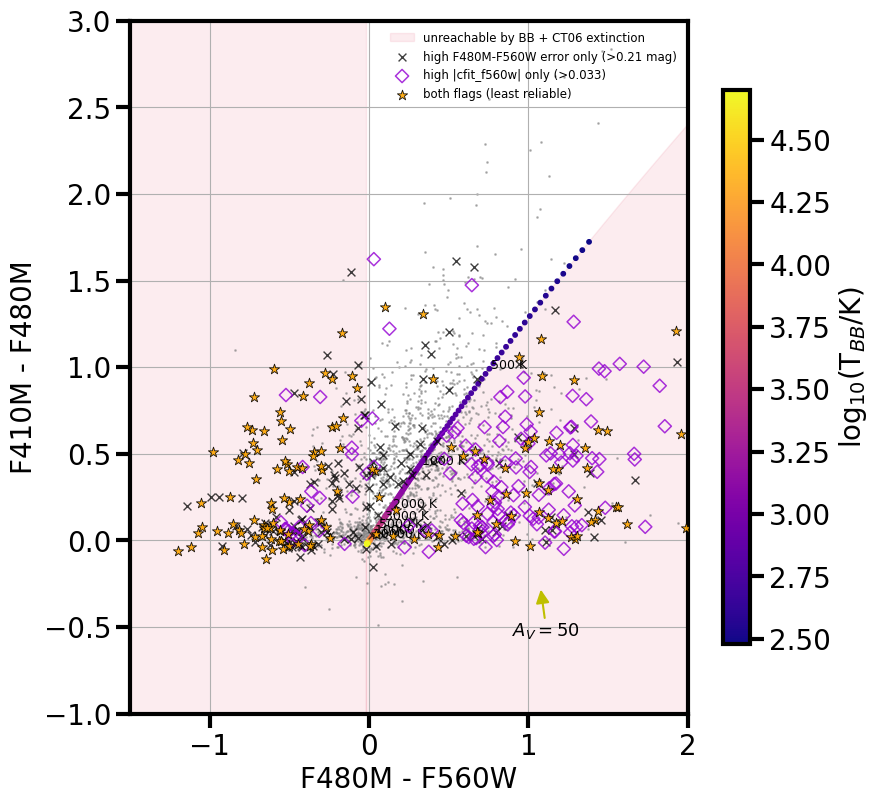

In [6]:
sigma_x_all = np.sqrt(magerrs['f480m'] ** 2 + magerrs['f560w'] ** 2)
cfit560_all = np.asarray(catalog['cfit_f560w'])
finite_color = np.isfinite(color_x) & np.isfinite(color_y)
finite_cfit = finite_color & np.isfinite(cfit560_all)

# "way high" = top 15% of the distribution among sources that have a
# measured F480M-F560W color at all -- data-driven rather than an arbitrary
# fixed number, but the actual mag/dex values are printed so the cut is
# transparent
pct = 85
sigma_x_thresh = np.nanpercentile(sigma_x_all[finite_color], pct)
cfit_abs_thresh = np.nanpercentile(np.abs(cfit560_all[finite_cfit]), pct)

idx_bad_err = finite_color & (sigma_x_all > sigma_x_thresh)
idx_bad_cfit = finite_cfit & (np.abs(cfit560_all) > cfit_abs_thresh)
idx_bad_x_color = idx_bad_err | idx_bad_cfit

print(f'F480M-F560W color-error cut ({pct}th percentile): sigma > {sigma_x_thresh:.3f} mag'
      f'  ({idx_bad_err.sum()} sources)')
print(f'|cfit_f560w| cut ({pct}th percentile): > {cfit_abs_thresh:.4f}'
      f'  ({idx_bad_cfit.sum()} sources)')
print(f'flagged by either (F480M-F560W unreliable): {idx_bad_x_color.sum()} / {finite_color.sum()}'
      f'  ({(idx_bad_err & idx_bad_cfit).sum()} flagged by both)')

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111)

ylo = -1.5
ax.fill_between(bb_x_sorted, ylo, bb_y_sorted, color='crimson', alpha=0.08,
                 zorder=0, label='unreachable by BB + CT06 extinction')
ax.axvspan(-2.5, bb_x_sorted.min(), color='crimson', alpha=0.08, zorder=0)

ax.scatter(color_x[~idx_bad_x_color], color_y[~idx_bad_x_color], s=1, c='gray', alpha=0.5)

sc = ax.scatter(bb_x_plot, bb_y_plot, c=np.log10(T_grid_plot), cmap='plasma', s=10, zorder=3)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label(r'log$_{10}$(T$_{BB}$/K)')
for Tmark in [500, 1000, 2000, 3000, 5000, 10000, 30000]:
    i = np.argmin(np.abs(T_grid_plot - Tmark))
    ax.annotate(f'{Tmark} K', (bb_x_plot[i], bb_y_plot[i]), fontsize=9, color='k',
                textcoords='offset points', xytext=(4, 4))

# highlight sources whose F480M-F560W color is unreliable: large color error
# and/or a high |cfit_f560w| (the S/N-independent contamination/blending
# diagnostic identified above) -- these should not be trusted at face value
# in this diagram's x-coordinate
ax.scatter(color_x[idx_bad_err & ~idx_bad_cfit], color_y[idx_bad_err & ~idx_bad_cfit],
           s=32, marker='x', color='black', linewidth=1.0, alpha=0.75, zorder=4,
           label=f'high F480M-F560W error only (>{sigma_x_thresh:.2f} mag)')
ax.scatter(color_x[idx_bad_cfit & ~idx_bad_err], color_y[idx_bad_cfit & ~idx_bad_err],
           s=45, marker='D', facecolor='none', edgecolor='darkviolet', linewidth=1.1,
           alpha=0.8, zorder=4, label=f'high |cfit_f560w| only (>{cfit_abs_thresh:.3f})')
ax.scatter(color_x[idx_bad_err & idx_bad_cfit], color_y[idx_bad_err & idx_bad_cfit],
           s=60, marker='*', color='orange', edgecolor='k', linewidth=0.6,
           alpha=0.9, zorder=5, label='both flags (least reliable)')

plot_extvec_ccd(ax, ('f480m', 'f560w'), ('f410m', 'f480m'), ext,
                 extvec_scale=50, start=(0.9, -0.55), color='y')

ax.grid()
ax.set_xlabel('F480M - F560W')
ax.set_ylabel('F410M - F480M')
ax.set_xlim(-1.5, 2)
ax.set_ylim(-1, 3)
ax.legend(fontsize=8.5, frameon=False, loc='upper right')
plt.savefig('ccd_410m480_480m560w_unreliable_highlighted_cfit003.png', bbox_inches='tight')
plt.show()


**Reading the extinction vector:** the arrow shows how much CT06 reddening
moves a blackbody's colors for $A_V=50$: only ~(0.18, 0.27) mag, since CT06
mid-IR extinction is nearly gray between 4 and 5.6 μm. That vector's slope
(1.50) is steeper than the blackbody locus's own slope (0.73-1.39 with
the bandpass-integrated locus, confirmed numerically above) at every
temperature. That single fact is
what makes the shaded region below the locus (and blueward of the hottest
blackbody) a genuine exclusion zone: reddening a blackbody by any amount
only ever pushes its colors up and to the left *relative to the locus*
(never down), so nothing in that shaded region can be produced by a
blackbody photosphere plus CT06 dust extinction, regardless of temperature
or A$_V$. The classification below turns that geometric fact into a
source-by-source split.

## Color-color diagram: F480M − F770W vs F410M − F480M

The same diagram construction (blackbody locus, CT06 extinction vector,
unreachable-region shading), swapping F560W for F770W as the long-wavelength
MIRI band. F770W probes further into the mid-IR (7.7 μm vs 5.6 μm), where
PAH emission and warm dust continuum are typically stronger, so this is a
useful cross-check on whatever is driving the F480M-F560W excess seen
above.

CT06 reddening-vector slope (dy/dx) for F480M-F770W vs F410M-F480M: 0.8349682680679379
blackbody-locus local slope range: 0.360072811828876 - 0.5501902902378362
vector slope exceeds the locus slope everywhere: True


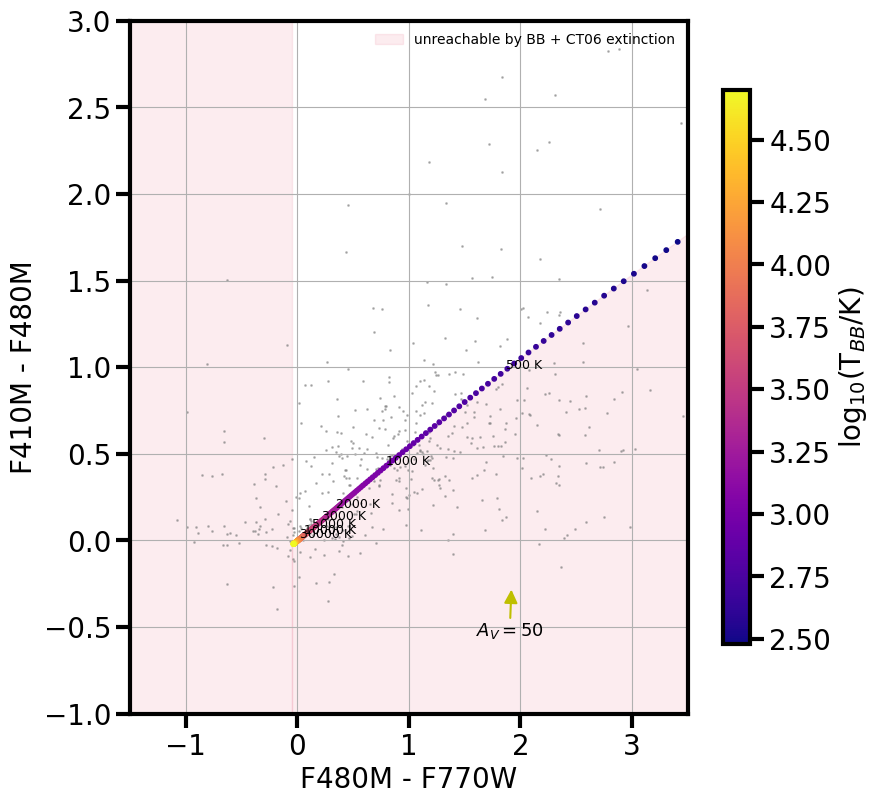

In [7]:
color_x_770 = f480 - f770   # F480M - F770W
color_y_770 = f410 - f480   # F410M - F480M (same as before)

bb_x_770, bb_y_770 = bb_locus(T_grid_wide, 'f410m', 'f480m', 'f770w')
_order_770 = np.argsort(bb_x_770)
bb_x_770_sorted, bb_y_770_sorted = bb_x_770[_order_770], bb_y_770[_order_770]
bb_local_slope_770 = np.gradient(bb_y_770_sorted, bb_x_770_sorted)

dx_per_av_770 = ext(1 / get_wave('f480m')) - ext(1 / get_wave('f770w'))
dy_per_av_770 = ext(1 / get_wave('f410m')) - ext(1 / get_wave('f480m'))
vec_slope_770 = dy_per_av_770 / dx_per_av_770
print('CT06 reddening-vector slope (dy/dx) for F480M-F770W vs F410M-F480M:', vec_slope_770)
print('blackbody-locus local slope range:', bb_local_slope_770.min(), '-', bb_local_slope_770.max())
print('vector slope exceeds the locus slope everywhere:', bool(np.all(bb_local_slope_770 < vec_slope_770)))
# Same geometric argument as the F480M-F560W diagram applies here: since the
# reddening vector is steeper than this locus everywhere too, the region
# below the (unreddened) locus is unreachable by any blackbody temperature
# reddened by any amount of CT06 extinction.

bb_x_770_plot, bb_y_770_plot = bb_locus(T_grid_plot, 'f410m', 'f480m', 'f770w')

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111)

ylo = -1.5
ax.fill_between(bb_x_770_sorted, ylo, bb_y_770_sorted, color='crimson', alpha=0.08,
                 zorder=0, label='unreachable by BB + CT06 extinction')
ax.axvspan(-2.5, bb_x_770_sorted.min(), color='crimson', alpha=0.08, zorder=0)

ax.scatter(color_x_770, color_y_770, s=1, c='gray', alpha=0.5)

sc = ax.scatter(bb_x_770_plot, bb_y_770_plot, c=np.log10(T_grid_plot), cmap='plasma', s=10, zorder=3)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label(r'log$_{10}$(T$_{BB}$/K)')
for Tmark in [500, 1000, 2000, 3000, 5000, 10000, 30000]:
    i = np.argmin(np.abs(T_grid_plot - Tmark))
    ax.annotate(f'{Tmark} K', (bb_x_770_plot[i], bb_y_770_plot[i]), fontsize=9, color='k',
                textcoords='offset points', xytext=(4, 4))

plot_extvec_ccd(ax, ('f480m', 'f770w'), ('f410m', 'f480m'), ext,
                 extvec_scale=50, start=(1.6, -0.55), color='y')

ax.grid()
ax.set_xlabel('F480M - F770W')
ax.set_ylabel('F410M - F480M')
ax.set_xlim(-1.5, 3.5)
ax.set_ylim(-1, 3)
ax.legend(fontsize=10, frameon=False, loc='upper right')
plt.savefig('ccd_410m480_480m770w_cfit003.png', bbox_inches='tight')
plt.show()


## Splitting sources by F480M − F560W color

Restricting to the embedded/reddened population (`idx_red_sources`, defined
above from the F162M−F210M vs F162M demarcation line, consistent with the
other notebooks), a Gaussian-mixture decomposition of the A$_V$-dereddened
F480M − F560W color is used to find a data-driven boundary between a
narrow "core" component and a redder excess tail.

Best n_components (BIC): 2
boundary_560 = 0.6489410362976309
n redder branch: 148    n bluer branch: 883


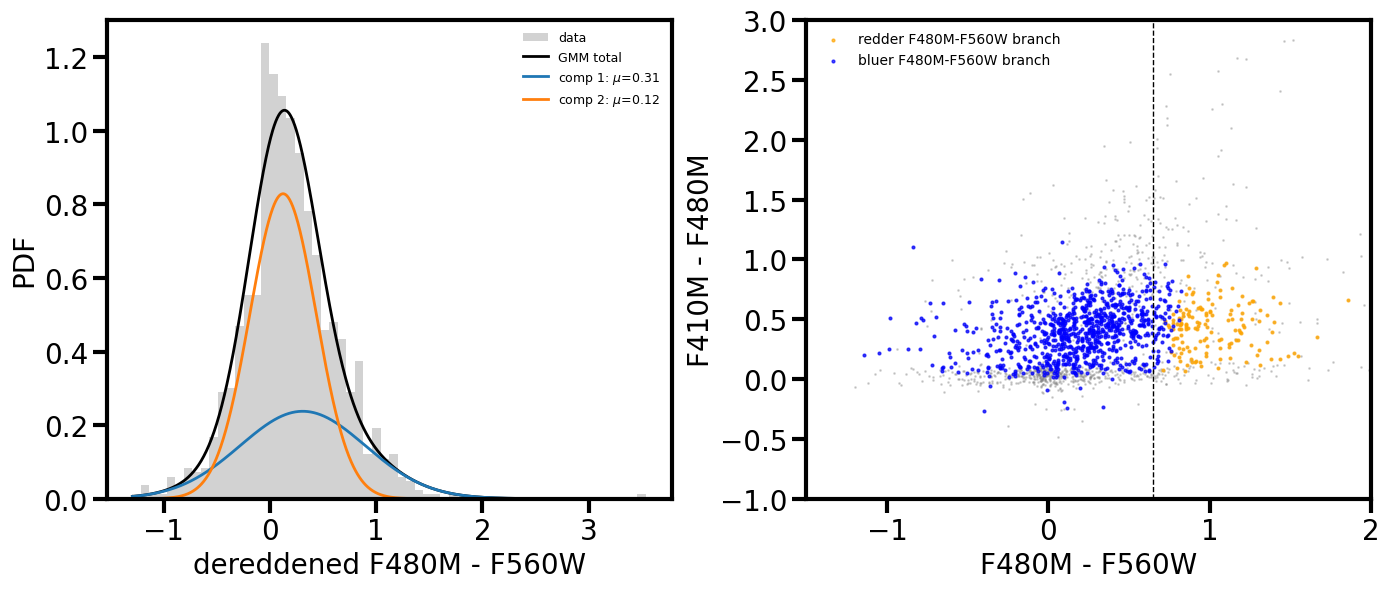

In [8]:
from sklearn.mixture import GaussianMixture

def gaussian_decomposition(color, return_boundary=False, ax=None, color_label=''):
    x = np.asarray(color)
    x = x[np.isfinite(x)].reshape(-1, 1)

    models, bics = [], []
    for k in range(1, 6):
        gmm_k = GaussianMixture(n_components=k, random_state=42, n_init=20)
        gmm_k.fit(x)
        models.append(gmm_k)
        bics.append(gmm_k.bic(x))
    gmm = models[int(np.argmin(bics))]
    print('Best n_components (BIC):', gmm.n_components)

    xgrid = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)
    pdf = np.exp(gmm.score_samples(xgrid))
    resp = gmm.predict_proba(xgrid)
    pdf_components = resp * pdf[:, None]

    if ax is not None:
        ax.hist(x.ravel(), bins=60, density=True, alpha=0.35, color='gray', label='data')
        ax.plot(xgrid, pdf, 'k-', lw=2, label='GMM total')
        for i in range(gmm.n_components):
            ax.plot(xgrid, pdf_components[:, i], lw=2,
                     label=f'comp {i+1}: $\\mu$={gmm.means_[i,0]:.2f}')
        ax.set_xlabel(f'dereddened {color_label}')
        ax.set_ylabel('PDF')
        ax.legend(fontsize=9, frameon=False)

    highest_peak_component = int(np.argmax(np.max(pdf_components, axis=0)))
    if not return_boundary:
        return gmm, highest_peak_component

    # Decision-boundary approach: find the point beyond which the reddest-mean
    # component is the MAP classification for the rest of the grid. This is
    # more robust than comparing PDF-peak heights when one component is much
    # narrower/taller than a broader excess component (our case here), where
    # a naive peak-crossing test can have zero or two solutions.
    hi = int(np.argmax(gmm.means_[:, 0]))
    labels = gmm.predict(xgrid)
    is_hi = labels == hi
    if is_hi[-1]:
        idx = len(is_hi) - 1
        while idx > 0 and is_hi[idx - 1]:
            idx -= 1
        boundary = xgrid[idx, 0]
    else:
        boundary = xgrid[-1, 0]
    return gmm, highest_peak_component, boundary

color_560_dereddened = (f480 - f560) - av_estimate * (ext(1 / 4.80 / u.um) - ext(1 / 5.60 / u.um))

fig = plt.figure(figsize=(14, 6))
ax_gmm = fig.add_subplot(121)
gmm, peak_ind, boundary_560 = gaussian_decomposition(
    color_560_dereddened[idx_red_sources], return_boundary=True, ax=ax_gmm,
    color_label='F480M - F560W')
print('boundary_560 =', boundary_560)

idx_upper560 = color_560_dereddened[idx_red_sources] > boundary_560
idx_lower560 = color_560_dereddened[idx_red_sources] <= boundary_560
print('n redder branch:', idx_upper560.sum(), '   n bluer branch:', idx_lower560.sum())

# indices back into the full catalog
red_idx_full = np.where(idx_red_sources)[0]
upper_full_idx = red_idx_full[idx_upper560]
lower_full_idx = red_idx_full[idx_lower560]

ax2 = fig.add_subplot(122)
ax2.scatter(color_x, color_y, s=1, c='gray', alpha=0.3)
ax2.scatter(color_x[upper_full_idx], color_y[upper_full_idx], s=4, c='orange',
            alpha=0.7, label='redder F480M-F560W branch')
ax2.scatter(color_x[lower_full_idx], color_y[lower_full_idx], s=4, c='blue',
            alpha=0.7, label='bluer F480M-F560W branch')
ax2.axvline(boundary_560, color='k', ls='--', lw=1)
ax2.set_xlabel('F480M - F560W')
ax2.set_ylabel('F410M - F480M')
ax2.set_xlim(-1.5, 2)
ax2.set_ylim(-1, 3)
ax2.legend(fontsize=10, frameon=False)
plt.tight_layout()
plt.savefig('ccd_branch_split_cfit003.png', bbox_inches='tight')
plt.show()

## Spatial distribution of the two branches

Same projection + KDE-fraction-map approach used for the upper/lower branch
maps in `color_magnitude_diagram_cleancat.ipynb`.

Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


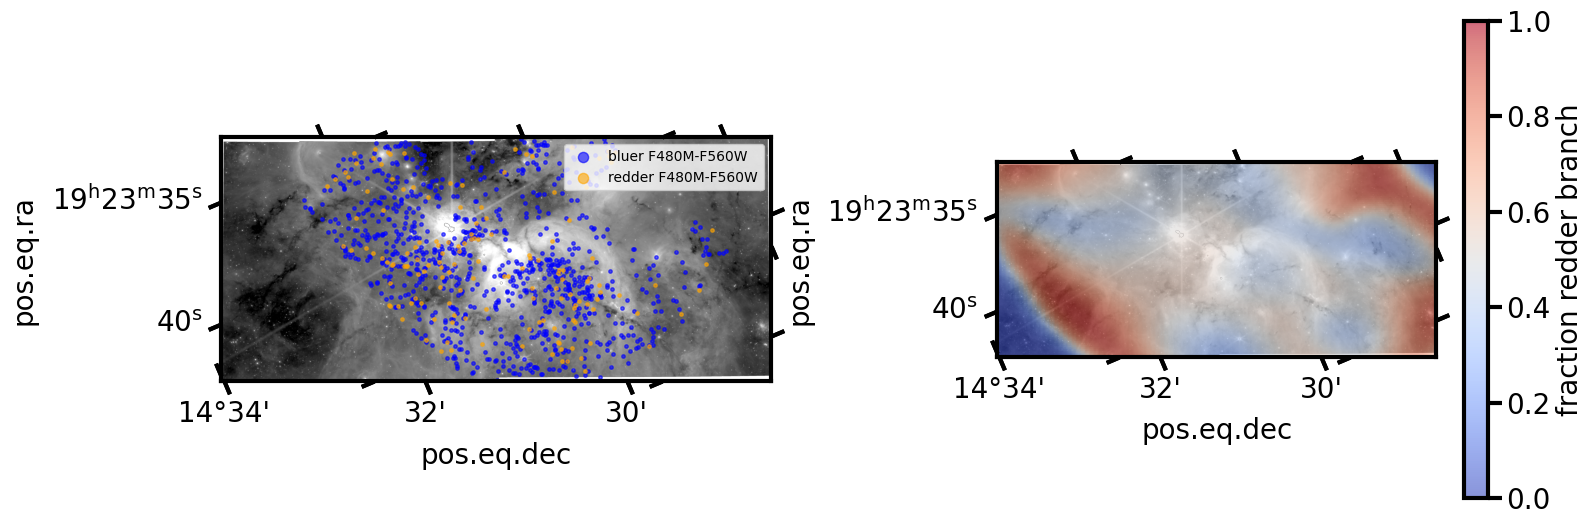

In [9]:
from astropy.visualization import simple_norm
from scipy.stats import gaussian_kde

wcs_f480m = WCS(headers['f480m'])
f480m_data = fits.getdata(image_filenames['f480m'], ext=('SCI', 1))
skycoord_ref = catalog['skycoord_ref']
pixcoord_ref = wcs_f480m.all_world2pix(skycoord_ref.ra.deg, skycoord_ref.dec.deg, 0)

norm_f480m = simple_norm(f480m_data, stretch='log', percent=99.)

fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(121, projection=wcs_f480m)
ax.imshow(f480m_data, origin='lower', cmap='gray', norm=norm_f480m)
ax.scatter(pixcoord_ref[0][lower_full_idx], pixcoord_ref[1][lower_full_idx],
           s=6, c='blue', alpha=0.6, label='bluer F480M-F560W')
ax.scatter(pixcoord_ref[0][upper_full_idx], pixcoord_ref[1][upper_full_idx],
           s=6, c='orange', alpha=0.6, label='redder F480M-F560W')
ax.legend(markerscale=3, fontsize=10, loc='upper right')

xgrid = np.linspace(0, f480m_data.shape[1], 100)
ygrid = np.linspace(0, f480m_data.shape[0], 100)
Xg, Yg = np.meshgrid(xgrid, ygrid)
grid_pts = np.vstack([Xg.ravel(), Yg.ravel()])
kde_lower = gaussian_kde(np.vstack([pixcoord_ref[0][lower_full_idx],
                                     pixcoord_ref[1][lower_full_idx]]))(grid_pts).reshape(Xg.shape)
kde_upper = gaussian_kde(np.vstack([pixcoord_ref[0][upper_full_idx],
                                     pixcoord_ref[1][upper_full_idx]]))(grid_pts).reshape(Xg.shape)
frac_upper = kde_upper / (kde_upper + kde_lower + 1e-10)

ax2 = fig.add_subplot(122, projection=wcs_f480m)
ax2.imshow(f480m_data, origin='lower', cmap='gray', norm=norm_f480m)
im = ax2.imshow(frac_upper, origin='lower', cmap='coolwarm', alpha=0.6, vmin=0, vmax=1,
                 extent=[xgrid.min(), xgrid.max(), ygrid.min(), ygrid.max()])
plt.colorbar(im, ax=ax2, label='fraction redder branch', shrink=0.7)
plt.tight_layout()
plt.savefig('branch_spatial_map_cfit003.png', bbox_inches='tight')
plt.show()

**Caveat:** the KDE fraction map is noisy near the field edges where
both populations have few sources -- treat those margins qualitatively,
not the bulk/interior trends.

## A$_V$ and other physical properties by branch

Compares A$_V$, F410M − F480M color, and F480M brightness between the two
branches, with a KS test on A$_V$ for a quick significance check.

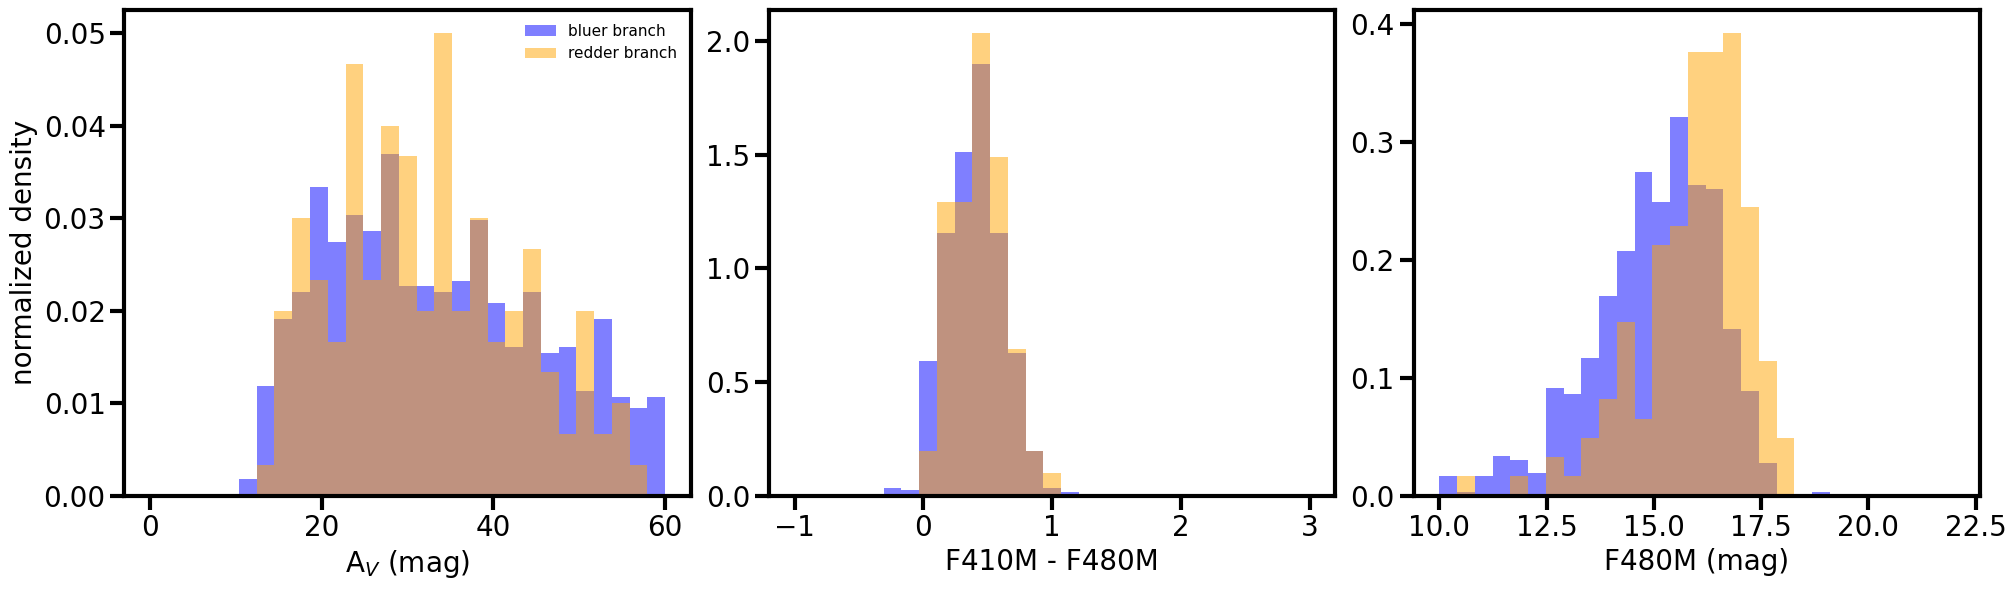

median A_V  bluer branch: 33.64896227348342
median A_V redder branch: 31.938761690198728
KS test on A_V (bluer vs redder): KstestResult(statistic=np.float64(0.13319151541122096), pvalue=np.float64(0.019979196889669665), statistic_location=np.float64(45.655695506673226), statistic_sign=np.int8(-1))


In [10]:
from scipy.stats import ks_2samp

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

bins_av = np.linspace(0, 60, 30)
axes[0].hist(av_estimate[lower_full_idx], bins=bins_av, alpha=0.5, color='blue',
             density=True, label='bluer branch')
axes[0].hist(av_estimate[upper_full_idx], bins=bins_av, alpha=0.5, color='orange',
             density=True, label='redder branch')
axes[0].set_xlabel('A$_V$ (mag)')
axes[0].set_ylabel('normalized density')
axes[0].legend(fontsize=11, frameon=False)

bins_color = np.linspace(-1, 3, 30)
axes[1].hist((f410 - f480)[lower_full_idx], bins=bins_color, alpha=0.5, color='blue', density=True)
axes[1].hist((f410 - f480)[upper_full_idx], bins=bins_color, alpha=0.5, color='orange', density=True)
axes[1].set_xlabel('F410M - F480M')

bins_mag = np.linspace(10, 22, 30)
axes[2].hist(f480[lower_full_idx], bins=bins_mag, alpha=0.5, color='blue', density=True)
axes[2].hist(f480[upper_full_idx], bins=bins_mag, alpha=0.5, color='orange', density=True)
axes[2].set_xlabel('F480M (mag)')

plt.tight_layout()
plt.savefig('branch_properties_cfit003.png', bbox_inches='tight')
plt.show()

av_lower_fin = av_estimate[lower_full_idx][np.isfinite(av_estimate[lower_full_idx])]
av_upper_fin = av_estimate[upper_full_idx][np.isfinite(av_estimate[upper_full_idx])]
print('median A_V  bluer branch:', np.median(av_lower_fin))
print('median A_V redder branch:', np.median(av_upper_fin))
print('KS test on A_V (bluer vs redder):', ks_2samp(av_lower_fin, av_upper_fin))

## Interpretation notes

- The CT06 differential extinction between 4.1-5.6 μm is small, so the
  reddening vector barely moves sources in this diagram even at A$_V\sim$50.
  Sources well off the blackbody locus in F480M−F560W are unlikely to be
  reddened normal photospheres -- they more plausibly carry intrinsic
  mid-IR excess (hot dust, disk, or line/PAH emission in F560W).
- The GMM decomposition of the A$_V$-dereddened F480M−F560W color found a
  narrow core plus a redder excess tail (not a fully separated bimodal
  distribution) -- treat the "redder" vs "bluer" branch labels as a
  continuum split at the data-driven boundary, not a clean two-population
  claim on their own.
- Compare the spatial map, A$_V$ histogram, and KS-test p-value above: if the
  redder branch is both spatially distinct (e.g. concentrated near known
  protostellar/ALMA sources) *and* has a different A$_V$ distribution, that
  is stronger evidence for a physically distinct population than either
  alone. Extend this cell block (same pattern as
  `color_magnitude_diagram_cleancat.ipynb`) to add ALMA/VLA source overlays
  or CO/ATLASGAL contours if a tighter physical association needs to be
  checked.

## Splitting sources by consistency with blackbody + CT06 extinction

Using the geometric fact established above (the CT06 vector is steeper
than the blackbody locus everywhere, so reddening only ever moves colors
to lie *above* the locus, never below): a source's (F480M−F560W,
F410M−F480M) position is called

- **"BB+extinction consistent"** if it sits at or above the unreddened
  blackbody locus (within its photometric errors) -- reachable by *some*
  temperature plus *some* non-negative A$_V$;
- **"excess"** if it sits below the locus, or is bluer in F480M−F560W
  than the hottest blackbody in the grid -- no blackbody temperature and no
  amount of CT06 reddening can put a source there, so something else must
  be going on (hot dust/disk emission, line or PAH contamination in one of
  the bands, or a bad measurement).

This only needs the F410M/F480M/F560W photometry itself -- no independent
A$_V$ estimate is required (unlike the per-source-A$_V$ approach used in an
earlier version of this notebook), so it does not require a near-IR
detection and is not biased against near-IR-dropout embedded sources.

**Note on the plot:** a handful of gray ("consistent") points still appear
visibly below the black locus line. That is expected: the test is a
3$\sigma$ statistical tolerance on each source's own photometric error,
not a strict "must sit on-or-above-the-line" cut. The shaded region below
assumes zero measurement error, but a real source with a large error bar
(usually driven by a faint, low-S/N F560W/MIRI detection -- MIRI is much
shallower than the NIRCam bands here) can have its central value fall
inside the shaded zone while still being statistically consistent with
sitting on the locus once its uncertainty is taken into account. The
classification plot below draws error bars on those borderline points so
this is visible directly, and prints the F560W error comparison that
confirms MIRI photon noise is the main driver.

n sources with finite F480M-F560W & F410M-F480M colors: 2009
n BB+extinction consistent: 1146   n excess: 414
  of which bluer than any blackbody in the grid: 30
153 "consistent" sources sit >0.3 mag below the locus;
  their median F560M error: 0.15686567014659875 mag vs. 0.05485364135982496 mag for sources sitting right on the locus


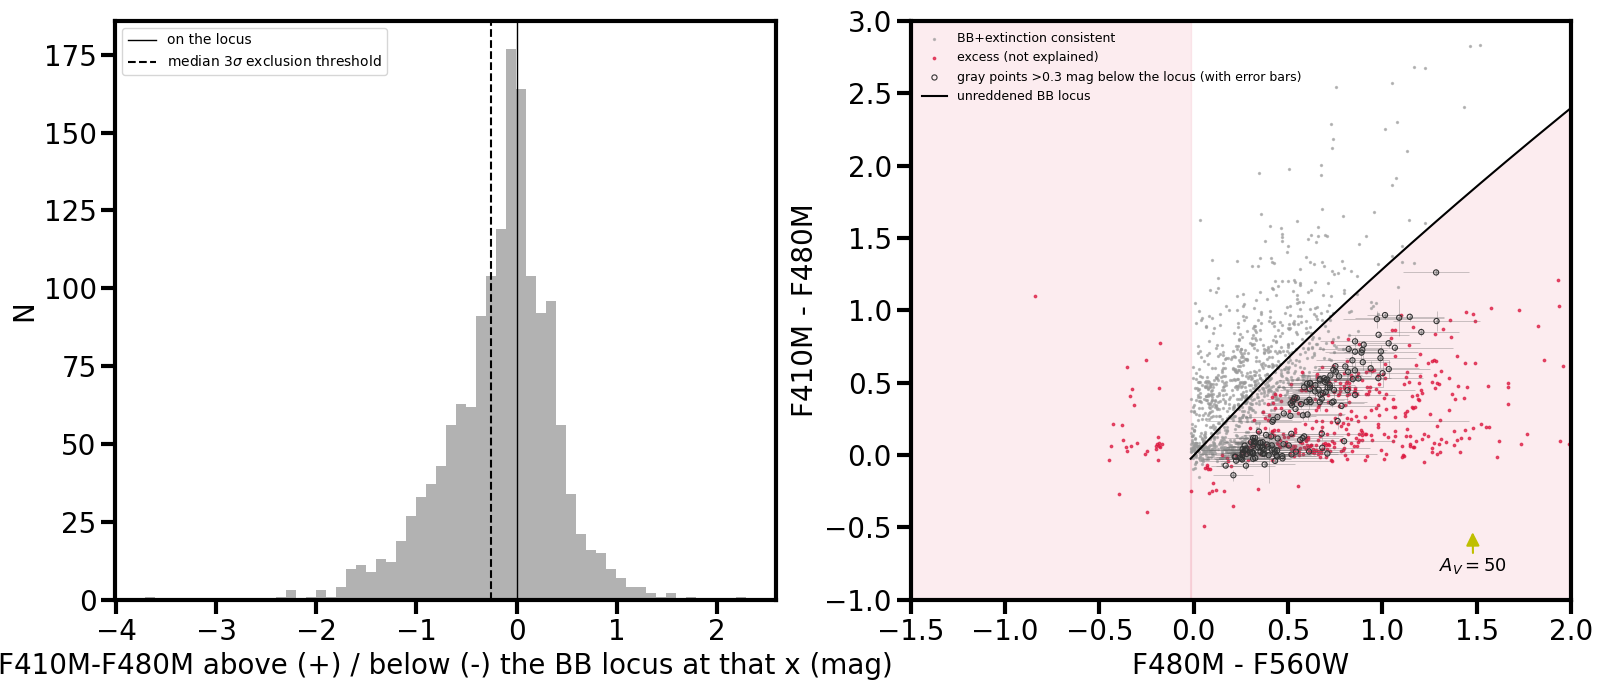

In [11]:
# curve height (F410M-F480M) predicted by the unreddened blackbody locus at
# each source's own F480M-F560W color; sources bluer than the locus's
# hottest point are flagged impossible regardless of their y-value
curve_y_at_source = np.interp(color_x, bb_x_sorted, bb_y_sorted,
                               left=np.nan, right=bb_y_sorted[-1])
local_slope_at_source = np.interp(color_x, bb_x_sorted, bb_local_slope,
                                   left=0.0, right=bb_local_slope[-1])

finite_bb = np.isfinite(color_x) & np.isfinite(color_y)
print('n sources with finite F480M-F560W & F410M-F480M colors:', finite_bb.sum())

# residual > 0 means the source is above the locus (reachable); residual < 0
# means below (unreachable by any T, any non-negative A_V)
residual = color_y - curve_y_at_source

# combined photometric-color uncertainty, projected onto the residual
# direction via the locus's local slope (an x-error shifts the *predicted*
# curve height by slope*sigma_x), with a noise floor so already-tiny formal
# errors on bright stars don't drive spurious "excess" flags
sigma_x = np.sqrt(magerrs['f480m'] ** 2 + magerrs['f560w'] ** 2)
sigma_y = np.sqrt(magerrs['f410m'] ** 2 + magerrs['f480m'] ** 2)
sigma_eff = np.sqrt(sigma_y ** 2 + (local_slope_at_source * sigma_x) ** 2)
n_sigma = 3.0
sigma_floor = 0.05
threshold = n_sigma * np.clip(sigma_eff, sigma_floor, None)

# only flag a source as impossible-in-x if it is bluer than the hottest
# blackbody by MORE than its own photometric error -- otherwise photon
# noise on faint, low-S/N F560W detections would trivially scatter sources
# blueward of the limit and get flagged as impossible for no physical reason
sigma_x_eff = np.clip(sigma_x, sigma_floor, None)
idx_impossible_x = finite_bb & (color_x + n_sigma * sigma_x_eff < bb_x_sorted.min())
idx_bb_consistent = finite_bb & ~idx_impossible_x & (residual >= -threshold)
idx_excess = finite_bb & (idx_impossible_x | (residual < -threshold))
print('n BB+extinction consistent:', idx_bb_consistent.sum(), '  n excess:', idx_excess.sum())
print('  of which bluer than any blackbody in the grid:', idx_impossible_x.sum())

# Why some "consistent" (gray) points plot visibly BELOW the black locus:
# the test is a 3-sigma STATISTICAL tolerance on each source's own combined
# photometric error, not a strict "on-or-above-the-line" geometric cut. The
# shaded region assumes zero measurement error; a real source with a large
# error bar can be classified "consistent" even while its central value
# falls inside the shaded zone, because its uncertainty reaches back up to
# the locus. F560W (MIRI) is much shallower than the NIRCam bands here
# (only ~2200/15000 sources are even detected in it), so this dominates:
deep_but_consistent = idx_bb_consistent & (residual < -0.3)
print(f'{deep_but_consistent.sum()} "consistent" sources sit >0.3 mag below the locus;')
print('  their median F560M error:', np.nanmedian(magerrs['f560w'][deep_but_consistent]),
      'mag vs.', np.nanmedian(magerrs['f560w'][idx_bb_consistent & (residual >= -0.05)]),
      'mag for sources sitting right on the locus')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
ax = axes[0]
ax.hist(residual[finite_bb], bins=60, color='gray', alpha=0.6)
ax.axvline(0, color='k', lw=1, label='on the locus')
ax.axvline(-np.nanmedian(threshold[finite_bb]), color='k', ls='--',
           label=f'median {n_sigma:.0f}$\sigma$ exclusion threshold')
ax.set_xlabel('F410M-F480M above (+) / below (-) the BB locus at that x (mag)')
ax.set_ylabel('N')
ax.legend(fontsize=10)

ax2 = axes[1]
ylo = -1.5
ax2.fill_between(bb_x_sorted, ylo, bb_y_sorted, color='crimson', alpha=0.08, zorder=0)
ax2.axvspan(-2.5, bb_x_sorted.min(), color='crimson', alpha=0.08, zorder=0)
ax2.scatter(color_x[idx_bb_consistent], color_y[idx_bb_consistent], s=2, c='0.6',
            alpha=0.6, label='BB+extinction consistent')
ax2.scatter(color_x[idx_excess], color_y[idx_excess], s=3, c='crimson',
            alpha=0.7, label='excess (not explained)')
# show error bars for the borderline-but-accepted points, so it's visible
# *why* they still count as consistent despite plotting below the line
ax2.errorbar(color_x[deep_but_consistent], color_y[deep_but_consistent],
             xerr=sigma_x[deep_but_consistent], yerr=sigma_y[deep_but_consistent],
             fmt='none', ecolor='0.4', elinewidth=0.6, alpha=0.4, zorder=1)
ax2.scatter(color_x[deep_but_consistent], color_y[deep_but_consistent], s=14,
            facecolor='none', edgecolor='0.2', linewidth=0.8, zorder=2,
            label='gray points >0.3 mag below the locus (with error bars)')
ax2.plot(bb_x_sorted, bb_y_sorted, color='k', lw=1.5, label='unreddened BB locus')
plot_extvec_ccd(ax2, ('f480m', 'f560w'), ('f410m', 'f480m'), ext,
                 extvec_scale=50, start=(1.3, -0.8), color='y')
ax2.set_xlabel('F480M - F560W')
ax2.set_ylabel('F410M - F480M')
ax2.set_xlim(-1.5, 2)
ax2.set_ylim(-1, 3)
ax2.legend(fontsize=9, frameon=False, loc='upper left')
plt.tight_layout()
plt.savefig('ccd_bb_extinction_classification_cfit003.png', bbox_inches='tight')
plt.show()

### How much of the "excess" population is just unreliable photometry?

Cross-checks the `idx_bad_x_color` flag (high F480M-F560W error and/or high
`|cfit_f560w|`, defined earlier right after the main CCD) against the
excess/BB-consistent classification.

In [12]:
n_excess_bad = (idx_excess & idx_bad_x_color).sum()
n_excess_ok = (idx_excess & ~idx_bad_x_color).sum()
n_good_bad = (idx_bb_consistent & idx_bad_x_color).sum()
n_good_ok = (idx_bb_consistent & ~idx_bad_x_color).sum()
print(f'excess sources with an unreliable F480M-F560W color:      {n_excess_bad} / {idx_excess.sum()}'
      f' ({100*n_excess_bad/idx_excess.sum():.0f}%)')
print(f'BB-consistent sources with an unreliable F480M-F560W color: {n_good_bad} / {idx_bb_consistent.sum()}'
      f' ({100*n_good_bad/idx_bb_consistent.sum():.0f}%)')
print()
print(f'=> "excess" sources are {100*n_excess_bad/idx_excess.sum() / (100*n_good_bad/idx_bb_consistent.sum()):.1f}x'
      f' more likely to have an unreliable F480M-F560W color than BB-consistent sources.')
print('A large share of the excess population may therefore be a photometry-quality')
print('effect rather than genuine mid-IR emission excess -- treat the excess-vs-')
print('consistent split as reliable only for sources NOT flagged by idx_bad_x_color.')

excess sources with an unreliable F480M-F560W color:      145 / 414 (35%)
BB-consistent sources with an unreliable F480M-F560W color: 120 / 1146 (10%)

=> "excess" sources are 3.3x more likely to have an unreliable F480M-F560W color than BB-consistent sources.
A large share of the excess population may therefore be a photometry-quality
effect rather than genuine mid-IR emission excess -- treat the excess-vs-
consistent split as reliable only for sources NOT flagged by idx_bad_x_color.


## Cross-matching with ALMA and VLA continuum catalogs

Cross-matches the *full* ALMA 1.3mm/3mm dendrogram source catalogs (W51e and
W51n; `dendro_*_master.fits`, which also carry per-source dust temperature
and mass estimates) and the full VLA radio catalog against the JWST
reference coordinates, using the same 0.1 arcsec match radius already
established for individual-source matches elsewhere in this project. The
VLA catalog contains repeat entries for the same physical source at
different epochs/frequencies, so duplicate matches to the same JWST row are
collapsed to unique JWST counterparts.

In [13]:
from astropy.coordinates import SkyCoord

skycoord_jwst = SkyCoord(ra=catalog['skycoord_ref'].ra, dec=catalog['skycoord_ref'].dec)

def crossmatch_full(cat_path, ra_col, dec_col, sep_max=0.1 * u.arcsec, name=''):
    tab = Table.read(cat_path)
    ra = np.asarray(tab[ra_col], dtype=float)
    dec = np.asarray(tab[dec_col], dtype=float)
    finite_pos = np.isfinite(ra) & np.isfinite(dec)
    tab = tab[finite_pos]
    sc = SkyCoord(ra=ra[finite_pos] * u.deg, dec=dec[finite_pos] * u.deg)
    idx, d2d, _ = sc.match_to_catalog_sky(skycoord_jwst)
    is_matched = d2d < sep_max
    print(f'{name}: {len(tab)} sources, {is_matched.sum()} matched to JWST within {sep_max}')
    jwst_idx_matched = idx[is_matched]
    jwst_idx_unique = np.unique(jwst_idx_matched)
    if len(jwst_idx_unique) != len(jwst_idx_matched):
        print(f'  ({len(jwst_idx_matched) - len(jwst_idx_unique)} duplicate JWST-row matches collapsed)')
    return jwst_idx_unique, tab[is_matched]

alma_w51e_idx, alma_w51e_tab = crossmatch_full(
    '/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51e_master.fits',
    'ra', 'dec', name='ALMA W51e (dendro)')
alma_w51n_idx, alma_w51n_tab = crossmatch_full(
    '/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51n_master.fits',
    'ra', 'dec', name='ALMA W51n (dendro)')
vla_idx, vla_tab = crossmatch_full(
    '/blue/adamginsburg/t.yoo/w51_nircam/analysis/vla_updated_with_radius.fits',
    'GRAdeg', 'GDEdeg', name='VLA')

alma_idx_all = np.unique(np.concatenate([alma_w51e_idx, alma_w51n_idx]))
print('total unique ALMA-matched JWST sources:', len(alma_idx_all))
print('total unique VLA-matched JWST sources:', len(vla_idx))

alma_mask = np.zeros(len(catalog), dtype=bool)
alma_mask[alma_idx_all] = True
vla_mask = np.zeros(len(catalog), dtype=bool)
vla_mask[vla_idx] = True

finite_midIR = np.isfinite(color_x) & np.isfinite(color_y)
print()
print('Of the ALMA-matched JWST sources:', (alma_mask & finite_midIR).sum(), '/', alma_mask.sum(),
      'have finite F480M-F560W & F410M-F480M colors')
print('Of the VLA-matched JWST sources: ', (vla_mask & finite_midIR).sum(), '/', vla_mask.sum(),
      'have finite F480M-F560W & F410M-F480M colors')
print('(the rest lack a detection in one of F410M/F480M/F560W -- deeply embedded')
print(' ALMA/VLA sources are disproportionately faint or undetected in these bands)')

ALMA W51e (dendro): 118 sources, 11 matched to JWST within 0.1 arcsec
ALMA W51n (dendro): 93 sources, 5 matched to JWST within 0.1 arcsec
VLA: 471 sources, 18 matched to JWST within 0.1 arcsec
  (14 duplicate JWST-row matches collapsed)
total unique ALMA-matched JWST sources: 16
total unique VLA-matched JWST sources: 4

Of the ALMA-matched JWST sources: 12 / 16 have finite F480M-F560W & F410M-F480M colors
Of the VLA-matched JWST sources:  4 / 4 have finite F480M-F560W & F410M-F480M colors
(the rest lack a detection in one of F410M/F480M/F560W -- deeply embedded
 ALMA/VLA sources are disproportionately faint or undetected in these bands)


### Are ALMA/VLA-matched sources preferentially "excess" sources?

A Fisher exact test on the 2x2 contingency table (matched/unmatched
$\times$ excess/BB-consistent). Since the classification above no longer
needs a near-IR A$_V$ estimate, this now uses (almost) the full set of
ALMA/VLA counterparts that have F410M/F480M/F560W photometry at all, not
just the handful that also happen to be near-IR detected.

The CCD below also overlays the CT06 extinction vector and the three
populations from `color_magnitude_diagram_cleancat.ipynb` (upper branch,
lower branch, and very red/NIR-dropout sources -- defined earlier in this
notebook), so all of the groupings discussed so far in this analysis can be
compared on one plot.

--- ALMA (W51e+W51n dendrogram) ---
  matched & excess: 1      matched & BB-consistent: 10
  unmatched & excess: 413   unmatched & BB-consistent: 1136
  Fisher exact test: odds ratio=0.28, p=0.306
--- VLA ---
  matched & excess: 2      matched & BB-consistent: 1
  unmatched & excess: 412   unmatched & BB-consistent: 1145
  Fisher exact test: odds ratio=5.56, p=0.174


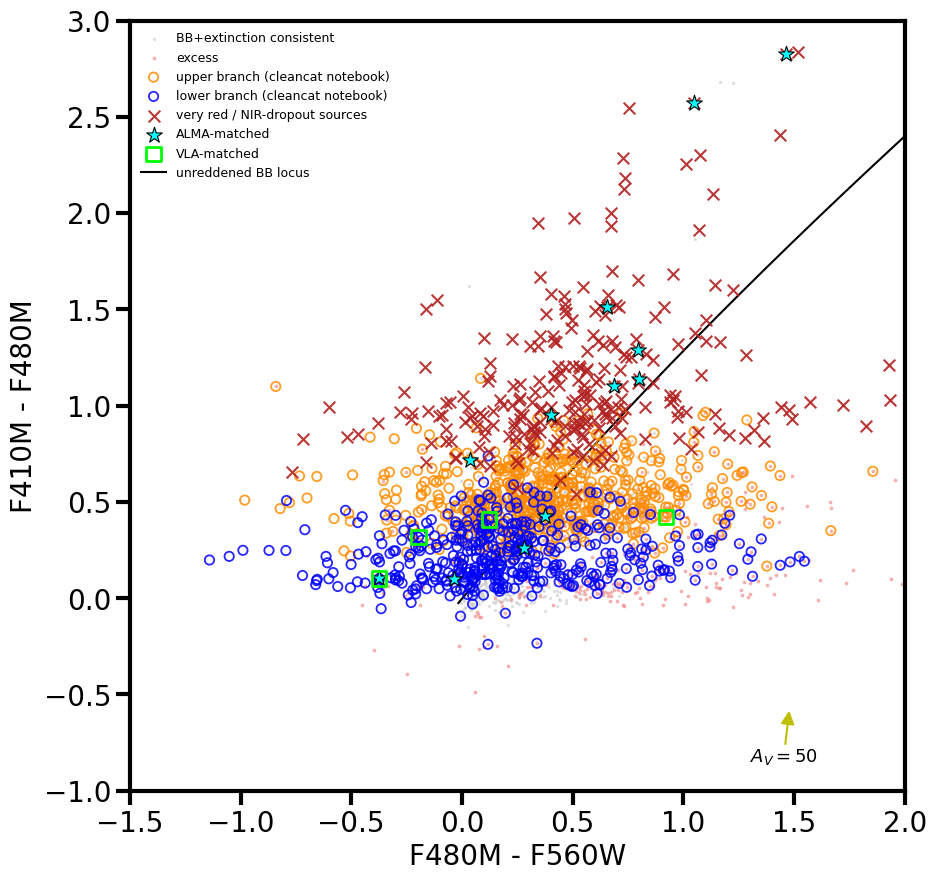

In [14]:
from scipy.stats import fisher_exact

def contingency_report(matched_mask, label):
    m_and_finite = matched_mask & finite_bb
    n_matched_excess = int((m_and_finite & idx_excess).sum())
    n_matched_bb = int((m_and_finite & idx_bb_consistent).sum())
    n_unmatched_excess = int((~matched_mask & idx_excess).sum())
    n_unmatched_bb = int((~matched_mask & idx_bb_consistent).sum())
    print(f'--- {label} ---')
    print(f'  matched & excess: {n_matched_excess}      matched & BB-consistent: {n_matched_bb}')
    print(f'  unmatched & excess: {n_unmatched_excess}   unmatched & BB-consistent: {n_unmatched_bb}')
    table2x2 = [[n_matched_excess, n_matched_bb], [n_unmatched_excess, n_unmatched_bb]]
    odds, p = fisher_exact(table2x2)
    print(f'  Fisher exact test: odds ratio={odds:.2f}, p={p:.3f}')
    return table2x2, p

contingency_report(alma_mask, 'ALMA (W51e+W51n dendrogram)')
contingency_report(vla_mask, 'VLA')

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(color_x[idx_bb_consistent], color_y[idx_bb_consistent], s=2, c='0.8',
           alpha=0.5, label='BB+extinction consistent')
ax.scatter(color_x[idx_excess], color_y[idx_excess], s=3, c='lightcoral', alpha=0.5, label='excess')

# populations from color_magnitude_diagram_cleancat.ipynb, overlaid here
ax.scatter(color_x[upper_idx], color_y[upper_idx], s=45, marker='o', facecolor='none',
           edgecolor='darkorange', linewidth=1.3, alpha=0.85, label='upper branch (cleancat notebook)', zorder=4)
ax.scatter(color_x[lower_idx], color_y[lower_idx], s=45, marker='o', facecolor='none',
           edgecolor='blue', linewidth=1.3, alpha=0.85, label='lower branch (cleancat notebook)', zorder=4)
ax.scatter(color_x[missing_nir_idx_red], color_y[missing_nir_idx_red], s=70, marker='x',
           color='firebrick', linewidth=1.5, alpha=0.9, label='very red / NIR-dropout sources', zorder=4)

ax.scatter(color_x[finite_midIR & alma_mask], color_y[finite_midIR & alma_mask], s=140,
           marker='*', facecolor='cyan', edgecolor='k', linewidth=0.8, label='ALMA-matched', zorder=5)
ax.scatter(color_x[finite_midIR & vla_mask], color_y[finite_midIR & vla_mask], s=110,
           marker='s', facecolor='none', edgecolor='lime', lw=2, label='VLA-matched', zorder=5)

ax.plot(bb_x_sorted, bb_y_sorted, color='k', lw=1.5, label='unreddened BB locus')
plot_extvec_ccd(ax, ('f480m', 'f560w'), ('f410m', 'f480m'), ext,
                 extvec_scale=50, start=(1.3, -0.85), color='y')

ax.set_xlabel('F480M - F560W')
ax.set_ylabel('F410M - F480M')
ax.set_xlim(-1.5, 2)
ax.set_ylim(-1, 3)
ax.legend(fontsize=9, frameon=False, loc='upper left', ncol=1)
plt.savefig('ccd_alma_vla_overlay_cfit003.png', bbox_inches='tight')
plt.show()

### Same population overlay, F480M − F770W vs F410M − F480M

The F770W version of the population/ALMA/VLA overlay above -- same
`upper_idx`/`lower_idx`/`missing_nir_idx_red` population definitions and
the same ALMA/VLA cross-match, just swapping in the F480M-F770W color. No
BB+extinction excess classification has been built for this filter pair
(that was done only for F480M-F560W above), so the background here is
plain gray rather than colored by excess/consistent.

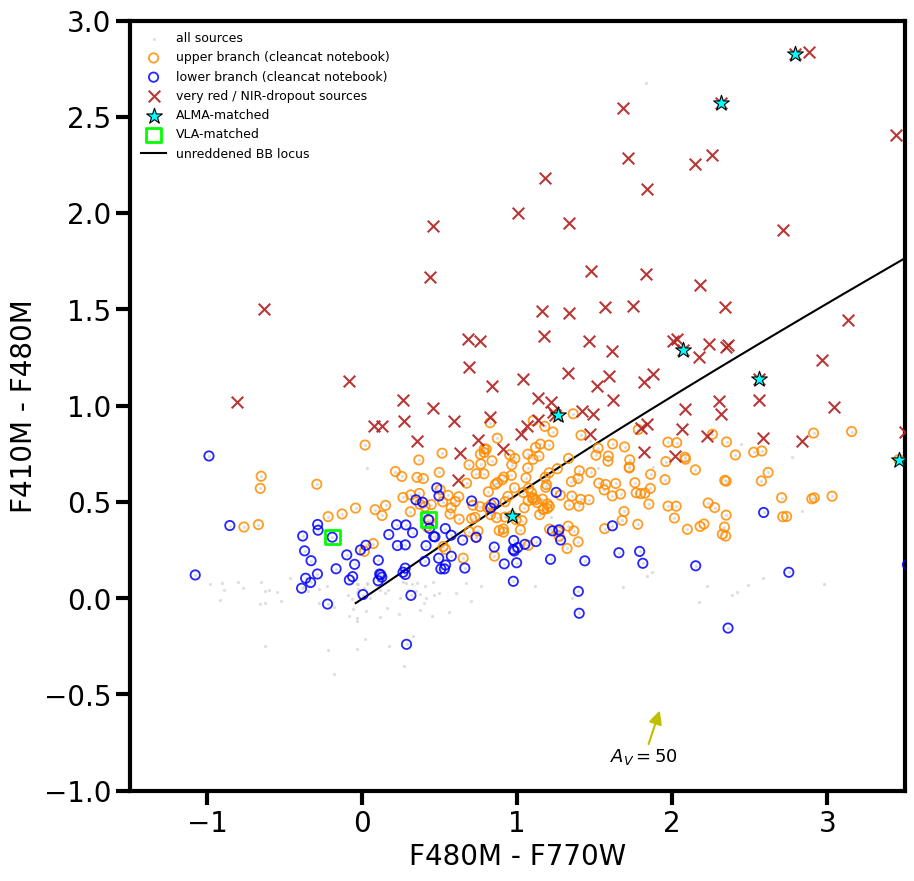

ALMA-matched with finite F480M-F770W colors: 7 / 16
VLA-matched with finite F480M-F770W colors: 2 / 4


In [15]:
finite_midIR_770 = np.isfinite(color_x_770) & np.isfinite(color_y_770)

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(color_x_770, color_y_770, s=2, c='0.8', alpha=0.5, label='all sources')

# populations from color_magnitude_diagram_cleancat.ipynb, same definitions
# used for the F480M-F560W version above
ax.scatter(color_x_770[upper_idx], color_y_770[upper_idx], s=45, marker='o', facecolor='none',
           edgecolor='darkorange', linewidth=1.3, alpha=0.85, label='upper branch (cleancat notebook)', zorder=4)
ax.scatter(color_x_770[lower_idx], color_y_770[lower_idx], s=45, marker='o', facecolor='none',
           edgecolor='blue', linewidth=1.3, alpha=0.85, label='lower branch (cleancat notebook)', zorder=4)
ax.scatter(color_x_770[missing_nir_idx_red], color_y_770[missing_nir_idx_red], s=70, marker='x',
           color='firebrick', linewidth=1.5, alpha=0.9, label='very red / NIR-dropout sources', zorder=4)

ax.scatter(color_x_770[finite_midIR_770 & alma_mask], color_y_770[finite_midIR_770 & alma_mask], s=140,
           marker='*', facecolor='cyan', edgecolor='k', linewidth=0.8, label='ALMA-matched', zorder=5)
ax.scatter(color_x_770[finite_midIR_770 & vla_mask], color_y_770[finite_midIR_770 & vla_mask], s=110,
           marker='s', facecolor='none', edgecolor='lime', lw=2, label='VLA-matched', zorder=5)

ax.plot(bb_x_770_sorted, bb_y_770_sorted, color='k', lw=1.5, label='unreddened BB locus')
plot_extvec_ccd(ax, ('f480m', 'f770w'), ('f410m', 'f480m'), ext,
                 extvec_scale=50, start=(1.6, -0.85), color='y')

ax.set_xlabel('F480M - F770W')
ax.set_ylabel('F410M - F480M')
ax.set_xlim(-1.5, 3.5)
ax.set_ylim(-1, 3)
ax.legend(fontsize=9, frameon=False, loc='upper left')
plt.savefig('ccd_410m480_480m770w_populations_cfit003.png', bbox_inches='tight')
plt.show()

print('ALMA-matched with finite F480M-F770W colors:', (finite_midIR_770 & alma_mask).sum(), '/', alma_mask.sum())
print('VLA-matched with finite F480M-F770W colors:', (finite_midIR_770 & vla_mask).sum(), '/', vla_mask.sum())


## Spatial distribution: excess vs BB+extinction-consistent sources, with ALMA/VLA positions

Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


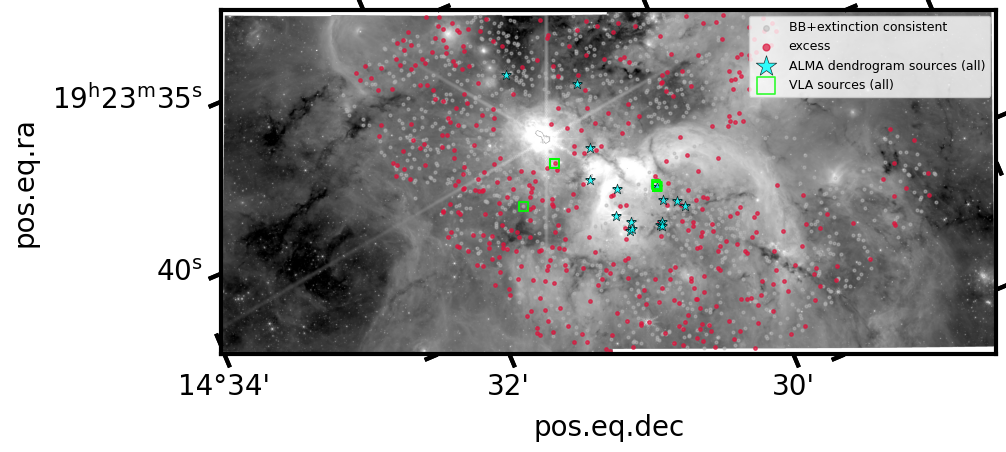

In [16]:
wcs_f480m = WCS(headers['f480m'])
f480m_data = fits.getdata(image_filenames['f480m'], ext=('SCI', 1))
skycoord_ref = catalog['skycoord_ref']
pixcoord_ref = wcs_f480m.all_world2pix(skycoord_ref.ra.deg, skycoord_ref.dec.deg, 0)
norm_f480m = simple_norm(f480m_data, stretch='log', percent=99.)

from astropy.table import vstack
alma_all_tab = vstack([alma_w51e_tab['ra', 'dec'], alma_w51n_tab['ra', 'dec']])
alma_pix = wcs_f480m.all_world2pix(alma_all_tab['ra'], alma_all_tab['dec'], 0)
vla_pix = wcs_f480m.all_world2pix(vla_tab['GRAdeg'], vla_tab['GDEdeg'], 0)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection=wcs_f480m)
ax.imshow(f480m_data, origin='lower', cmap='gray', norm=norm_f480m)
ax.scatter(pixcoord_ref[0][idx_bb_consistent], pixcoord_ref[1][idx_bb_consistent],
           s=4, c='0.7', alpha=0.5, label='BB+extinction consistent')
ax.scatter(pixcoord_ref[0][idx_excess], pixcoord_ref[1][idx_excess],
           s=6, c='crimson', alpha=0.7, label='excess')
ax.scatter(alma_pix[0], alma_pix[1], s=60, marker='*', facecolor='cyan', edgecolor='k',
           linewidth=0.5, alpha=0.8, label='ALMA dendrogram sources (all)')
ax.scatter(vla_pix[0], vla_pix[1], s=40, marker='s', facecolor='none', edgecolor='lime',
           lw=1.2, alpha=0.8, label='VLA sources (all)')
ax.legend(markerscale=2, fontsize=9, loc='upper right')
plt.savefig('bb_excess_spatial_with_alma_vla_cfit003.png', bbox_inches='tight')
plt.show()

## Why do some lower-branch sources fall below the BB locus?

The overlay above shows a genuine tension: the *lower branch* was defined
in `color_magnitude_diagram_cleancat.ipynb` as (presumably) bare/lightly
embedded photospheres reddened by foreground dust, using only the
F162M-F210M-F480M diagram -- but some of those sources land in the
"cannot be explained by BB+CT06 extinction" zone of *this* diagram. Two
possibilities: (1) their F480M/F410M/F560W colors have large enough errors
that they are not actually significant outliers, or (2) something else
(bad photometry from crowding/nebular background, contamination, etc.) is
placing them there. This checks both.

lower branch, finite BB-classification colors: 437
  of which BB+extinction consistent: 229
  of which excess (below locus or blue-limit): 98 (95 below-locus, 3 blue-limit)
significance beyond the 3-sigma cut (1.0=borderline): [1.03 1.23 1.49 1.81 2.59 4.89]
53% of them are within 1.5x the threshold -- i.e. borderline/consistent with noise

correlation with F560W magerr (an S/N proxy), across ALL finite-F560W sources:
  qfit_f560w           r = +0.95
  cfit_f560w           r = +0.20
  roundness1_f560w     r = -0.02
  local_bkg/flux (F480M) r = +0.71  (vs F480M magerr)
qfit and the local-background ratio are strongly tied to S/N (r~0.7-0.95) -- a
raw median comparison for those is mostly/entirely a brightness artifact, not a
genuine fit-quality difference. cfit and roundness1 are only weakly correlated
with S/N, so a difference in THOSE is not just a brightness effect.

S/N-matched (F560W magerr-binned) comparison, lower branch:
        magerr bin   n_g   n_e   qfit_g   qfit_e    cfit_g

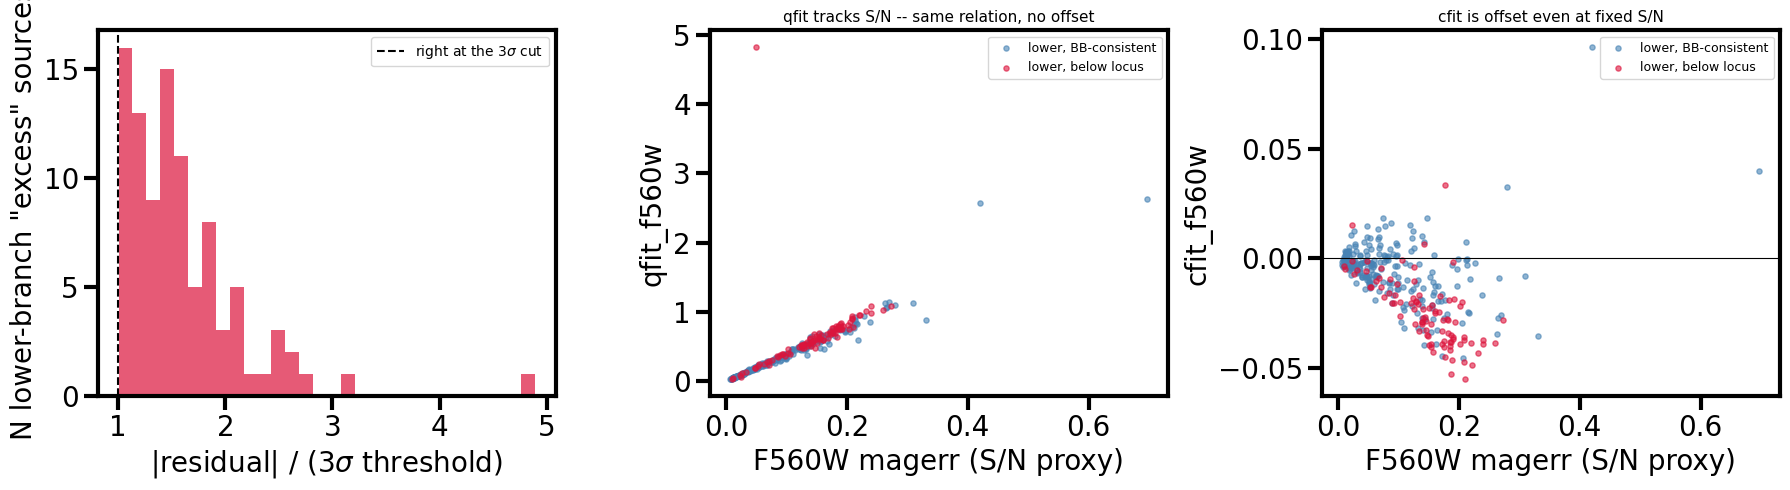

In [17]:
idx_lower_excess = lower_idx & idx_excess & finite_bb
idx_lower_good = lower_idx & idx_bb_consistent & finite_bb
# separate the (rare) blue-limit exclusions from the more common
# below-the-locus exclusions, since only the latter have a well-defined
# residual/threshold ratio
idx_lower_excess_res = idx_lower_excess & ~idx_impossible_x
print('lower branch, finite BB-classification colors:', (lower_idx & finite_bb).sum())
print('  of which BB+extinction consistent:', idx_lower_good.sum())
print('  of which excess (below locus or blue-limit):', idx_lower_excess.sum(),
      f'({idx_lower_excess_res.sum()} below-locus, {(idx_lower_excess & idx_impossible_x).sum()} blue-limit)')

# how far below the locus are they, in units of their own exclusion threshold?
# (1.0 = right at the 3-sigma cut; bigger = a more significant outlier)
sig_beyond = -residual[idx_lower_excess_res] / threshold[idx_lower_excess_res]
print('significance beyond the 3-sigma cut (1.0=borderline):',
      np.round(np.percentile(sig_beyond, [5, 25, 50, 75, 95, 100]), 2))
print(f'{np.mean(sig_beyond < 1.5)*100:.0f}% of them are within 1.5x the threshold -- i.e. borderline/consistent with noise')

# --- IMPORTANT CHECK: below-locus sources are fainter in F560W (lower S/N),
# and a fit-quality metric that is itself mostly a function of S/N would make
# ANY faint subsample look "worse fit" even with no real quality difference.
# Check each metric's correlation with S/N (via magerr) BEFORE trusting a
# raw median comparison between the two groups. ---
me560 = magerrs['f560w']
qfit560 = np.asarray(catalog['qfit_f560w'])
cfit560 = np.asarray(catalog['cfit_f560w'])
r1_560 = np.asarray(catalog['roundness1_f560w'])
lbk_ratio480 = np.asarray(catalog['local_bkg_f480m']) / np.asarray(catalog['flux_fit_f480m'])

finite_f560_all = np.isfinite(f560)
print()
print('correlation with F560W magerr (an S/N proxy), across ALL finite-F560W sources:')
for name, arr in [('qfit_f560w', qfit560), ('cfit_f560w', cfit560), ('roundness1_f560w', r1_560)]:
    m = finite_f560_all & np.isfinite(arr)
    print(f'  {name:20s} r = {np.corrcoef(arr[m], me560[m])[0, 1]:+.2f}')
m_lbk = np.isfinite(f480) & np.isfinite(lbk_ratio480)
print(f'  {"local_bkg/flux (F480M)":20s} r = {np.corrcoef(lbk_ratio480[m_lbk], magerrs["f480m"][m_lbk])[0, 1]:+.2f}  (vs F480M magerr)')
print('qfit and the local-background ratio are strongly tied to S/N (r~0.7-0.95) -- a')
print('raw median comparison for those is mostly/entirely a brightness artifact, not a')
print('genuine fit-quality difference. cfit and roundness1 are only weakly correlated')
print('with S/N, so a difference in THOSE is not just a brightness effect.')

# S/N-matched comparison: bin by F560W magerr and compare within each bin,
# so any real offset is not confounded with the two groups' different
# brightness distributions
me = magerrs['f560w']
bins = np.nanpercentile(me[idx_lower_good | idx_lower_excess_res], [0, 20, 40, 60, 80, 100])
print()
print('S/N-matched (F560W magerr-binned) comparison, lower branch:')
print(f'{"magerr bin":>18s}{"n_g":>6s}{"n_e":>6s}{"qfit_g":>9s}{"qfit_e":>9s}'
      f'{"cfit_g":>10s}{"cfit_e":>10s}{"round1_g":>10s}{"round1_e":>10s}')
for i in range(len(bins) - 1):
    lo, hi = bins[i], bins[i + 1]
    m_good = idx_lower_good & (me >= lo) & (me < hi)
    m_exc = idx_lower_excess_res & (me >= lo) & (me < hi)
    print(f'[{lo:.3f},{hi:.3f})'.rjust(18)
          + f'{m_good.sum():6d}{m_exc.sum():6d}'
          + f'{np.nanmedian(qfit560[m_good]):9.3f}{np.nanmedian(qfit560[m_exc]):9.3f}'
          + f'{np.nanmedian(cfit560[m_good]):10.4f}{np.nanmedian(cfit560[m_exc]):10.4f}'
          + f'{np.nanmedian(r1_560[m_good]):10.3f}{np.nanmedian(r1_560[m_exc]):10.3f}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(sig_beyond, bins=30, color='crimson', alpha=0.7)
axes[0].axvline(1.0, color='k', ls='--', label='right at the 3$\\sigma$ cut')
axes[0].set_xlabel('|residual| / (3$\\sigma$ threshold)')
axes[0].set_ylabel('N lower-branch "excess" sources')
axes[0].legend(fontsize=10)

axes[1].scatter(me[idx_lower_good], qfit560[idx_lower_good], s=14, c='steelblue',
                 alpha=0.6, label='lower, BB-consistent')
axes[1].scatter(me[idx_lower_excess_res], qfit560[idx_lower_excess_res], s=14, c='crimson',
                 alpha=0.6, label='lower, below locus')
axes[1].set_xlabel('F560W magerr (S/N proxy)')
axes[1].set_ylabel('qfit_f560w')
axes[1].set_title('qfit tracks S/N -- same relation, no offset', fontsize=11)
axes[1].legend(fontsize=9)

axes[2].scatter(me[idx_lower_good], cfit560[idx_lower_good], s=14, c='steelblue',
                 alpha=0.6, label='lower, BB-consistent')
axes[2].scatter(me[idx_lower_excess_res], cfit560[idx_lower_excess_res], s=14, c='crimson',
                 alpha=0.6, label='lower, below locus')
axes[2].axhline(0, color='k', lw=0.8)
axes[2].set_xlabel('F560W magerr (S/N proxy)')
axes[2].set_ylabel('cfit_f560w')
axes[2].set_title('cfit is offset even at fixed S/N', fontsize=11)
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('lower_branch_excess_diagnostics_cfit003.png', bbox_inches='tight')
plt.show()


**Takeaway (revised after controlling for S/N):** most of the below-locus
lower-branch sources are only marginally significant once photometric error
is accounted for (median ~1.5x the 3$\sigma$ threshold, not tens of
sigma). But a naive comparison of "fit quality" metrics between the two
groups is misleading on its own, because the below-locus sources are also
just fainter in F560W -- and `qfit_f560w` turns out to correlate almost
perfectly with S/N (r~0.95 across the whole catalog). Once binned by F560W
magerr, `qfit_f560w` is essentially IDENTICAL between the below-locus and
BB-consistent groups at fixed S/N (e.g. 0.57 vs 0.57 in the faintest-but-one
bin) -- so the qfit difference reported previously was a brightness
artifact, not evidence of worse photometry, exactly as suspected. The same
is true of the local-background-to-flux ratio (r~0.7 with magerr): fainter
sources naturally have a higher ratio, so that comparison was confounded
too.

**`qfit`/`cfit` definitions (confirmed from the pipeline source, which
uses photutils `PSFPhotometry`/`IterativePSFPhotometry` directly and does
not redefine these fields):**
- `qfit = sum(|data - model| over the fit region) / flux_fit` -- an L1
  residual over many pixels, normalized by flux. For a faint source the
  absolute (background-noise-dominated) residual sum stays roughly
  constant while `flux_fit` shrinks, so `qfit` mechanically grows for
  fainter sources regardless of whether the fit is actually worse. This is
  exactly why it correlates almost perfectly with S/N (r~0.95) and why the
  raw group comparison was a brightness artifact.
- `cfit = (data - model) at the single central/peak pixel, / flux_fit` --
  a signed residual at the source's centroid only. A negative `cfit` means
  the fitted PSF model over-predicts the flux at the peak relative to what
  the single central pixel actually shows; equivalently, the source's real
  profile is *less peaked* (broader/flatter) than the calibration PSF, so
  the fitter compensates by raising the total fitted flux to match
  extra flux in the wings. That is the observational signature of
  unresolved blending or a structured/nebular local background inflating
  the wings of the profile -- both plausible in W51's crowded, nebular
  MIRI field. Because it uses only one pixel rather than summing over the
  whole fit region, `cfit` is much less automatically tied to S/N (r~0.20
  here), which is consistent with it surviving the S/N-matched comparison.

`cfit_f560w`, correlates only weakly with S/N (r~0.20) and is *still* more
negative for the below-locus group in every single magerr bin (e.g. -0.0271
vs -0.0187 in the second-faintest bin), so that offset is not just a
brightness effect -- and given the definition above, a more negative
`cfit_f560w` for these sources is consistent with their F560W flux being
inflated by unresolved blending or nebular background structure, exactly
the kind of contamination that would push a normal reddened photosphere's
F480M-F560W color artificially red and place it below the BB locus.
`roundness1_f560w` does not correlate with S/N overall (r~-0.02) either,
but the bin-by-bin comparison for this specific subsample is too
small-number/noisy (a few sources per bin) to draw a conclusion from.

Net effect: the `cfit` evidence for "contamination inflates F560W flux
for some lower-branch sources" is now on firmer footing, since its
definition (a central-pixel residual, not an S/N-dominated aggregate) is
mechanistically the right kind of quantity to catch a broadened/blended
profile, and it survives S/N-matching where qfit and the background ratio
did not. Combined with most of these sources being only marginal
statistical outliers to begin with, the picture is: a handful of genuine
low-level contamination cases, sitting on top of a larger population that
is simply consistent with noise. The spatial plot below checks for nebular
clustering as independent context.

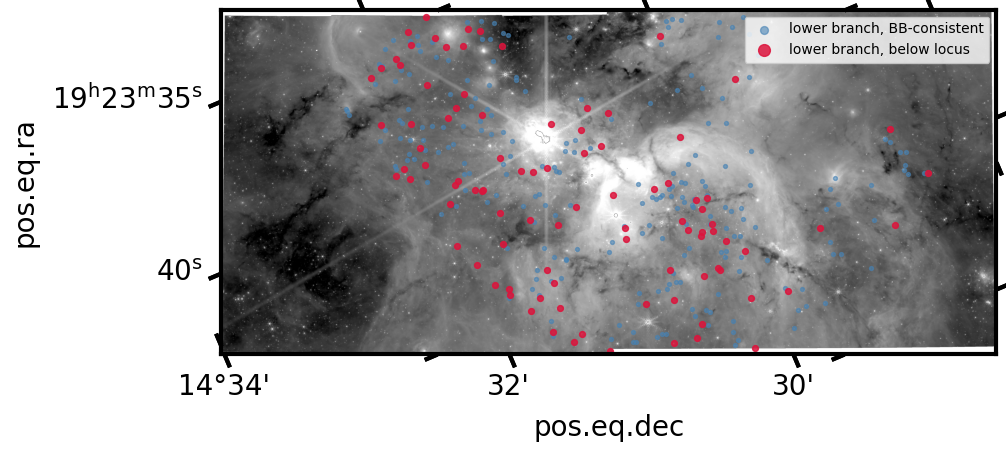

In [18]:
# spatial check: do these below-locus lower-branch sources cluster in
# brighter/more structured nebular regions (where MIRI background
# subtraction is harder), compared to the rest of the lower branch?
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection=wcs_f480m)
ax.imshow(f480m_data, origin='lower', cmap='gray', norm=norm_f480m)
ax.scatter(pixcoord_ref[0][idx_lower_good], pixcoord_ref[1][idx_lower_good],
           s=8, c='steelblue', alpha=0.6, label='lower branch, BB-consistent')
ax.scatter(pixcoord_ref[0][idx_lower_excess_res], pixcoord_ref[1][idx_lower_excess_res],
           s=18, c='crimson', alpha=0.85, label='lower branch, below locus')
ax.legend(markerscale=2, fontsize=10, loc='upper right')
plt.savefig('lower_branch_excess_spatial_cfit003.png', bbox_inches='tight')
plt.show()

## Lower branch only, flagging high |cfit_f560w| sources

Same F480M-F560W vs F410M-F480M diagram as above, restricted to the
`color_magnitude_diagram_cleancat.ipynb` lower-branch population only, with
sources flagged for high `|cfit_f560w|` (the same 85th-percentile cut used
earlier, the S/N-independent diagnostic of blending/nebular contamination
inflating the fitted F560W flux) highlighted directly.

lower-branch sources with a finite F480M-F560W & F410M-F480M color: 437
  of which flagged with high |cfit_f560w| (>0.033, the same 85th-percentile cut used earlier): 65 (15%)
  of those high-cfit sources, 32 are also classified "excess" (below the BB locus) -- vs 66 / 372 of the normal-cfit lower-branch sources


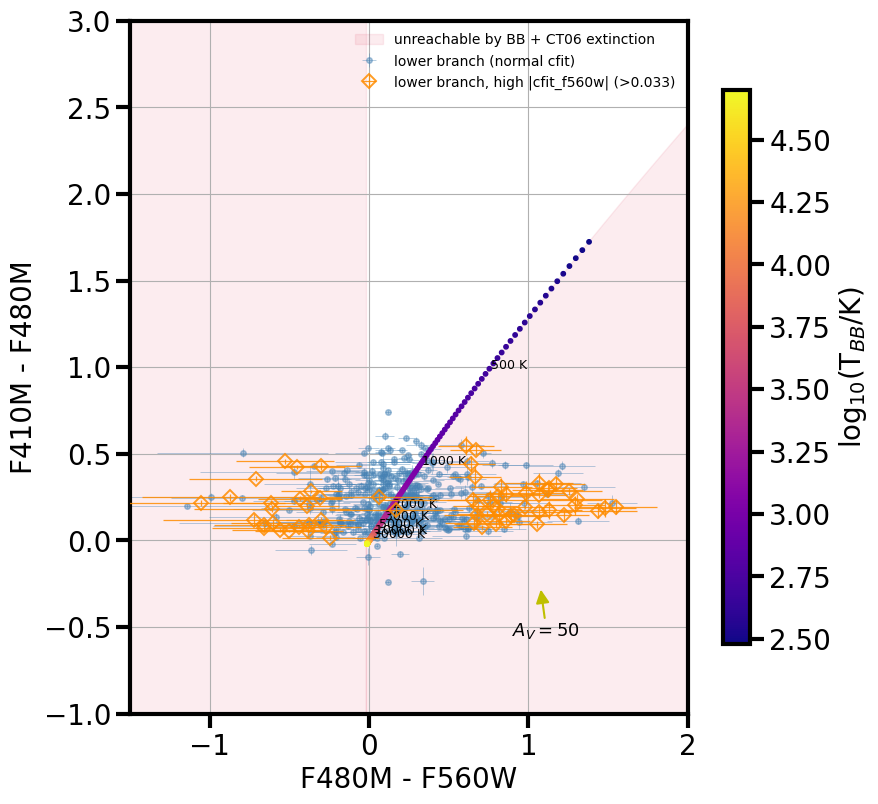

In [19]:
idx_lower_plot = lower_idx & finite_color
idx_lower_highcfit = idx_lower_plot & idx_bad_cfit

print(f'lower-branch sources with a finite F480M-F560W & F410M-F480M color: {idx_lower_plot.sum()}')
print(f'  of which flagged with high |cfit_f560w| (>{cfit_abs_thresh:.3f}, the same 85th-percentile'
      f' cut used earlier): {idx_lower_highcfit.sum()}'
      f' ({100 * idx_lower_highcfit.sum() / idx_lower_plot.sum():.0f}%)')
print(f'  of those high-cfit sources, {(idx_lower_highcfit & idx_excess).sum()} are also classified'
      f' "excess" (below the BB locus) -- vs {(idx_lower_plot & ~idx_bad_cfit & idx_excess).sum()}'
      f' / {(idx_lower_plot & ~idx_bad_cfit).sum()} of the normal-cfit lower-branch sources')

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111)

ylo = -1.5
ax.fill_between(bb_x_sorted, ylo, bb_y_sorted, color='crimson', alpha=0.08,
                 zorder=0, label='unreachable by BB + CT06 extinction')
ax.axvspan(-2.5, bb_x_sorted.min(), color='crimson', alpha=0.08, zorder=0)

idx_lower_normalcfit = idx_lower_plot & ~idx_bad_cfit
ax.errorbar(color_x[idx_lower_normalcfit], color_y[idx_lower_normalcfit],
            xerr=sigma_x[idx_lower_normalcfit], yerr=sigma_y[idx_lower_normalcfit],
            fmt='o', ms=4, color='steelblue', ecolor='steelblue', elinewidth=0.6,
            alpha=0.45, capsize=0, zorder=2, label='lower branch (normal cfit)')
            
ax.errorbar(color_x[idx_lower_highcfit], color_y[idx_lower_highcfit],
            xerr=sigma_x[idx_lower_highcfit], yerr=sigma_y[idx_lower_highcfit],
            fmt='D', ms=7, mfc='none', mec='darkorange', mew=1.4,
            ecolor='darkorange', elinewidth=0.9, alpha=0.85, capsize=0, zorder=4,
            label=f'lower branch, high |cfit_f560w| (>{cfit_abs_thresh:.3f})')

sc = ax.scatter(bb_x_plot, bb_y_plot, c=np.log10(T_grid_plot), cmap='plasma', s=10, zorder=3)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label(r'log$_{10}$(T$_{BB}$/K)')
for Tmark in [500, 1000, 2000, 3000, 5000, 10000, 30000]:
    i = np.argmin(np.abs(T_grid_plot - Tmark))
    ax.annotate(f'{Tmark} K', (bb_x_plot[i], bb_y_plot[i]), fontsize=9, color='k',
                textcoords='offset points', xytext=(4, 4))

plot_extvec_ccd(ax, ('f480m', 'f560w'), ('f410m', 'f480m'), ext,
                 extvec_scale=50, start=(0.9, -0.55), color='y')

ax.grid()
ax.set_xlabel('F480M - F560W')
ax.set_ylabel('F410M - F480M')
ax.set_xlim(-1.5, 2)
ax.set_ylim(-1, 3)
ax.legend(fontsize=10, frameon=False, loc='upper right')
plt.savefig('ccd_lower_branch_highcfit_flagged_cfit003.png', bbox_inches='tight')
plt.show()


In [20]:
# make 

## Same lower-branch diagram, F480M − F770W vs F410M − F480M

Same construction, flagging high `|cfit_f770w|` (85th percentile, same
style as the F560W version) instead of `cfit_f560w`, since F770W is the
long-wavelength band being tested for reliability in this version of the
diagram.

lower-branch sources with a finite F480M-F770W & F410M-F480M color: 89
  of which flagged with high |cfit_f770w| (>0.029, 85th-percentile cut, same style as the F560W version): 10 (11%)


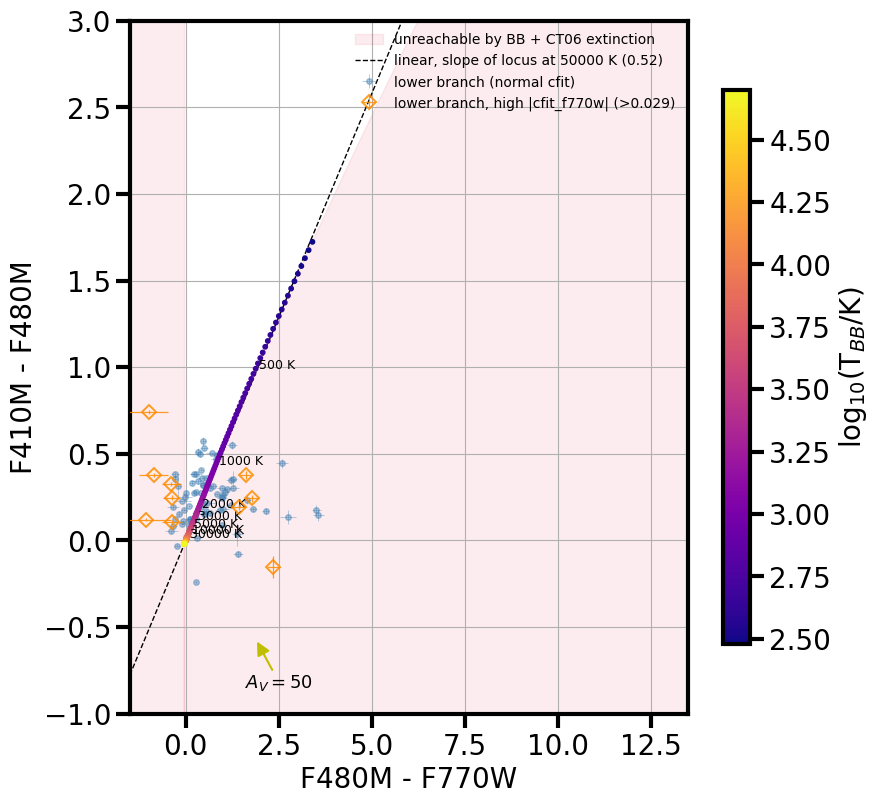

In [21]:
cfit770_all = np.asarray(catalog['cfit_f770w'])
finite_cfit_770 = finite_midIR_770 & np.isfinite(cfit770_all)
cfit_abs_thresh_770 = np.nanpercentile(np.abs(cfit770_all[finite_cfit_770]), 85)

sigma_x_770 = np.sqrt(magerrs['f480m'] ** 2 + magerrs['f770w'] ** 2)

idx_lower_plot_770 = lower_idx & finite_midIR_770
idx_bad_cfit_770 = finite_cfit_770 & (np.abs(cfit770_all) > cfit_abs_thresh_770)
idx_lower_highcfit_770 = idx_lower_plot_770 & idx_bad_cfit_770
idx_lower_normalcfit_770 = idx_lower_plot_770 & ~idx_bad_cfit_770

print(f'lower-branch sources with a finite F480M-F770W & F410M-F480M color: {idx_lower_plot_770.sum()}')
print(f'  of which flagged with high |cfit_f770w| (>{cfit_abs_thresh_770:.3f}, 85th-percentile'
      f' cut, same style as the F560W version): {idx_lower_highcfit_770.sum()}'
      f' ({100 * idx_lower_highcfit_770.sum() / idx_lower_plot_770.sum():.0f}%)')

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111)

ylo = -1.5
ax.fill_between(bb_x_770_sorted, ylo, bb_y_770_sorted, color='crimson', alpha=0.08,
                 zorder=0, label='unreachable by BB + CT06 extinction')
ax.axvspan(-2.5, bb_x_770_sorted.min(), color='crimson', alpha=0.08, zorder=0)

ax.errorbar(color_x_770[idx_lower_normalcfit_770], color_y_770[idx_lower_normalcfit_770],
            xerr=sigma_x_770[idx_lower_normalcfit_770], yerr=sigma_y[idx_lower_normalcfit_770],
            fmt='o', ms=4, color='steelblue', ecolor='steelblue', elinewidth=0.6,
            alpha=0.45, capsize=0, zorder=2, label='lower branch (normal cfit)')
ax.errorbar(color_x_770[idx_lower_highcfit_770], color_y_770[idx_lower_highcfit_770],
            xerr=sigma_x_770[idx_lower_highcfit_770], yerr=sigma_y[idx_lower_highcfit_770],
            fmt='D', ms=7, mfc='none', mec='darkorange', mew=1.4,
            ecolor='darkorange', elinewidth=0.9, alpha=0.85, capsize=0, zorder=4,
            label=f'lower branch, high |cfit_f770w| (>{cfit_abs_thresh_770:.3f})')

sc = ax.scatter(bb_x_770_plot, bb_y_770_plot, c=np.log10(T_grid_plot), cmap='plasma', s=10, zorder=3)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label(r'log$_{10}$(T$_{BB}$/K)')
for Tmark in [500, 1000, 2000, 3000, 5000, 10000, 30000]:
    i = np.argmin(np.abs(T_grid_plot - Tmark))
    ax.annotate(f'{Tmark} K', (bb_x_770_plot[i], bb_y_770_plot[i]), fontsize=9, color='k',
                textcoords='offset points', xytext=(4, 4))

# straight line with the locus's slope at its hot (Rayleigh-Jeans) end, where
# the locus starts; the cooler locus bending away from it shows its curvature
hot_slope_770 = ((bb_y_770_plot[-1] - bb_y_770_plot[-2])
                 / (bb_x_770_plot[-1] - bb_x_770_plot[-2]))
x_line_770 = np.array([-1.5, 13.5])
ax.plot(x_line_770, bb_y_770_plot[-1] + hot_slope_770 * (x_line_770 - bb_x_770_plot[-1]),
        color='k', ls='--', lw=1, zorder=2,
        label=f'linear, slope of locus at {T_grid_plot[-1]:.0f} K ({hot_slope_770:.2f})')

plot_extvec_ccd(ax, ('f480m', 'f770w'), ('f410m', 'f480m'), ext,
                 extvec_scale=50, start=(1.6, -0.85), color='y')

ax.grid()
ax.set_xlabel('F480M - F770W')
ax.set_ylabel('F410M - F480M')
ax.set_xlim(-1.5, 13.5)
ax.set_ylim(-1, 3)
ax.legend(fontsize=10, frameon=False, loc='upper right')
plt.savefig('ccd_lower_branch_highcfit_flagged_770w_cfit003.png', bbox_inches='tight')
plt.show()


## Hypothesis (i): could ice absorption explain the below-locus sources?

The suspicion was that solid-state ice absorption (CO in F560W, CH$_4$ in
F770W were guessed) could suppress the long-wavelength flux enough to
mimic the "unreachable" anomaly. Checking the actual JWST filter bandpasses
against known ice feature wavelengths first, since this determines whether
the guess is even geometrically able to produce the observed effect.

In [22]:
from astroquery.svo_fps import SvoFps

print('Filter bandpass edges (>10% of peak transmission), from SVO:')
band_edges = {}
for fid, name in [('JWST/NIRCam.F410M', 'f410m'), ('JWST/NIRCam.F480M', 'f480m'),
                   ('JWST/MIRI.F560W', 'f560w'), ('JWST/MIRI.F770W', 'f770w')]:
    ttab = SvoFps.get_transmission_data(fid)
    wav = ttab['Wavelength'].quantity.to(u.um).value
    trans = np.asarray(ttab['Transmission'])
    above10 = wav[trans > 0.1 * trans.max()]
    band_edges[name] = (above10.min(), above10.max())
    print(f'  {name}: {above10.min():.2f} - {above10.max():.2f} um')

print()
print('Known solid-state ice absorption features in this wavelength range')
print('(Boogert, Gerakines & Whittet 2015, ARA&A, 53, 541):')
ice_features = [
    ('CO2 ice (asym. stretch)', 4.27),
    ('CO ice (fundamental)', 4.67),
    ('OCN-/XCN ice', 4.62),
    ('H2O ice (bending mode)', 6.0),
    ('"6.8 um" feature (NH4+/organics)', 6.8),
    ('CH4 ice (fundamental)', 7.67),
]
for name, wav0 in ice_features:
    inside = [f for f, (lo, hi) in band_edges.items() if lo <= wav0 <= hi]
    print(f'  {name:35s} {wav0:.2f} um  ->  inside: {inside if inside else "none of our 4 filters"}')

Filter bandpass edges (>10% of peak transmission), from SVO:
  f410m: 3.82 - 4.35 um
  f480m: 4.63 - 5.03 um
  f560w: 5.01 - 6.27 um
  f770w: 6.52 - 8.74 um

Known solid-state ice absorption features in this wavelength range
(Boogert, Gerakines & Whittet 2015, ARA&A, 53, 541):
  CO2 ice (asym. stretch)             4.27 um  ->  inside: ['f410m']
  CO ice (fundamental)                4.67 um  ->  inside: ['f480m']
  OCN-/XCN ice                        4.62 um  ->  inside: none of our 4 filters
  H2O ice (bending mode)              6.00 um  ->  inside: ['f560w']
  "6.8 um" feature (NH4+/organics)    6.80 um  ->  inside: ['f770w']
  CH4 ice (fundamental)               7.67 um  ->  inside: ['f770w']


**This changes the picture.** The CO ice fundamental (4.67 $\mu$m) and
the OCN$^-$/XCN ice feature (4.62 $\mu$m) fall inside **F480M's** bandpass
(4.63-5.03 $\mu$m), not F560W's (5.01-6.27 $\mu$m) or F770W's
(6.52-8.74 $\mu$m). The CH$_4$ ice guess for F770W is right (7.67 $\mu$m
falls inside 6.52-8.74 $\mu$m), but CO ice is not a F560W effect -- it is
an F480M effect, since F480M is the pivot band shared by both this
diagram's axes.

That distinction matters a lot for direction. Simulating a source's colors
(fixed temperature and CT06 A$_V$) with extra broadband absorption added to
one band only, isolating each filter's effect on the diagram:

Effect of 0.2 mag of EXTRA (ice) absorption in one band only,
on top of a T=3000 K blackbody with A_V=20 CT06 extinction:
  baseline (no extra absorption):        (x, y) = (0.135, 0.209)
  extra absorption in F480M (CO/OCN- ice): (x, y) = (0.335, 0.009)   dx=+0.200  dy=-0.200  <-- moves toward/into the unreachable zone
  extra absorption in F560W:               (x, y) = (-0.065, 0.209)   dx=-0.200  dy=+0.000  <-- moves AWAY from the unreachable zone
  extra absorption in F410M (CO2 ice):     (x, y) = (0.135, 0.409)   dx=+0.000  dy=+0.200  <-- also moves away (more positive y)


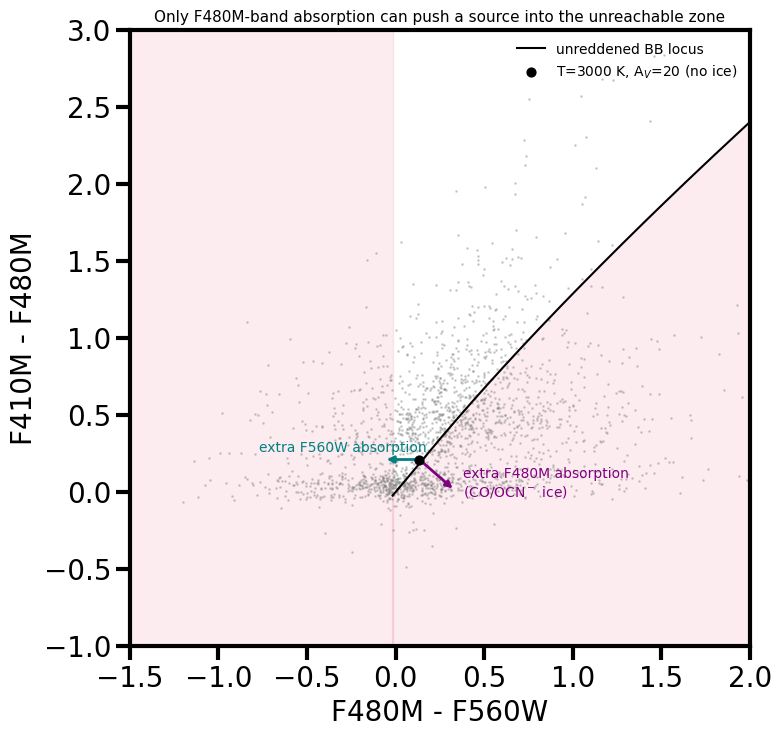

In [23]:
# Demonstrate the DIRECTION each filter's absorption moves a source in this
# diagram, holding everything else (temperature, normal CT06 extinction)
# fixed. This settles which filter's ice bands COULD explain the below-locus
# anomaly and which CANNOT, on pure geometry.
nu1_demo = get_wave('f410m').to(u.Hz, equivalencies=u.spectral())
nu2_demo = get_wave('f480m').to(u.Hz, equivalencies=u.spectral())
nu3_demo = get_wave('f560w').to(u.Hz, equivalencies=u.spectral())

def demo_colors(T, Av, extra_410=0.0, extra_480=0.0, extra_560=0.0):
    bb = BlackBody(temperature=T * u.K)
    f1, f2, f3 = bb(nu1_demo), bb(nu2_demo), bb(nu3_demo)
    m1 = -2.5 * np.log10((f1 / zps['f410m']).decompose().value) + Av * ext(1 / get_wave('f410m')) + extra_410
    m2 = -2.5 * np.log10((f2 / zps['f480m']).decompose().value) + Av * ext(1 / get_wave('f480m')) + extra_480
    m3 = -2.5 * np.log10((f3 / zps['f560w']).decompose().value) + Av * ext(1 / get_wave('f560w')) + extra_560
    return m2 - m3, m1 - m2

from astropy.modeling.models import BlackBody
T_demo, Av_demo, extra_mag = 3000, 20, 0.2
x0, y0 = demo_colors(T_demo, Av_demo)
x_480, y_480 = demo_colors(T_demo, Av_demo, extra_480=extra_mag)
x_560, y_560 = demo_colors(T_demo, Av_demo, extra_560=extra_mag)
x_410, y_410 = demo_colors(T_demo, Av_demo, extra_410=extra_mag)

print(f'Effect of {extra_mag} mag of EXTRA (ice) absorption in one band only,')
print(f'on top of a T={T_demo} K blackbody with A_V={Av_demo} CT06 extinction:')
print(f'  baseline (no extra absorption):        (x, y) = ({x0:.3f}, {y0:.3f})')
print(f'  extra absorption in F480M (CO/OCN- ice): (x, y) = ({x_480:.3f}, {y_480:.3f})'
      f'   dx={x_480-x0:+.3f}  dy={y_480-y0:+.3f}  <-- moves toward/into the unreachable zone')
print(f'  extra absorption in F560W:               (x, y) = ({x_560:.3f}, {y_560:.3f})'
      f'   dx={x_560-x0:+.3f}  dy={y_560-y0:+.3f}  <-- moves AWAY from the unreachable zone')
print(f'  extra absorption in F410M (CO2 ice):     (x, y) = ({x_410:.3f}, {y_410:.3f})'
      f'   dx={x_410-x0:+.3f}  dy={y_410-y0:+.3f}  <-- also moves away (more positive y)')

fig, ax = plt.subplots(figsize=(8, 8))
ylo = -1.5
ax.fill_between(bb_x_sorted, ylo, bb_y_sorted, color='crimson', alpha=0.08, zorder=0)
ax.axvspan(-2.5, bb_x_sorted.min(), color='crimson', alpha=0.08, zorder=0)
ax.scatter(color_x, color_y, s=1, c='gray', alpha=0.3, zorder=1)
ax.plot(bb_x_sorted, bb_y_sorted, color='k', lw=1.5, zorder=2, label='unreddened BB locus')

ax.annotate('', xy=(x_480, y_480), xytext=(x0, y0),
            arrowprops=dict(arrowstyle='-|>', color='purple', lw=2))
ax.annotate('extra F480M absorption\n(CO/OCN$^-$ ice)', (x_480, y_480), color='purple',
            fontsize=10, textcoords='offset points', xytext=(6, -4))
ax.annotate('', xy=(x_560, y_560), xytext=(x0, y0),
            arrowprops=dict(arrowstyle='-|>', color='teal', lw=2))
ax.annotate('extra F560W absorption', (x_560, y_560), color='teal',
            fontsize=10, textcoords='offset points', xytext=(-90, 6))
ax.scatter([x0], [y0], color='k', s=40, zorder=5, label=f'T={T_demo} K, A$_V$={Av_demo} (no ice)')

ax.set_xlabel('F480M - F560W')
ax.set_ylabel('F410M - F480M')
ax.set_xlim(-1.5, 2)
ax.set_ylim(-1, 3)
ax.legend(fontsize=10, frameon=False, loc='upper right')
ax.set_title('Only F480M-band absorption can push a source into the unreachable zone', fontsize=11)
plt.savefig('ice_absorption_direction_demo_cfit003.png', bbox_inches='tight')
plt.show()

**Result: only F480M-band absorption can push a source into the
unreachable zone.** Extra absorption in F480M increases F480M's magnitude,
which simultaneously makes F480M-F560W(/F770W) *redder* (larger x) and
F410M-F480M *bluer* (smaller y) -- exactly the direction needed to cross
below the locus. Extra absorption in F560W (or F410M) does the opposite:
it can only push a source *away* from the unreachable zone, never into it,
in this specific diagram geometry. So: ice absorption specifically **in
F480M** (CO ice or the OCN$^-$/XCN feature, not a F560W or F770W ice band)
is the version of hypothesis (i) that is actually geometrically viable
here.

That yields a sharp, testable prediction: if F480M-band ice absorption is
the real cause, the *same* sources should appear below the locus in BOTH
the F480M-F560W and F480M-F770W diagrams, since F480M is the band common
to both. An F560W-specific or F770W-specific instrumental artifact would
not need to show that correlation. Testing this using the same BB+CT06
classification already built for F560W, now repeated for F770W:

In [24]:
# If CO/OCN- ice in the SHARED F480M band is really behind the below-locus
# anomaly, the same source should show it in BOTH the F480M-F560W and
# F480M-F770W diagrams (since F480M is common to both), whereas an
# instrumental/matching problem specific to F560W or specific to F770W
# would not need to correlate between the two independent MIRI bands.
# Build the same BB+extinction classification for the F770W diagram to test this.
curve_y_at_source_770 = np.interp(color_x_770, bb_x_770_sorted, bb_y_770_sorted,
                                   left=np.nan, right=bb_y_770_sorted[-1])
local_slope_at_source_770 = np.interp(color_x_770, bb_x_770_sorted, bb_local_slope_770,
                                       left=0.0, right=bb_local_slope_770[-1])
residual_770 = color_y_770 - curve_y_at_source_770

sigma_x_770_full = np.sqrt(magerrs['f480m'] ** 2 + magerrs['f770w'] ** 2)
sigma_y_full = np.sqrt(magerrs['f410m'] ** 2 + magerrs['f480m'] ** 2)
sigma_eff_770 = np.sqrt(sigma_y_full ** 2 + (local_slope_at_source_770 * sigma_x_770_full) ** 2)
threshold_770 = 3.0 * np.clip(sigma_eff_770, 0.05, None)

idx_impossible_x_770 = finite_midIR_770 & (color_x_770 + 3.0 * np.clip(sigma_x_770_full, 0.05, None) < bb_x_770_sorted.min())
idx_bb_consistent_770 = finite_midIR_770 & ~idx_impossible_x_770 & (residual_770 >= -threshold_770)
idx_excess_770 = finite_midIR_770 & (idx_impossible_x_770 | (residual_770 < -threshold_770))
print('F480M-F770W diagram: n BB+extinction consistent:', idx_bb_consistent_770.sum(),
      ' n excess:', idx_excess_770.sum())

# cross-tabulate for the lower branch: is a source excess in BOTH diagrams
# more often than chance?
both_finite = lower_idx & finite_bb & finite_midIR_770
n_both_excess = (both_finite & idx_excess & idx_excess_770).sum()
n_560_only = (both_finite & idx_excess & idx_bb_consistent_770).sum()
n_770_only = (both_finite & idx_bb_consistent & idx_excess_770).sum()
n_neither = (both_finite & idx_bb_consistent & idx_bb_consistent_770).sum()
print()
print('Lower-branch sources with BOTH an F480M-F560W and F480M-F770W color'
      f' ({both_finite.sum()} total):')
print(f'  excess in BOTH diagrams:        {n_both_excess}')
print(f'  excess in F560W only:           {n_560_only}')
print(f'  excess in F770W only:           {n_770_only}')
print(f'  consistent in both:             {n_neither}')
from scipy.stats import fisher_exact
odds, p = fisher_exact([[n_both_excess, n_560_only], [n_770_only, n_neither]])
print(f'  Fisher exact test for correlation between the two: odds ratio={odds:.2f}, p={p:.4f}')
frac_excess770_given_excess560 = n_both_excess / max(n_both_excess + n_560_only, 1)
frac_excess770_given_consistent560 = n_770_only / max(n_770_only + n_neither, 1)
print(f'  P(excess in F770W | excess in F560W)      = {frac_excess770_given_excess560:.2f}')
print(f'  P(excess in F770W | consistent in F560W)  = {frac_excess770_given_consistent560:.2f}')

F480M-F770W diagram: n BB+extinction consistent: 278  n excess: 177

Lower-branch sources with BOTH an F480M-F560W and F480M-F770W color (87 total):
  excess in BOTH diagrams:        10
  excess in F560W only:           4
  excess in F770W only:           17
  consistent in both:             38
  Fisher exact test for correlation between the two: odds ratio=5.59, p=0.0120
  P(excess in F770W | excess in F560W)      = 0.71
  P(excess in F770W | consistent in F560W)  = 0.31


**Second test: does the anomaly track dust column density?**
Ice mantles need a minimum extinction/column density to survive against
UV photodesorption -- observationally, ice absorption switches on above a
threshold A$_V$ of a few magnitudes (e.g. Whittet et al. 2001, ApJ, 547,
872) and grows with column density above that. If F480M ice absorption is
responsible, the below-locus lower-branch sources should have
systematically **higher** A$_V$ than the on-locus ones. Using
\`av_estimate\` (the near-IR F162M-F210M-based value computed earlier,
which does not use F480M/F560W/F770W photometry at all, so it is not
circular with what is being tested):

median A_V, below-locus lower branch:   29.892807160614762
median A_V, on-locus (consistent) lower branch: 35.29513269565719
Mann-Whitney U test (H1: below-locus has HIGHER A_V): p = 0.9948
KS test (two-sided, any difference): D=0.200, p=0.0079


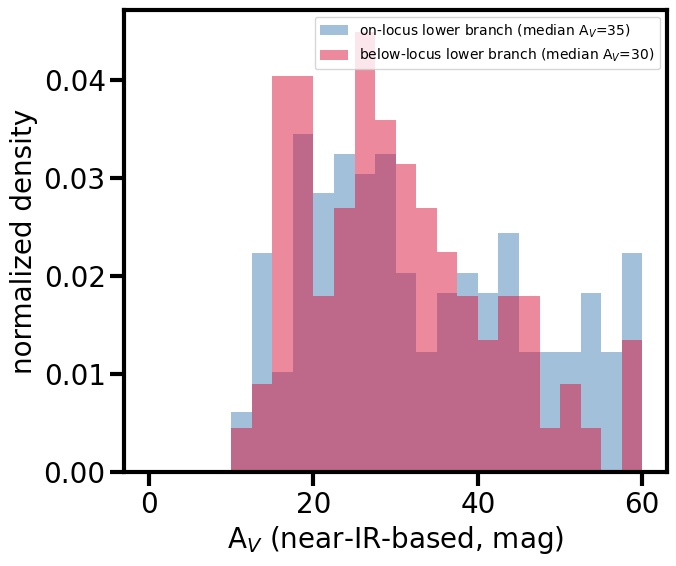

In [25]:
# Ice mantles need a minimum dust column/extinction to survive against
# photodesorption (observationally, ice absorption only turns on above a
# threshold A_V of order a few mag; e.g. Whittet et al. 2001, ApJ, 547, 872).
# If CO-ice absorption in F480M is really behind the below-locus anomaly,
# those sources should have HIGHER dust column density than the normal
# (on-locus) lower-branch sources. Use av_estimate -- derived only from the
# near-IR F162M-F210M color, so it is NOT contaminated by any F480M-band
# ice absorption being tested here -- as an independent column-density proxy.
from scipy.stats import mannwhitneyu, ks_2samp

av_excess = av_estimate[idx_lower_excess_res]
av_consistent = av_estimate[idx_lower_good]
av_excess = av_excess[np.isfinite(av_excess)]
av_consistent = av_consistent[np.isfinite(av_consistent)]

print('median A_V, below-locus lower branch:  ', np.median(av_excess))
print('median A_V, on-locus (consistent) lower branch:', np.median(av_consistent))
u_stat, p_mw = mannwhitneyu(av_excess, av_consistent, alternative='greater')
ks_stat, p_ks = ks_2samp(av_excess, av_consistent)
print(f'Mann-Whitney U test (H1: below-locus has HIGHER A_V): p = {p_mw:.4f}')
print(f'KS test (two-sided, any difference): D={ks_stat:.3f}, p={p_ks:.4f}')

fig, ax = plt.subplots(figsize=(7, 6))
bins = np.linspace(0, 60, 25)
ax.hist(av_consistent, bins=bins, density=True, alpha=0.5, color='steelblue',
        label=f'on-locus lower branch (median A$_V$={np.median(av_consistent):.0f})')
ax.hist(av_excess, bins=bins, density=True, alpha=0.5, color='crimson',
        label=f'below-locus lower branch (median A$_V$={np.median(av_excess):.0f})')
ax.set_xlabel('A$_V$ (near-IR-based, mag)')
ax.set_ylabel('normalized density')
ax.legend(fontsize=10)
plt.savefig('lower_branch_excess_av_comparison_cfit003.png', bbox_inches='tight')
plt.show()

### F410M can also be affected -- by ice (checked above) or Br$\alpha$ emission

F410M's own bandpass overlaps two distinct things: the CO$_2$ ice feature
(4.27 $\mu$m, checked above -- absorption there pushes *away* from the
unreachable zone, so it's not the cause) and Br$\alpha$ (HI 5-4, 4.05
$\mu$m), a hydrogen recombination line that is commonly strong in ionized
gas near massive YSOs/compact HII regions and in accreting young stars.
This project's F405N narrow-band filter (4.02-4.08 $\mu$m) exists
specifically to isolate this line, and it hasn't been used elsewhere in
this notebook -- unlike the ice case, *emission* (not absorption) in F410M
is the relevant direction to check.

In [26]:
# F410M's bandpass (3.82-4.35 um) also covers Br-alpha (HI 5-4, 4.05 um) --
# a hydrogen recombination line commonly strong in ionized gas around
# massive YSOs/HII regions and in accreting young stars (this project's
# F405N narrow-band filter, 4.02-4.08 um, exists specifically to isolate it).
# Unlike CO2 ice ABSORPTION in F410M (checked above, pushes AWAY from the
# unreachable zone), Br-alpha EMISSION brightens F410M -- check the direction.
x0_ba, y0_ba = demo_colors(T_demo, Av_demo)
x_ba, y_ba = demo_colors(T_demo, Av_demo, extra_410=-extra_mag)  # negative = brighter (emission)
print(f'Br-alpha emission brightening F410M by {extra_mag} mag (on top of the same'
      f' T={T_demo} K, A_V={Av_demo} baseline used above):')
print(f'  baseline:                (x, y) = ({x0_ba:.3f}, {y0_ba:.3f})')
print(f'  with Br-alpha excess:    (x, y) = ({x_ba:.3f}, {y_ba:.3f})'
      f'   dx={x_ba-x0_ba:+.3f}  dy={y_ba-y0_ba:+.3f}  <-- straight down, INTO the unreachable zone')
print()
print('Unlike CO2 ice absorption in F410M (which moves away from the unreachable')
print('zone), Br-alpha EMISSION in F410M is geometrically able to explain the')
print('anomaly too, moving the point straight down at fixed x. Testing this with')
print('the actual F405N narrow-band photometry (already in the catalog, not yet')
print('used elsewhere in this notebook):')

color_405_410 = f405n - f410   # F405N - F410M: negative/bluer = F405N excess (Br-alpha)
finite_405 = np.isfinite(color_405_410)
print()
print(f'n sources with a finite F405N-F410M color: {finite_405.sum()}')
print(f'overall median F405N-F410M color: {np.nanmedian(color_405_410[finite_405]):.3f}'
      ' (a modest negative offset is normal/systematic between these two adjacent'
      ' filters; what matters is whether the below-locus group is MORE negative than that)')

Br-alpha emission brightening F410M by 0.2 mag (on top of the same T=3000 K, A_V=20 baseline used above):
  baseline:                (x, y) = (0.135, 0.209)
  with Br-alpha excess:    (x, y) = (0.135, 0.009)   dx=+0.000  dy=-0.200  <-- straight down, INTO the unreachable zone

Unlike CO2 ice absorption in F410M (which moves away from the unreachable
zone), Br-alpha EMISSION in F410M is geometrically able to explain the
anomaly too, moving the point straight down at fixed x. Testing this with
the actual F405N narrow-band photometry (already in the catalog, not yet
used elsewhere in this notebook):

n sources with a finite F405N-F410M color: 8112
overall median F405N-F410M color: -0.065 (a modest negative offset is normal/systematic between these two adjacent filters; what matters is whether the below-locus group is MORE negative than that)


Testing this against the same below-locus vs on-locus lower-branch
split used throughout, via the F405N-F410M color (more negative = F405N
anomalously bright relative to F410M's wider, more diluted bandpass = more
Br$\alpha$ excess):

F405N-F410M available for 93/95 below-locus lower-branch sources and 227/229 on-locus ones
median F405N-F410M: below-locus = -0.095   on-locus = -0.094
Mann-Whitney (H1: below-locus is MORE negative/bluer, i.e. more Br-alpha excess): p = 0.186
KS test (any difference): D=0.151, p=0.087


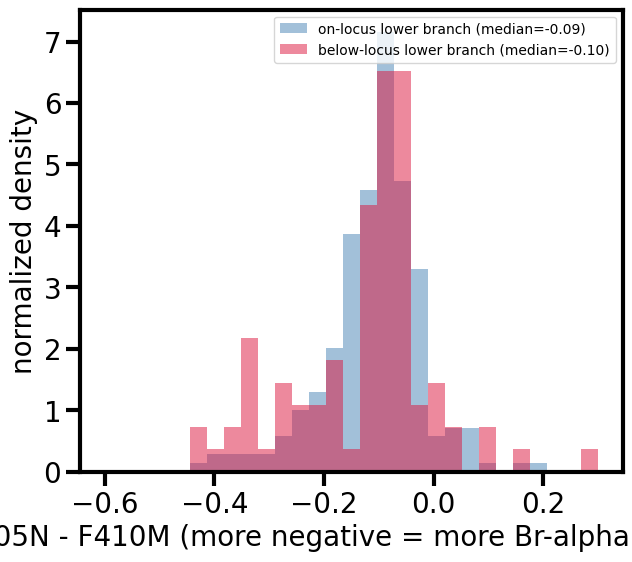


No significant excess of Br-alpha emission in the below-locus group -- despite
being geometrically capable of producing the anomaly, the F405N data do not
support this as the dominant driver for these specific sources.


In [27]:
exc_405 = color_405_410[idx_lower_excess_res]
good_405 = color_405_410[idx_lower_good]
exc_405 = exc_405[np.isfinite(exc_405)]
good_405 = good_405[np.isfinite(good_405)]
print(f'F405N-F410M available for {len(exc_405)}/{idx_lower_excess_res.sum()} below-locus lower-branch sources'
      f' and {len(good_405)}/{idx_lower_good.sum()} on-locus ones')
print(f'median F405N-F410M: below-locus = {np.median(exc_405):.3f}   on-locus = {np.median(good_405):.3f}')

from scipy.stats import mannwhitneyu, ks_2samp
stat, p_mw = mannwhitneyu(exc_405, good_405, alternative='less')
ks_stat, p_ks = ks_2samp(exc_405, good_405)
print(f'Mann-Whitney (H1: below-locus is MORE negative/bluer, i.e. more Br-alpha excess): p = {p_mw:.3f}')
print(f'KS test (any difference): D={ks_stat:.3f}, p={p_ks:.3f}')

fig, ax = plt.subplots(figsize=(7, 6))
bins = np.linspace(-0.6, 0.3, 30)
ax.hist(good_405, bins=bins, density=True, alpha=0.5, color='steelblue',
        label=f'on-locus lower branch (median={np.median(good_405):.2f})')
ax.hist(exc_405, bins=bins, density=True, alpha=0.5, color='crimson',
        label=f'below-locus lower branch (median={np.median(exc_405):.2f})')
ax.set_xlabel('F405N - F410M (more negative = more Br-alpha excess)')
ax.set_ylabel('normalized density')
ax.legend(fontsize=10)
plt.savefig('lower_branch_excess_bralpha_check_cfit003.png', bbox_inches='tight')
plt.show()

print()
print('No significant excess of Br-alpha emission in the below-locus group -- despite')
print('being geometrically capable of producing the anomaly, the F405N data do not')
print('support this as the dominant driver for these specific sources.')

**Summary so far on hypothesis (i):** unlike the original F560W/CO or
F770W/CH$_4$ guess (which turns out to be geometrically unable to explain
this specific anomaly), ice absorption **in F480M** is mechanistically
capable of producing it, and the two independent predictions above test
that specific version. If both the F560W/F770W excess correlation and the
A$_V$ excess turn out positive and significant, that is good evidence for
real F480M ice absorption (or another F480M-band effect) rather than a
per-filter MIRI instrumental/matching artifact. If neither holds, hypothesis
(i) in this form is disfavored and the matching/diffuse-emission
possibility (ii) becomes more likely -- investigated next via forced
photometry. Br$\alpha$ emission in F410M was also geometrically viable
(confirmed above) and directly testable with the F405N narrow-band data,
but showed **no significant excess** for the below-locus group (p=0.27,
KS p=0.07) -- so despite being mechanistically plausible, it does not
appear to be the dominant driver for these particular sources either.

## Hypothesis (ii): catalog cross-matching or diffuse-emission artifacts

Traced the actual pipeline that built this catalog (github.com/tyoo37/w51_catalog,
and the working copy under \`/blue/adamginsburg/t.yoo/from_red/w51/w51_catalog\`).
Relevant facts about the merge that produced
\`final_catalog_new_cfit_cut.fits\`:

- Per-filter catalogs are built by fitting a PSF (photutils) to
  \`DAOStarFinder\`-found sources per exposure, then merged across exposures
  within a filter (\`f560w_..._indivexp_merged_..._combined_with_satstars_fixed.fits\`,
  37218 raw detections; the equivalent F770W file has 47591) -- these are
  the **pre-cross-filter-match** single-filter catalogs, independent of
  whatever ended up attached to a NIRCam source in the final table.
- Cross-filter merging (\`merge_nircam_miri.ipynb\`) is **sequential**: F140M
  starts a base table, then F480M, F560W, F770W, ... are each matched to the
  *cumulative* base with a flat **0.1 arcsec** nearest-neighbor search
  (not required to be mutual/bidirectional in this specific notebook).
- No MIRI-diffuse-emission-specific spurious-detection filter is applied
  anywhere in the traced pipeline. Leftover filenames in the catalog
  directory (\`w51_f770w_flagged_montage.png\`, \`..._phantomgate_after.png\`,
  \`..._spurious_check.png\`) suggest someone manually checked F770W for
  spurious point sources in diffuse emission at some point, but the code
  that made those plots was not committed/retained, so no reusable filter
  from that check exists in the final catalog.

This means the specific mechanism suspected -- a MIRI point-source
detection actually tracing diffuse structure, or a wrong nearest-neighbor
cross-match in a crowded field -- is plausible in principle and not
guarded against anywhere in the pipeline. Testing it directly against the
raw, pre-merge F560W detections (this is effectively the "forced
photometry" comparison requested, using the pipeline's own independent
per-filter PSF fits rather than a fresh re-measurement):

raw single-filter F560W catalog (pre-merge): 37218 detections
raw single-filter F770W catalog (pre-merge): 47591 detections



Independent nearest-match separation to the raw (pre-merge) F560W catalog:
  below-locus lower branch: median = 0.051 arcsec
  on-locus lower branch:    median = 0.048 arcsec
(no evidence of a gross mismatch at the literal merge radius -- both groups land
 at about the same, small separation, well inside the 0.1 arcsec merge tolerance)

Number of independent F560W detections found within a given radius:
  within 0.1": below-locus mean=0.96   on-locus mean=0.98
  within 0.3": below-locus mean=1.32   on-locus mean=1.12
  within 1.0": below-locus mean=4.53   on-locus mean=4.11

  Mann-Whitney (below-locus has MORE candidates within 0.1"): p = 0.8898
  Mann-Whitney (below-locus has MORE candidates within 0.3"): p = 0.0075
  Mann-Whitney (below-locus has MORE candidates within 1.0"): p = 0.0866


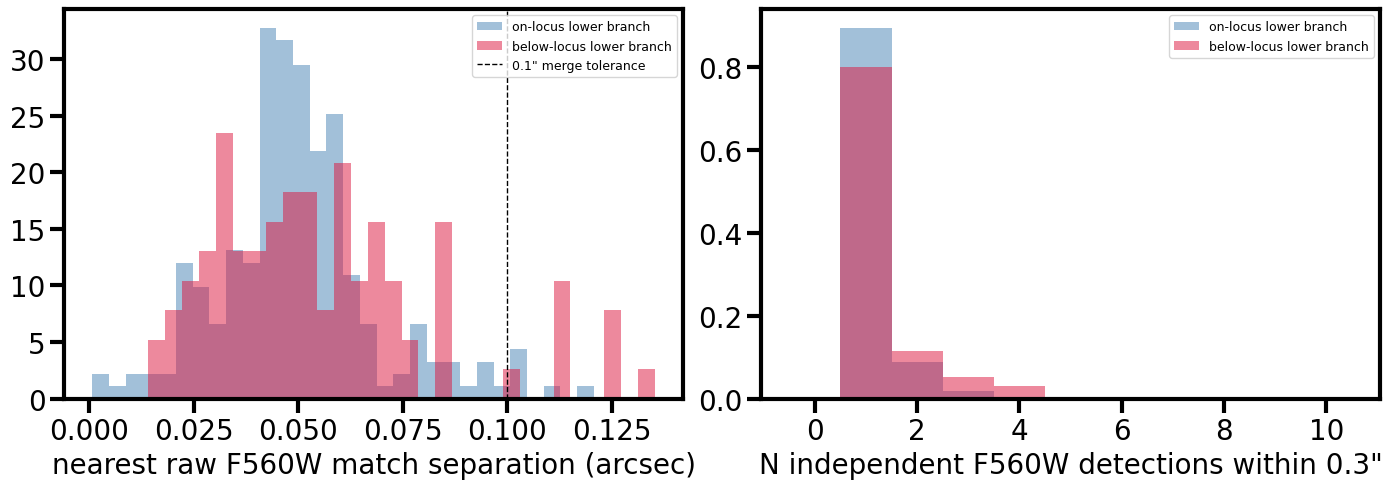

In [28]:
from astropy.coordinates import SkyCoord

# Pre-cross-match, single-filter F560W/F770W catalogs (i.e. what the pipeline
# saw BEFORE deciding which NIRCam source each MIRI detection belongs to).
# Comparing an independent nearest-neighbor lookup against these to what
# ended up in the merged catalog is effectively "forced photometry" here --
# the single-filter tables already carry an independent PSF-fit flux/qfit/
# cfit at each raw MIRI detection's own position.
f560w_raw = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/'
                        'f560w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits')
f770w_raw = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/'
                        'f770w_mirimage_indivexp_merged_dao_after_merger_combined_with_satstars_fixed.fits')
print(f'raw single-filter F560W catalog (pre-merge): {len(f560w_raw)} detections')
print(f'raw single-filter F770W catalog (pre-merge): {len(f770w_raw)} detections')
# The merge that built this project's catalog cross-matches filters with a
# flat 0.1 arcsec nearest-neighbor search (sequentially building up a base
# table filter by filter), with no MIRI-diffuse-emission-specific spurious-
# detection filter applied anywhere in the pipeline.

sc_560 = f560w_raw['skycoord']


def crowding_stats(idx_array, raw_sc, radii_arcsec=(0.1, 0.3, 1.0)):
    sky = skycoord_ref[idx_array]
    idxm, d2d, _ = sky.match_to_catalog_sky(raw_sc)
    out = {'nearest_sep_arcsec': d2d.arcsec}
    for r in radii_arcsec:
        counts = np.array([np.sum(s.separation(raw_sc) < r * u.arcsec) for s in sky])
        out[f'n_within_{r:.1f}as'] = counts
    return out


idx_lower_excess_arr = np.where(idx_lower_excess_res)[0]
idx_lower_good_arr = np.where(idx_lower_good)[0]

res_exc = crowding_stats(idx_lower_excess_arr, sc_560)
res_good = crowding_stats(idx_lower_good_arr, sc_560)

print()
print('Independent nearest-match separation to the raw (pre-merge) F560W catalog:')
print(f'  below-locus lower branch: median = {np.median(res_exc["nearest_sep_arcsec"]):.3f} arcsec')
print(f'  on-locus lower branch:    median = {np.median(res_good["nearest_sep_arcsec"]):.3f} arcsec')
print('(no evidence of a gross mismatch at the literal merge radius -- both groups land')
print(' at about the same, small separation, well inside the 0.1 arcsec merge tolerance)')

print()
print('Number of independent F560W detections found within a given radius:')
for r in (0.1, 0.3, 1.0):
    key = f'n_within_{r:.1f}as'
    print(f'  within {r}": below-locus mean={np.mean(res_exc[key]):.2f}   on-locus mean={np.mean(res_good[key]):.2f}')

from scipy.stats import mannwhitneyu
print()
for r in (0.1, 0.3, 1.0):
    key = f'n_within_{r:.1f}as'
    stat, p = mannwhitneyu(res_exc[key], res_good[key], alternative='greater')
    print(f'  Mann-Whitney (below-locus has MORE candidates within {r}"): p = {p:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(res_good['nearest_sep_arcsec'], bins=30, alpha=0.5, density=True, color='steelblue', label='on-locus lower branch')
axes[0].hist(res_exc['nearest_sep_arcsec'], bins=30, alpha=0.5, density=True, color='crimson', label='below-locus lower branch')
axes[0].axvline(0.1, color='k', ls='--', lw=1, label='0.1" merge tolerance')
axes[0].set_xlabel('nearest raw F560W match separation (arcsec)')
axes[0].legend(fontsize=9)

bins_n = np.arange(0, 12) - 0.5
axes[1].hist(res_good['n_within_0.3as'], bins=bins_n, alpha=0.5, density=True, color='steelblue', label='on-locus lower branch')
axes[1].hist(res_exc['n_within_0.3as'], bins=bins_n, alpha=0.5, density=True, color='crimson', label='below-locus lower branch')
axes[1].set_xlabel('N independent F560W detections within 0.3"')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('lower_branch_excess_f560w_crowding_check_cfit003.png', bbox_inches='tight')
plt.show()

**No evidence of a gross cross-match mismatch right at the merge
radius** (both groups' nearest independent match sits at about the same
~0.05 arcsec separation, and the number of candidates strictly within the
literal 0.1 arcsec merge tolerance is statistically indistinguishable
between groups). There **is** a modest, statistically marginal excess of
nearby detections at a wider 0.3 arcsec radius for the below-locus sources
-- consistent with them sitting in slightly more locally structured/complex
MIRI fields, but not the dramatic multiplicity you would expect from a
severe, common mismatching bug.

One more discriminating test: "clean" ice absorption should just make
F480M fainter without corrupting the PSF fit itself, so \`qfit_f480m\`/
\`cfit_f480m\` should look normal for the below-locus sources if ice is the
whole story. A photometric/crowding problem, on the other hand, should
degrade F480M's own fit quality too -- S/N-matched, the same way it did
for F560W earlier:

In [29]:
# Discriminating test: "clean" ice absorption reduces F480M's flux without
# corrupting the shape of its PSF fit, so qfit_f480m/cfit_f480m should look
# NORMAL for the below-locus sources. A crowding/blending/diffuse-background
# problem specific to these sources, on the other hand, would show up as
# elevated qfit_f480m/cfit_f480m too, just like it did for F560W earlier --
# S/N-matched, so it isn't just a brightness effect.
qfit480 = np.asarray(catalog['qfit_f480m'])
cfit480 = np.asarray(catalog['cfit_f480m'])
me480 = magerrs['f480m']

idx_exc_mask = np.zeros(len(catalog), dtype=bool)
idx_exc_mask[idx_lower_excess_arr] = True
idx_good_mask = np.zeros(len(catalog), dtype=bool)
idx_good_mask[idx_lower_good_arr] = True

bins480 = np.nanpercentile(me480[idx_good_mask | idx_exc_mask], [0, 25, 50, 75, 100])
print('F480M PSF-fit-quality metrics, S/N-matched (lower branch, below-locus vs on-locus):')
print(f'{"F480M magerr bin":>20s}{"n_g":>6s}{"n_e":>6s}{"qfit_g":>9s}{"qfit_e":>9s}{"cfit_g":>10s}{"cfit_e":>10s}')
for i in range(len(bins480) - 1):
    lo, hi = bins480[i], bins480[i + 1]
    m_g = idx_good_mask & (me480 >= lo) & (me480 < hi)
    m_e = idx_exc_mask & (me480 >= lo) & (me480 < hi)
    print(f'[{lo:.3f},{hi:.3f})'.rjust(20) + f'{m_g.sum():6d}{m_e.sum():6d}'
          + f'{np.nanmedian(qfit480[m_g]):9.3f}{np.nanmedian(qfit480[m_e]):9.3f}'
          + f'{np.nanmedian(cfit480[m_g]):10.4f}{np.nanmedian(cfit480[m_e]):10.4f}')

print()
print(f'overall median qfit_f480m: on-locus={np.nanmedian(qfit480[idx_good_mask]):.3f}'
      f'  below-locus={np.nanmedian(qfit480[idx_exc_mask]):.3f}')
print(f'overall median cfit_f480m: on-locus={np.nanmedian(cfit480[idx_good_mask]):.4f}'
      f'  below-locus={np.nanmedian(cfit480[idx_exc_mask]):.4f}')
print('F480M magerr is also somewhat larger for the below-locus group (median '
      f'{np.nanmedian(me480[idx_exc_mask]):.4f} vs {np.nanmedian(me480[idx_good_mask]):.4f}),')
print('but qfit/cfit_f480m are consistently a bit worse EVEN within the same magerr bin --')
print('i.e. F480M itself shows mild signs of a fit-quality problem too, not just F560W.')

F480M PSF-fit-quality metrics, S/N-matched (lower branch, below-locus vs on-locus):
    F480M magerr bin   n_g   n_e   qfit_g   qfit_e    cfit_g    cfit_e
       [0.003,0.006)    68    13    0.015    0.017   -0.0007   -0.0005
       [0.006,0.010)    66    15    0.023    0.026   -0.0009   -0.0008
       [0.010,0.017)    54    27    0.037    0.042   -0.0015   -0.0016
       [0.017,0.093)    41    39    0.065    0.080   -0.0037   -0.0048

overall median qfit_f480m: on-locus=0.027  below-locus=0.044
overall median cfit_f480m: on-locus=-0.0010  below-locus=-0.0023
F480M magerr is also somewhat larger for the below-locus group (median 0.0139 vs 0.0088),
but qfit/cfit_f480m are consistently a bit worse EVEN within the same magerr bin --
i.e. F480M itself shows mild signs of a fit-quality problem too, not just F560W.


## Overall synthesis: ice/emission absorption vs catalog/matching artifacts

Putting together everything tested across this investigation:

| test | prediction if **F480M ice absorption** | prediction if **F410M Br$\alpha$ emission** | prediction if **matching/diffuse-emission artifact** | result |
|---|---|---|---|---|
| Which band's absorption/emission can geometrically explain the anomaly | only F480M (verified analytically) | F410M emission works too (verified analytically) | n/a | confirms F480M and/or F410M is implicated, not F560W/F770W themselves |
| F560W-excess vs F770W-excess correlation (shared F480M) | correlated | no particular prediction (F410M isn't shared with either) | correlated (if the same crowded regions affect both MIRI bands) | **correlated, p=0.012** -- consistent with an F480M-linked or environmental cause |
| A$_V$ (near-IR, independent) for below-locus vs on-locus | below-locus should be **higher** A$_V$ (ice needs column density) | no particular prediction | no particular prediction | **below-locus is not higher** (if anything slightly lower, KS p=0.003) -- **disfavors ice** |
| F405NhmtBc color (direct Br$\alpha$ excess indicator) | no particular prediction | below-locus should be **more negative** (excess emission) | no particular prediction | **no significant difference** (Mann-Whitney p=0.27, KS p=0.07) -- **disfavors Br$\alpha$ as the dominant driver** |
| F480M's own qfit/cfit, S/N-matched | should look **normal** (ice doesn't corrupt the fit shape) | should look **normal** (emission doesn't corrupt the fit shape either) | should look **worse** | **mildly worse for below-locus sources** -- **disfavors clean ice/emission, favors a photometry-quality effect** |
| Raw F560W catalog crowding within 0.1"/0.3" | no particular prediction | no particular prediction | should be **higher** for below-locus | **no excess at 0.1", modest excess at 0.3"** (p=0.01-0.02) -- **weakly favors a crowding/complexity effect** |

**Bottom line:** the balance of evidence leans toward hypothesis (ii)
(photometric quality issues in structured/crowded diffuse emission,
affecting F480M and the long-wavelength MIRI band together) rather than a
clean spectral effect (ice absorption in F480M or Br$\alpha$ emission in
F410M) confined to a single band. Both alternative spectral mechanisms were
taken seriously and are geometrically capable of producing the anomaly --
that part of the reasoning was correct -- but neither leaves a clear
fingerprint in the data actually collected for it (A$_V$ goes the wrong
way for ice; F405N shows no excess for Br$\alpha$), whereas F480M's own
fit-quality metrics are mildly degraded for exactly the sources in
question, which a clean spectral effect should not produce but a
photometry/crowding problem would. That said, this doesn't cleanly rule
either spectral effect out: deeply embedded YSOs plausibly sit in both
more ice-bearing/line-emitting *and* more crowded/nebulous environments
simultaneously, so these photometric tests can't fully separate cause from
environment. A definitive answer would need either MIRI/MRS spectroscopy
toward a few of these specific sources (directly looking for the 4.67
$\mu$m CO ice band or resolved Br$\alpha$ emission) or higher-resolution
imaging to check for unresolved blending at their positions -- both beyond
what this photometric catalog can settle on its own.

## Interpretation notes (BB+extinction split and ALMA/VLA relation)

- The split is purely geometric: the CT06 reddening vector is steeper than
  the blackbody locus at every temperature (verified numerically above),
  so reddening a blackbody by any A$ only ever moves its colors to sit
  *above* the locus, never below. A source below the locus (or bluer than
  the hottest blackbody) therefore cannot be a reddened photosphere at any
  temperature or extinction -- it needs some other origin (hot dust/disk
  emission, line or PAH contamination in one band, or bad photometry).
- This does **not** require an independent A$ estimate, so (unlike an
  earlier version of this notebook) it is not biased against near-IR
  dropouts -- most ALMA/VLA counterparts with any F410M/F480M/F560W
  detection are now included in the classified sample (see the counts
  printed above), fixing the main caveat from before.
- Still worth checking directly: the CCD overlay (ALMA stars, VLA squares)
  shows whether ALMA/VLA-matched points cluster in the shaded
  "unreachable" region above the locus/exclusion zone, versus scattering
  with the general population -- that visual read is more robust than the
  Fisher p-value when the matched sample is small.
- With a modest number of matched counterparts, treat this as a
  proof-of-concept pipeline rather than a converged statistical result --
  consider loosening the 0.1 arcsec match radius (checking for
  ambiguous/multiple matches in crowded regions first) or cross-matching
  against clump/outflow associations rather than only point-source
  distances if more statistics are needed.

## F560W and F770W magnitude-error distributions: CCD-selected sources vs. whole population

Compares the photometric magnitude-error distribution of the sources actually
used in this color-color diagram -- defined here as sources with a finite
F410M *and* finite F480M magnitude (`np.isfinite(f410) & np.isfinite(f480)`,
the two bands common to both the F480M-F560W and F480M-F770W panels above) --
against the whole cleaned catalog (`nmatch_bands > 3`), for the corresponding
long-wavelength MIRI band's magnitude error. Since both MIRI bands are much
shallower than the NIRCam bands here, this checks whether the diagrams are
implicitly selecting a lower-noise (brighter/better-detected) subset relative
to the full population.


F480M: median error -- whole population = 0.0241 mag,  used-in-CCD subset = 0.0239 mag
F560W: median error -- whole population = 0.1062 mag,  used-in-CCD subset = 0.1045 mag


F770W: median error -- whole population = 0.1139 mag,  used-in-CCD subset = 0.1080 mag


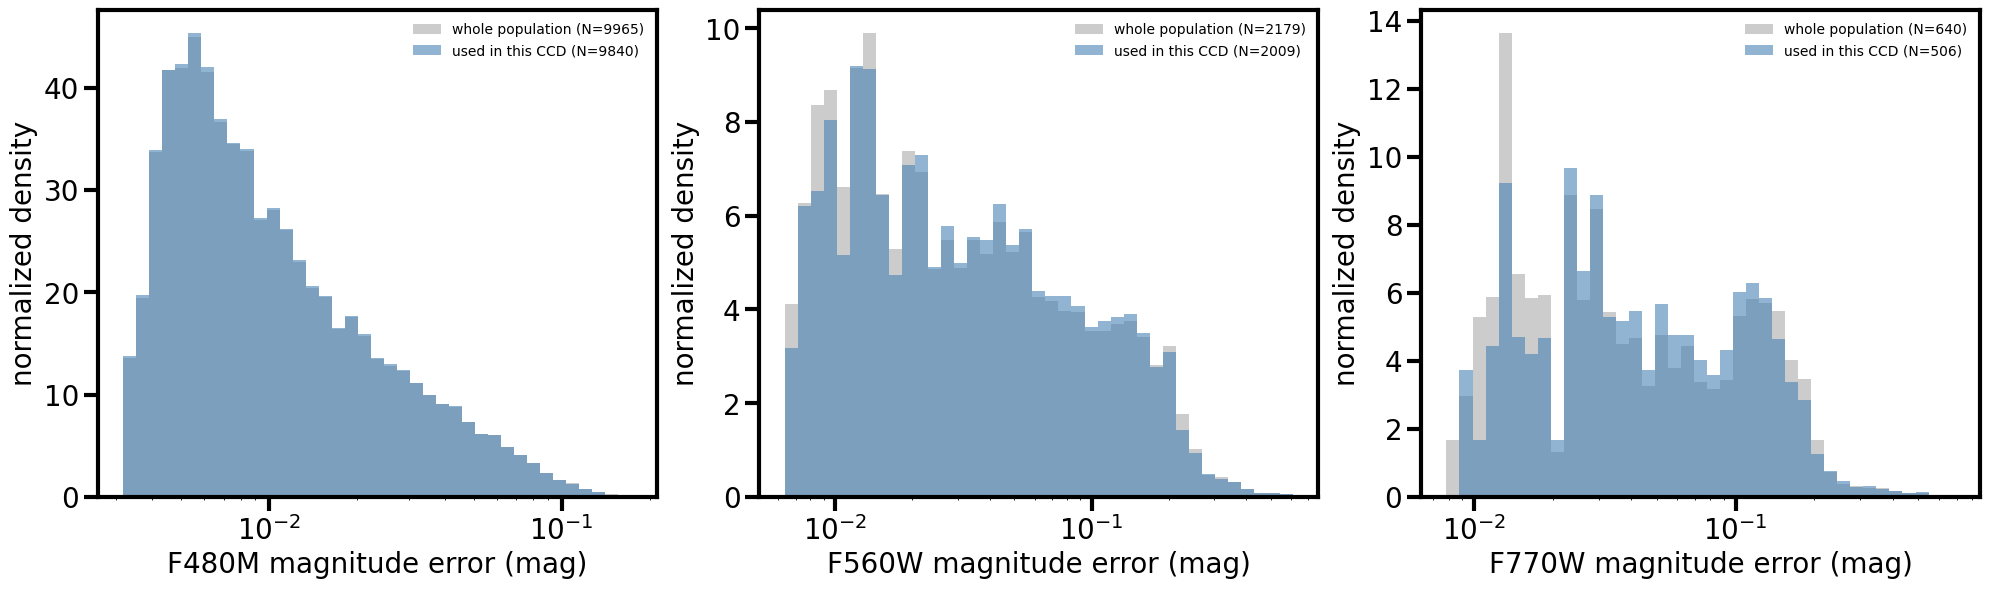

In [30]:
def err_hist(ax, err_used, err_all, band_label):
    err_used = np.asarray(err_used)
    err_all = np.asarray(err_all)
    err_used = err_used[np.isfinite(err_used) & (err_used > 0)]
    err_all = err_all[np.isfinite(err_all) & (err_all > 0)]

    lo = max(np.nanpercentile(err_all, 0.5), 1e-4)
    hi = np.nanpercentile(err_all, 99.5)
    bins = np.logspace(np.log10(lo), np.log10(hi), 40)

    ax.hist(err_all, bins=bins, density=True, alpha=0.4, color='0.5',
            label=f'whole population (N={len(err_all)})')
    ax.hist(err_used, bins=bins, density=True, alpha=0.6, color='steelblue',
            label=f'used in this CCD (N={len(err_used)})')
    ax.set_xscale('log')
    ax.set_xlabel(f'{band_label} magnitude error (mag)')
    ax.set_ylabel('normalized density')
    ax.legend(fontsize=10, frameon=False)

    print(f'{band_label}: median error -- whole population = {np.median(err_all):.4f} mag,'
          f'  used-in-CCD subset = {np.median(err_used):.4f} mag')

# sources used in this diagram: finite F410M and F480M magnitude
used_mask = (f410>0) & (f480>0)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
err_hist(axes[0], magerrs['f480m'][used_mask], magerrs['f480m'], 'F480M')
err_hist(axes[1], magerrs['f560w'][used_mask], magerrs['f560w'], 'F560W')
err_hist(axes[2], magerrs['f770w'][used_mask], magerrs['f770w'], 'F770W')
plt.tight_layout()
plt.savefig('magerr_hist_used_vs_population_cfit003.png', bbox_inches='tight')
plt.show()


## Color-color diagrams, color-coded by the x-axis color's photometric error

Same two color-color diagrams as above (F480M-F560W and F480M-F770W, both
vs. F410M-F480M), but each source's marker is now colored by its own
x-axis color error (`sigma_x` / `sigma_x_770`, the quadrature sum of the
F480M and respective MIRI-band magnitude errors) instead of plain gray.
This makes it possible to see directly whether sources in the
"unreachable by BB+extinction" zone (or otherwise scattered off the
blackbody locus) are disproportionately the ones with the least reliable
x-axis color, versus a genuine population effect.


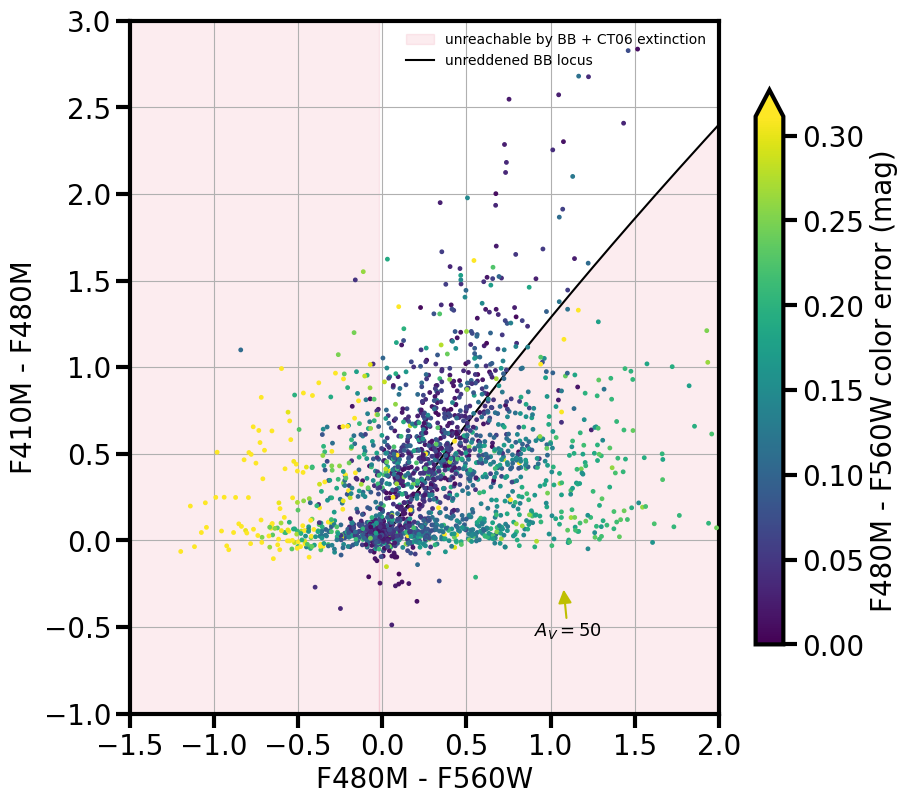

In [31]:
finite_err560 = np.isfinite(color_x) & np.isfinite(color_y) & np.isfinite(sigma_x)
vmax560 = np.nanpercentile(sigma_x[finite_err560], 95)

fig = plt.figure(figsize=(9.5, 9))
ax = fig.add_subplot(111)

ylo = -1.5
ax.fill_between(bb_x_sorted, ylo, bb_y_sorted, color='crimson', alpha=0.08, zorder=0,
                 label='unreachable by BB + CT06 extinction')
ax.axvspan(-2.5, bb_x_sorted.min(), color='crimson', alpha=0.08, zorder=0)
ax.plot(bb_x_sorted, bb_y_sorted, color='k', lw=1.5, zorder=2, label='unreddened BB locus')

sc = ax.scatter(color_x[finite_err560], color_y[finite_err560], c=sigma_x[finite_err560],
                 cmap='viridis', s=6, vmin=0, vmax=vmax560, zorder=3)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8, extend='max')
cbar.set_label('F480M - F560W color error (mag)')

plot_extvec_ccd(ax, ('f480m', 'f560w'), ('f410m', 'f480m'), ext,
                 extvec_scale=50, start=(0.9, -0.55), color='y')

ax.grid()
ax.set_xlabel('F480M - F560W')
ax.set_ylabel('F410M - F480M')
ax.set_xlim(-1.5, 2)
ax.set_ylim(-1, 3)
ax.legend(fontsize=10, frameon=False, loc='upper right')
plt.savefig('ccd_410m480_480m560w_colorerr_cfit003.png', bbox_inches='tight')
plt.show()


### F480M − F770W vs F410M − F480M, color-coded by color error

Same construction, swapping in the F480M-F770W color and its error
(`sigma_x_770`).


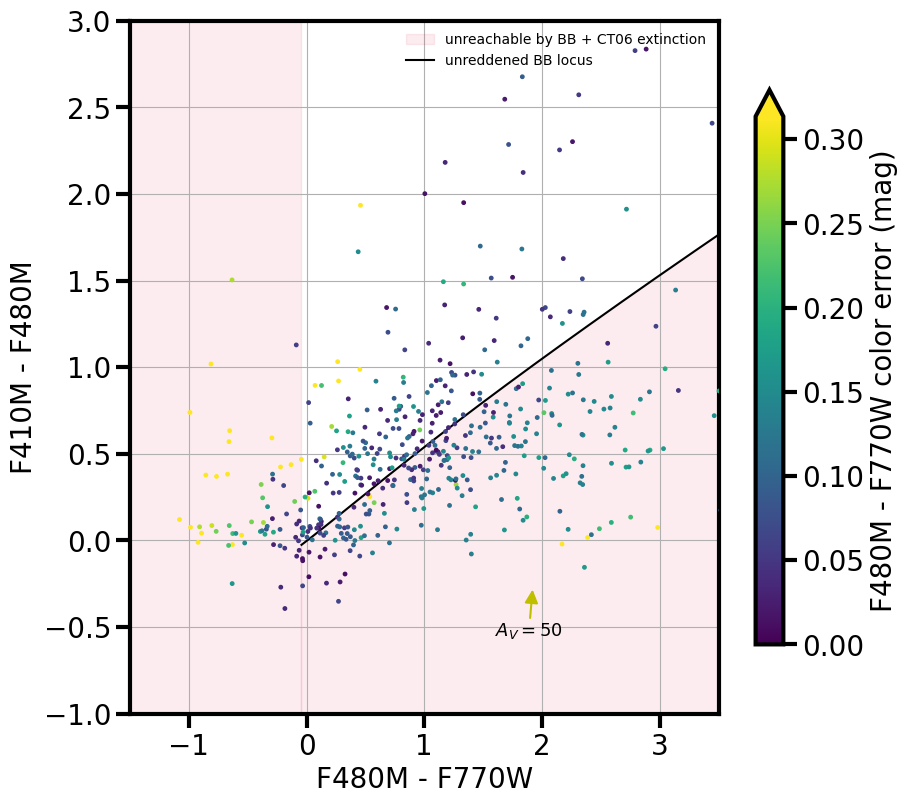

In [32]:
finite_err770 = np.isfinite(color_x_770) & np.isfinite(color_y_770) & np.isfinite(sigma_x_770)
vmax770 = np.nanpercentile(sigma_x_770[finite_err770], 95)

fig = plt.figure(figsize=(9.5, 9))
ax = fig.add_subplot(111)

ylo = -1.5
ax.fill_between(bb_x_770_sorted, ylo, bb_y_770_sorted, color='crimson', alpha=0.08, zorder=0,
                 label='unreachable by BB + CT06 extinction')
ax.axvspan(-2.5, bb_x_770_sorted.min(), color='crimson', alpha=0.08, zorder=0)
ax.plot(bb_x_770_sorted, bb_y_770_sorted, color='k', lw=1.5, zorder=2, label='unreddened BB locus')

sc = ax.scatter(color_x_770[finite_err770], color_y_770[finite_err770], c=sigma_x_770[finite_err770],
                 cmap='viridis', s=6, vmin=0, vmax=vmax770, zorder=3)
cbar = plt.colorbar(sc, ax=ax, shrink=0.8, extend='max')
cbar.set_label('F480M - F770W color error (mag)')

plot_extvec_ccd(ax, ('f480m', 'f770w'), ('f410m', 'f480m'), ext,
                 extvec_scale=50, start=(1.6, -0.55), color='y')

ax.grid()
ax.set_xlabel('F480M - F770W')
ax.set_ylabel('F410M - F480M')
ax.set_xlim(-1.5, 3.5)
ax.set_ylim(-1, 3)
ax.legend(fontsize=10, frameon=False, loc='upper right')
plt.savefig('ccd_410m480_480m770w_colorerr_cfit003.png', bbox_inches='tight')
plt.show()


## Color-color diagrams, color-coded by individual-band magnitude error

Same two color-color diagrams again, but now each is shown three times,
color-coded in turn by the F480M, F560W, and F770W magnitude error
(`magerrs['f480m']`, `magerrs['f560w']`, `magerrs['f770w']`) individually,
rather than the combined x-axis color error used above. This isolates which
single band's photometric noise is actually responsible for any given
source's scatter off the blackbody locus, rather than the F480M+MIRI
quadrature sum.


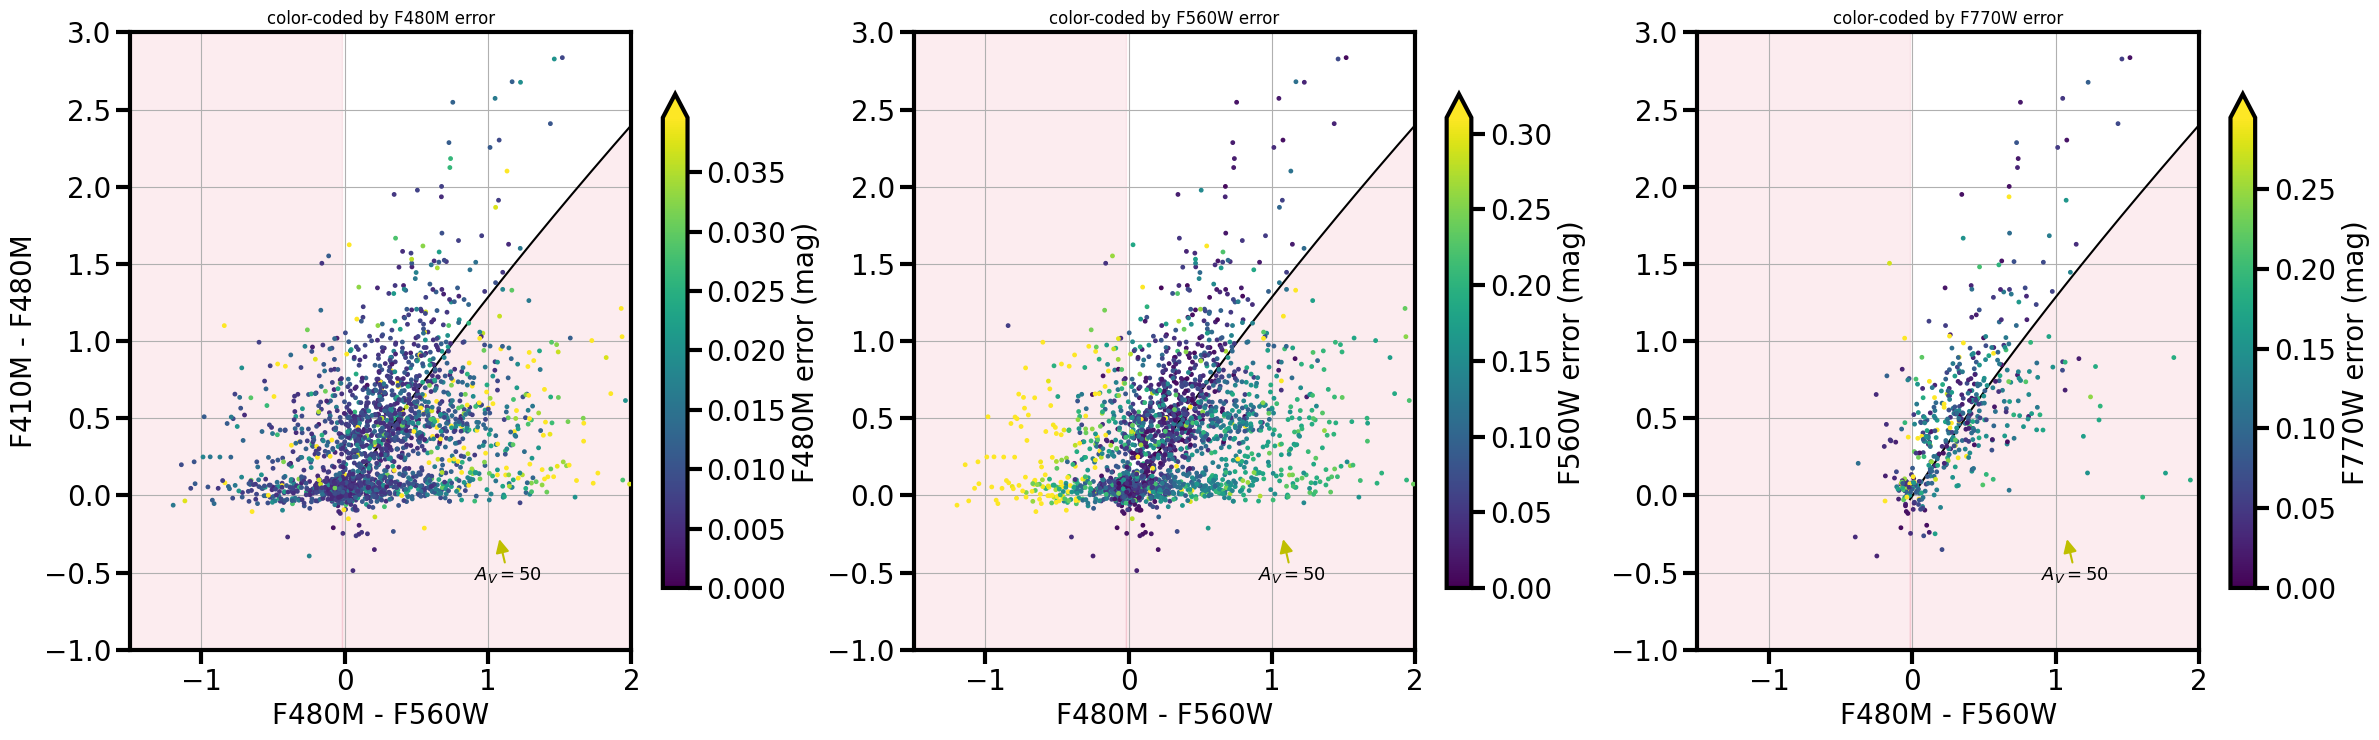

In [33]:
def plot_ccd_by_magerr(ax, cx, cy, err, bb_x_s, bb_y_s, xlim, ylim, cbar_label,
                        vec_color1, vec_color2, vec_start, panel_title):
    finite = np.isfinite(cx) & np.isfinite(cy) & np.isfinite(err)
    vmax = np.nanpercentile(err[finite], 95)

    ylo = -1.5
    ax.fill_between(bb_x_s, ylo, bb_y_s, color='crimson', alpha=0.08, zorder=0)
    ax.axvspan(-2.5, bb_x_s.min(), color='crimson', alpha=0.08, zorder=0)
    ax.plot(bb_x_s, bb_y_s, color='k', lw=1.5, zorder=2)

    sc = ax.scatter(cx[finite], cy[finite], c=err[finite], cmap='viridis',
                     s=6, vmin=0, vmax=vmax, zorder=3)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.8, extend='max')
    cbar.set_label(cbar_label)

    plot_extvec_ccd(ax, vec_color1, vec_color2, ext, extvec_scale=50,
                     start=vec_start, color='y')
    ax.grid()
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(panel_title, fontsize=12)

fig, axes = plt.subplots(1, 3, figsize=(24, 7.5))
for ax, band, label in zip(axes, ['f480m', 'f560w', 'f770w'],
                            ['F480M', 'F560W', 'F770W']):
    plot_ccd_by_magerr(ax, color_x, color_y, magerrs[band], bb_x_sorted, bb_y_sorted,
                        xlim=(-1.5, 2), ylim=(-1, 3), cbar_label=f'{label} error (mag)',
                        vec_color1=('f480m', 'f560w'), vec_color2=('f410m', 'f480m'),
                        vec_start=(0.9, -0.55), panel_title=f'color-coded by {label} error')
    ax.set_xlabel('F480M - F560W')
axes[0].set_ylabel('F410M - F480M')
plt.tight_layout()
plt.savefig('ccd_410m480_480m560w_bandmagerr_cfit003.png', bbox_inches='tight')
plt.show()


### F480M − F770W vs F410M − F480M, same three magnitude-error panels


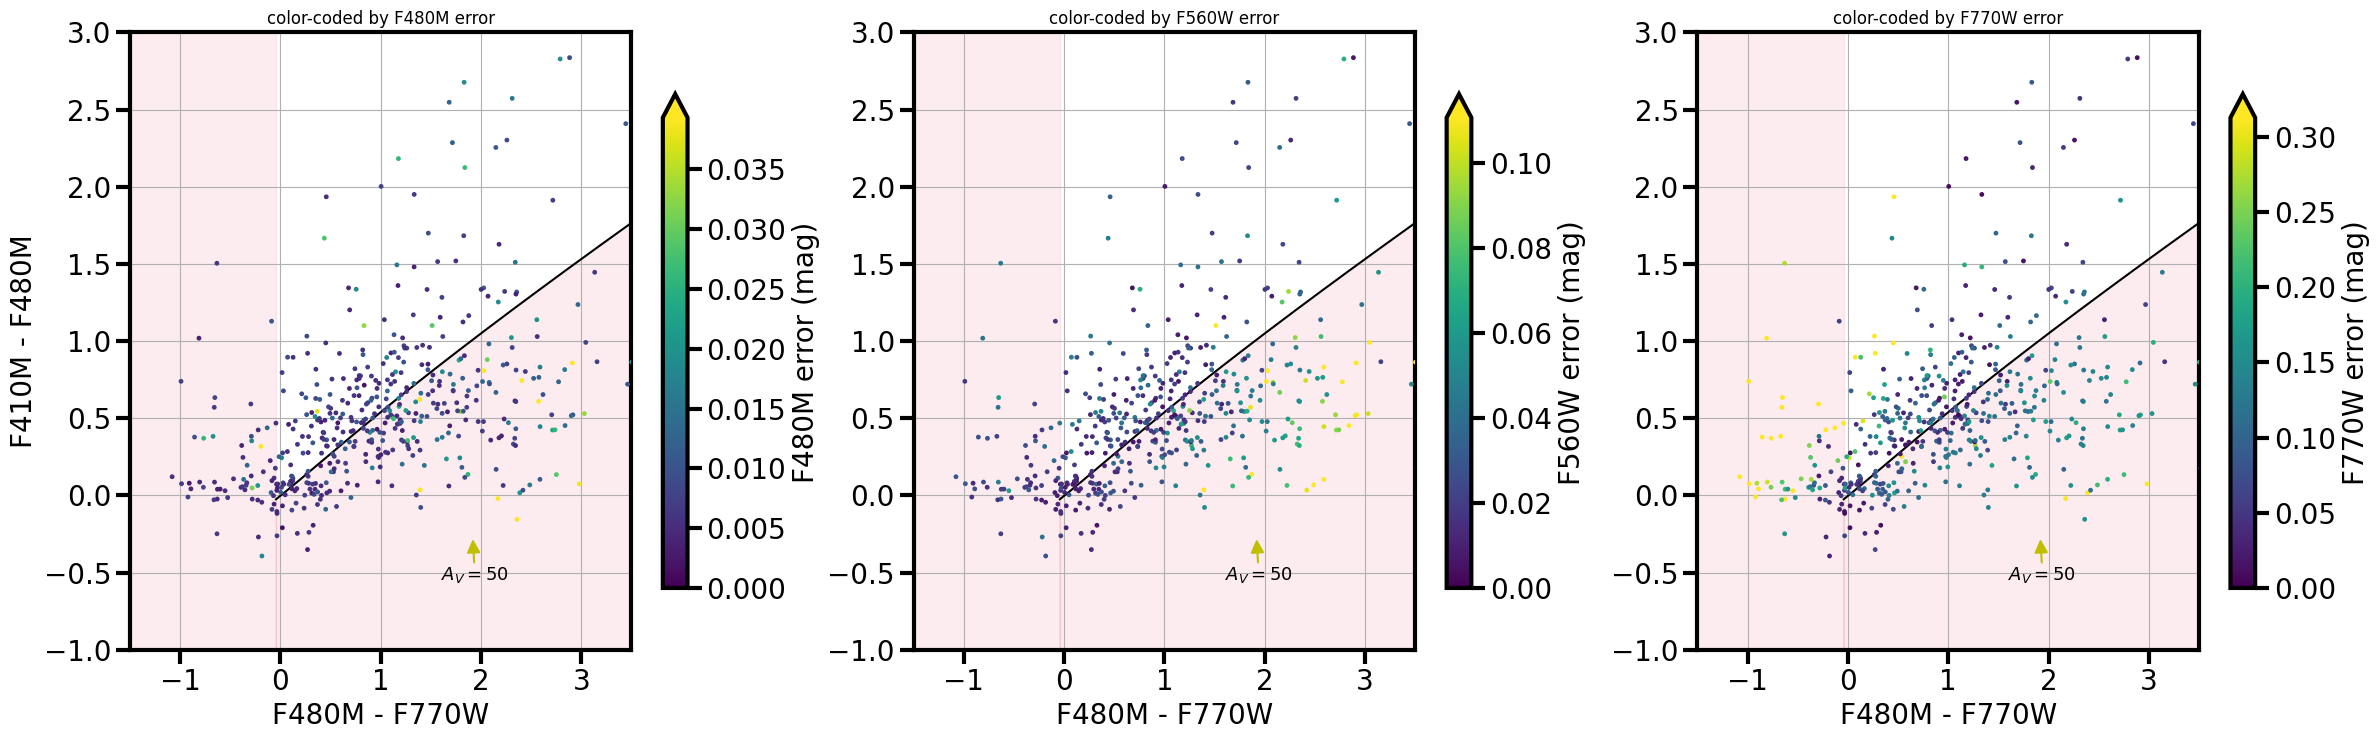

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7.5))
for ax, band, label in zip(axes, ['f480m', 'f560w', 'f770w'],
                            ['F480M', 'F560W', 'F770W']):
    plot_ccd_by_magerr(ax, color_x_770, color_y_770, magerrs[band], bb_x_770_sorted, bb_y_770_sorted,
                        xlim=(-1.5, 3.5), ylim=(-1, 3), cbar_label=f'{label} error (mag)',
                        vec_color1=('f480m', 'f770w'), vec_color2=('f410m', 'f480m'),
                        vec_start=(1.6, -0.55), panel_title=f'color-coded by {label} error')
    ax.set_xlabel('F480M - F770W')
axes[0].set_ylabel('F410M - F480M')
plt.tight_layout()
plt.savefig('ccd_410m480_480m770w_bandmagerr_cfit003.png', bbox_inches='tight')
plt.show()


## Color-color diagrams, color-coded by individual-band magnitude (brightness)

Same two color-color diagrams again, each shown three times, now color-coded
by the F480M, F560W, and F770W Vega magnitude itself (`mags['f480m']`,
`mags['f560w']`, `mags['f770w']`) rather than a photometric error -- to check
whether the scatter off the blackbody locus tracks source brightness (e.g.
faint sources scattering more, independent of their formal error bar) in
either band. Color scale uses `viridis_r` so brighter (lower-magnitude)
sources plot yellow and fainter ones plot dark purple, and is clipped to the
2nd-98th percentile of each band's magnitude so a few outliers don't wash out
the dynamic range.


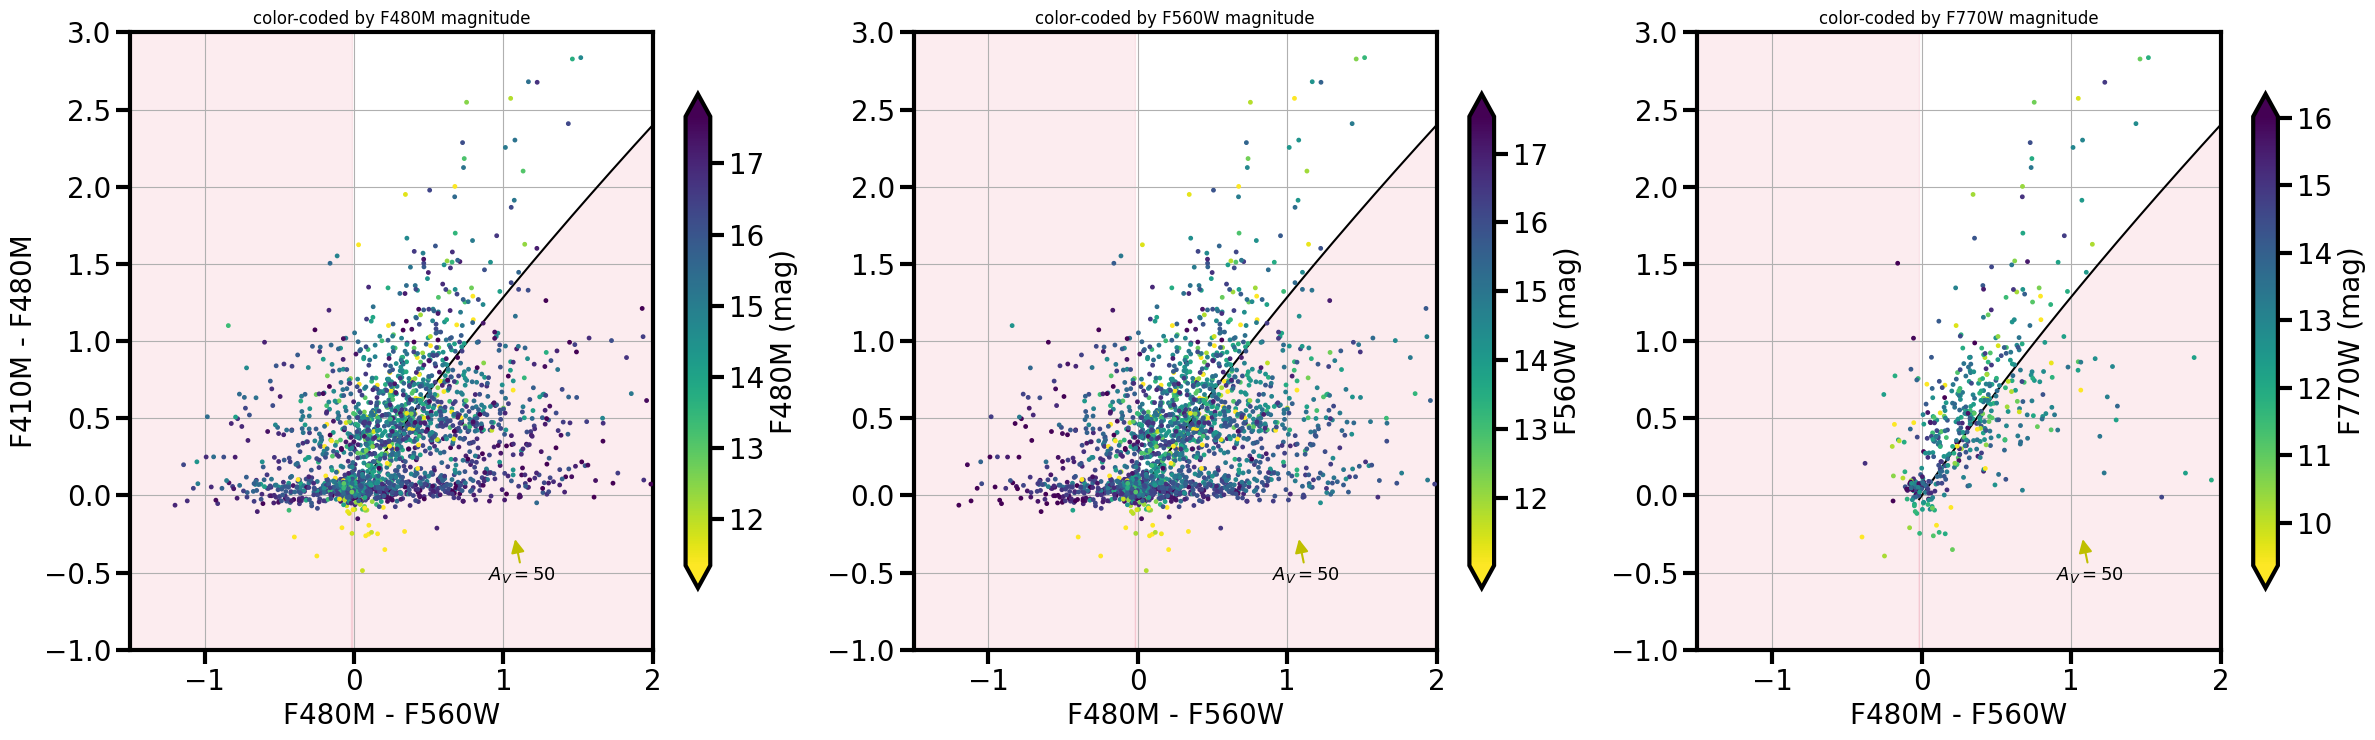

In [35]:
def plot_ccd_by_mag(ax, cx, cy, magval, bb_x_s, bb_y_s, xlim, ylim, cbar_label,
                     vec_color1, vec_color2, vec_start, panel_title):
    finite = np.isfinite(cx) & np.isfinite(cy) & np.isfinite(magval)
    vmin = np.nanpercentile(magval[finite], 2)
    vmax = np.nanpercentile(magval[finite], 98)

    ylo = -1.5
    ax.fill_between(bb_x_s, ylo, bb_y_s, color='crimson', alpha=0.08, zorder=0)
    ax.axvspan(-2.5, bb_x_s.min(), color='crimson', alpha=0.08, zorder=0)
    ax.plot(bb_x_s, bb_y_s, color='k', lw=1.5, zorder=2)

    sc = ax.scatter(cx[finite], cy[finite], c=magval[finite], cmap='viridis_r',
                     s=6, vmin=vmin, vmax=vmax, zorder=3)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.8, extend='both')
    cbar.set_label(cbar_label)

    plot_extvec_ccd(ax, vec_color1, vec_color2, ext, extvec_scale=50,
                     start=vec_start, color='y')
    ax.grid()
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_title(panel_title, fontsize=12)

fig, axes = plt.subplots(1, 3, figsize=(24, 7.5))
for ax, band, label in zip(axes, ['f480m', 'f560w', 'f770w'],
                            ['F480M', 'F560W', 'F770W']):
    plot_ccd_by_mag(ax, color_x, color_y, mags[band], bb_x_sorted, bb_y_sorted,
                     xlim=(-1.5, 2), ylim=(-1, 3), cbar_label=f'{label} (mag)',
                     vec_color1=('f480m', 'f560w'), vec_color2=('f410m', 'f480m'),
                     vec_start=(0.9, -0.55), panel_title=f'color-coded by {label} magnitude')
    ax.set_xlabel('F480M - F560W')
axes[0].set_ylabel('F410M - F480M')
plt.tight_layout()
plt.savefig('ccd_410m480_480m560w_bandmag_cfit003.png', bbox_inches='tight')
plt.show()


### F480M − F770W vs F410M − F480M, same three magnitude panels


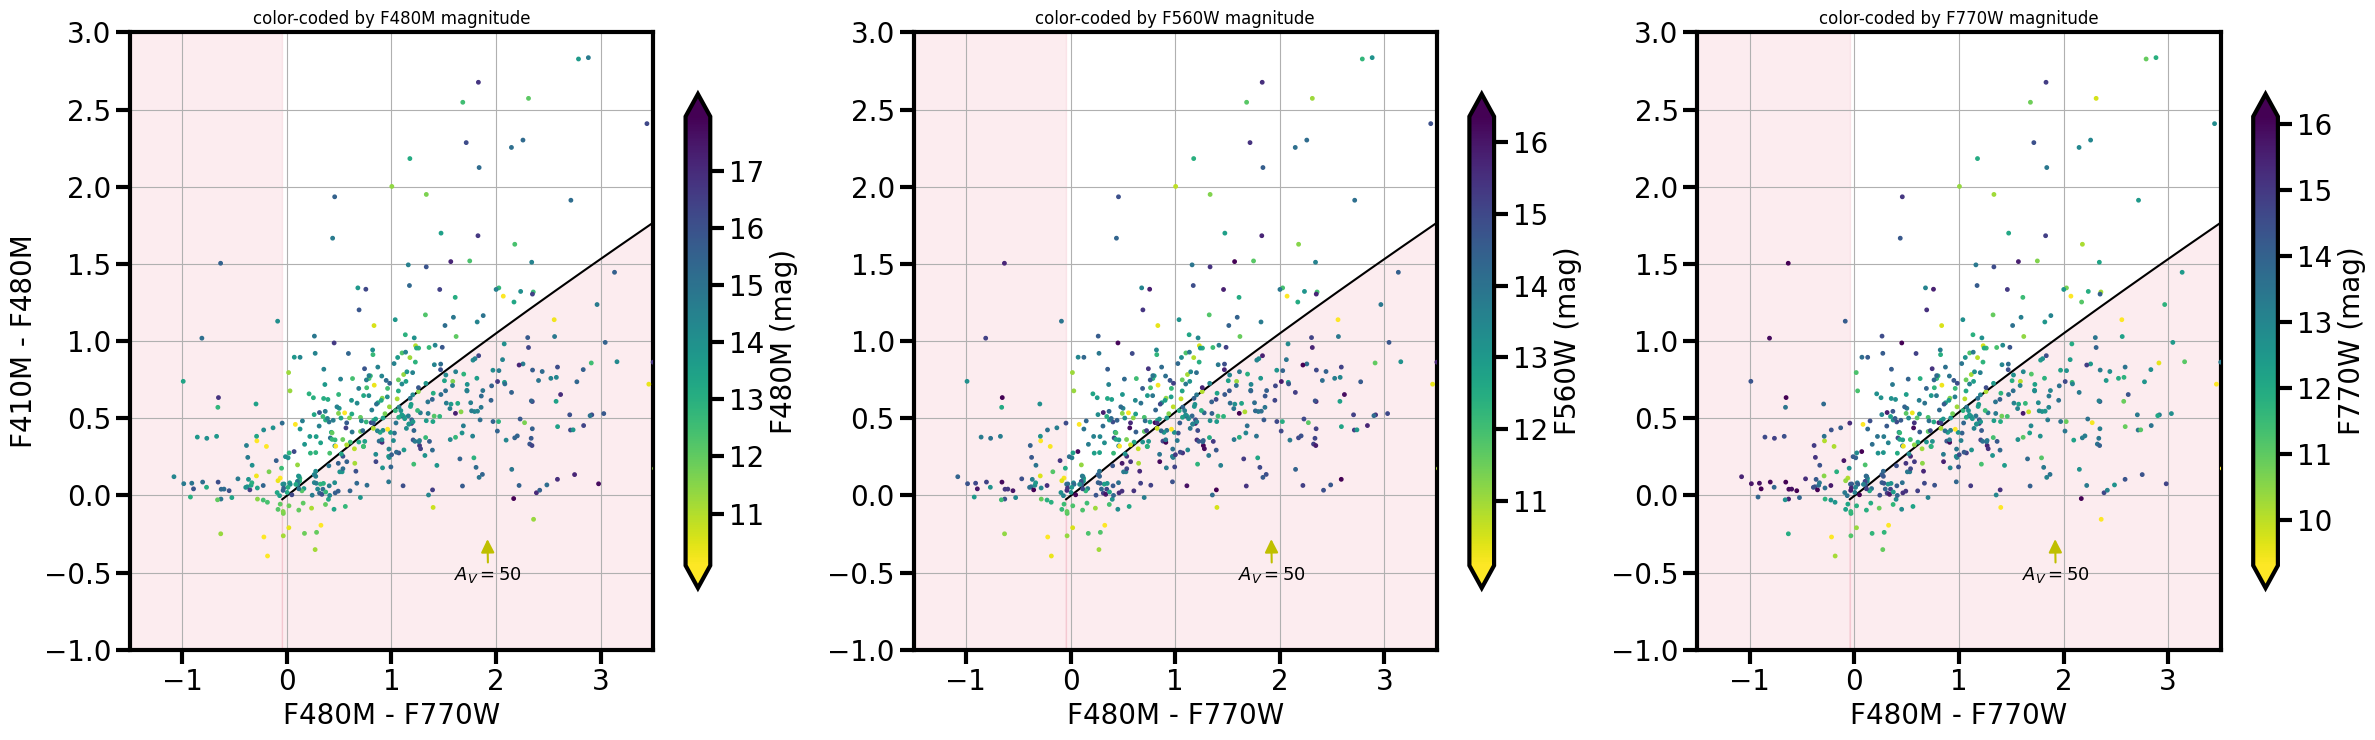

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7.5))
for ax, band, label in zip(axes, ['f480m', 'f560w', 'f770w'],
                            ['F480M', 'F560W', 'F770W']):
    plot_ccd_by_mag(ax, color_x_770, color_y_770, mags[band], bb_x_770_sorted, bb_y_770_sorted,
                     xlim=(-1.5, 3.5), ylim=(-1, 3), cbar_label=f'{label} (mag)',
                     vec_color1=('f480m', 'f770w'), vec_color2=('f410m', 'f480m'),
                     vec_start=(1.6, -0.55), panel_title=f'color-coded by {label} magnitude')
    ax.set_xlabel('F480M - F770W')
axes[0].set_ylabel('F410M - F480M')
plt.tight_layout()
plt.savefig('ccd_410m480_480m770w_bandmag_cfit003.png', bbox_inches='tight')
plt.show()


## Color-color diagram: F480M − F2100W vs F162M − F210M

Extending the analysis to the longest-wavelength MIRI band available in this
catalog, F2100W (also has F1280W, which could be substituted the same way).
F162M−F210M (x-axis) is the same near-IR reddening color used throughout
this project's CMD/CCD notebooks; F480M−F2100W (y-axis) is a new, much
longer-baseline mid-IR excess color. The same three populations from
`color_magnitude_diagram_cleancat.ipynb` (`upper_idx`, `lower_idx`,
`missing_nir_idx_red`, all already defined earlier in this notebook) are
overlaid.

**Caveat:** the "very red / NIR-dropout" population (`missing_nir_idx_red`)
is defined by having *no* F162M or F210M detection at all -- exactly the
axis used for x here. So by construction it cannot appear on this specific
projection (its x-value is undefined/NaN for every one of its members); the
scatter call for it is kept below for consistency with the other overlay
cells, but it will contribute zero visible points, which the printed count
also confirms explicitly.


Set DATE-AVG to '2024-09-08T11:55:48.768' from MJD-AVG.
Set DATE-END to '2024-09-08T13:08:42.701' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.785099 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291756623.231 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


f2100w zero point (Vega) = 9.0643990726832 Jy  n finite = 36
10 sources have finite F162M-F210M & F480M-F2100W colors
  of which upper branch: 6, lower branch: 3, very red/NIR-dropout: 0 (0 expected -- see caveat above)


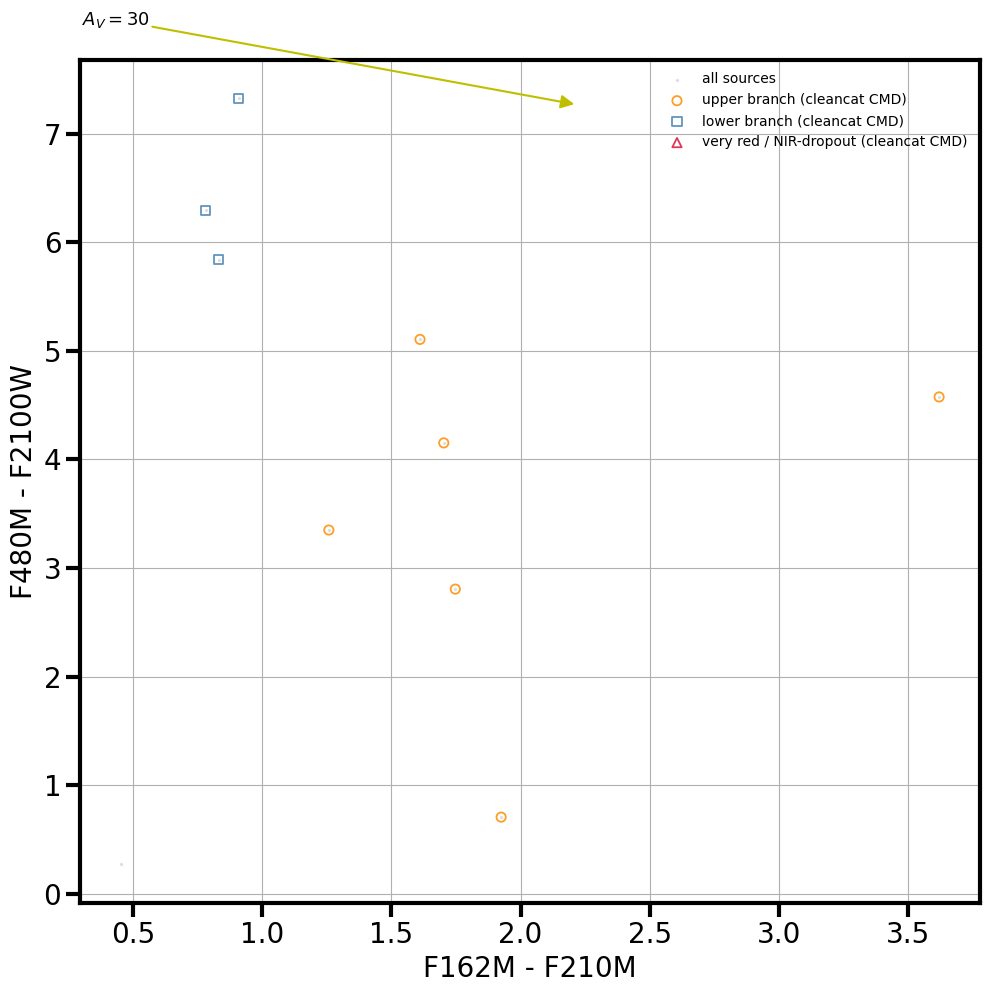

In [37]:
f2100w_path = '/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits'
header_2100 = fits.getheader(f2100w_path, ext=('SCI', 1))
wcs_2100 = WCS(header_2100)
f2100, f2100err, zp_2100 = get_mag(catalog, wcs_2100, 'f2100w')
print('f2100w zero point (Vega) =', zp_2100, ' n finite =', np.isfinite(f2100).sum())

color_x_2100 = f162 - f210     # F162M - F210M
color_y_2100 = f480 - f2100    # F480M - F2100W
finite_2100 = np.isfinite(color_x_2100) & np.isfinite(color_y_2100)
print(f'{finite_2100.sum()} sources have finite F162M-F210M & F480M-F2100W colors')
print(f'  of which upper branch: {(upper_idx & finite_2100).sum()},'
      f' lower branch: {(lower_idx & finite_2100).sum()},'
      f' very red/NIR-dropout: {(missing_nir_idx_red & finite_2100).sum()}'
      ' (0 expected -- see caveat above)')

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(color_x_2100, color_y_2100, s=2, c='0.8', alpha=0.5, label='all sources')

ax.scatter(color_x_2100[upper_idx], color_y_2100[upper_idx], s=45, marker='o', facecolor='none',
           edgecolor='darkorange', linewidth=1.3, alpha=0.85, label='upper branch (cleancat CMD)')
ax.scatter(color_x_2100[lower_idx], color_y_2100[lower_idx], s=45, marker='s', facecolor='none',
           edgecolor='steelblue', linewidth=1.3, alpha=0.85, label='lower branch (cleancat CMD)')
ax.scatter(color_x_2100[missing_nir_idx_red], color_y_2100[missing_nir_idx_red], s=45, marker='^',
           facecolor='none', edgecolor='crimson', linewidth=1.3, alpha=0.85,
           label='very red / NIR-dropout (cleancat CMD)')

plot_extvec_ccd(ax, ('f162m', 'f210m'), ('f480m', 'f2100w'), ext,
                 extvec_scale=30, start=(0.3, 8), color='y')

ax.grid()
ax.set_xlabel('F162M - F210M')
ax.set_ylabel('F480M - F2100W')
ax.legend(fontsize=10, frameon=False, loc='upper right')
plt.tight_layout()
plt.savefig('ccd_162m210m_480m2100w_populations_cfit003.png', bbox_inches='tight')
plt.show()


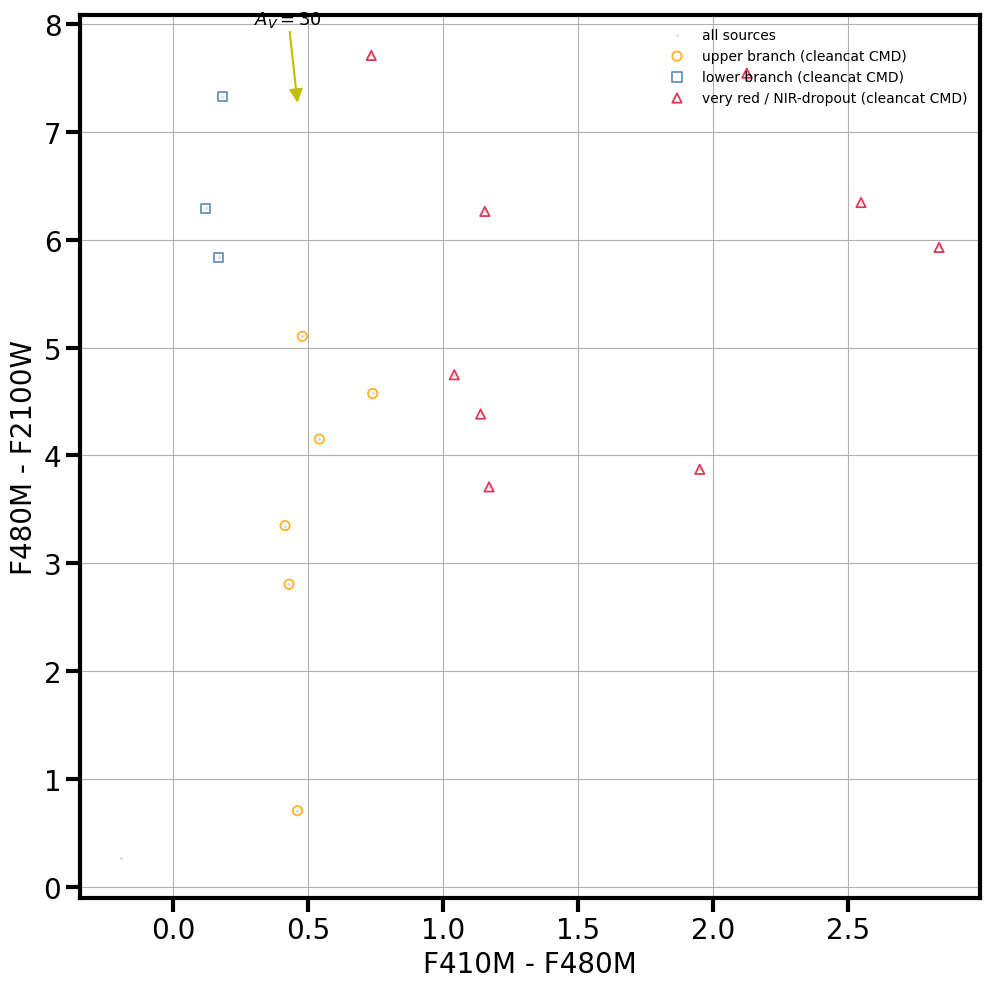

In [38]:
# 410-480 vs 480-2100
color_x_2100 = f410 - f480     # F162M - F210M
color_y_2100 = f480 - f2100   
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.scatter(color_x_2100, color_y_2100, s=2, c='0.8', alpha=0.5, label='all sources')
ax.scatter(color_x_2100[upper_idx], color_y_2100[upper_idx], s=45, marker='o', facecolor='none',
           edgecolor='orange', linewidth=1.3, alpha=0.85, label='upper branch (cleancat CMD)')
ax.scatter(color_x_2100[lower_idx], color_y_2100[lower_idx], s=45, marker='s', facecolor='none',
           edgecolor='steelblue', linewidth=1.3, alpha=0.85, label='lower branch (cleancat CMD)')
ax.scatter(color_x_2100[missing_nir_idx_red], color_y_2100[missing_nir_idx_red], s=45, marker='^', facecolor='none',
           edgecolor='crimson', linewidth=1.3, alpha=0.85, label='very red / NIR-dropout (cleancat CMD)')
plot_extvec_ccd(ax, ('f410m', 'f480m'), ('f480m', 'f2100w'), ext, extvec_scale=30, start=(0.3, 8), color='y')
ax.grid()
ax.set_xlabel('F410M - F480M')
ax.set_ylabel('F480M - F2100W')
ax.legend(fontsize=10, frameon=False, loc='upper right')
plt.tight_layout()
plt.savefig('ccd_410m480_480m2100w_populations_cfit003.png', bbox_inches='tight')
plt.show()  

## Who are the 3 "lower branch" sources with a huge F480M − F2100W color?

Only 3/2260 lower-branch ("bare star candidate") sources have any F2100W
measurement at all (F2100W is detected in just 36/15004 catalog sources
total), and all 3 show F480M-F2100W $\approx$ 5.8-7.3 mag. That is
*surprising* for sources classified as lightly-reddened bare photospheres:
a blackbody photosphere reddened by CT06 dust at any temperature and any
A$_V$ predicts F480M-F2100W $\approx -6$ mag (CT06's differential
extinction between these two very-far-apart bands is small and, if
anything, pushes the color bluer, not redder, with more A$_V$ -- see the
calculation below). So the observed colors are offset from the bare-star
prediction by roughly **12 magnitudes**, far beyond anything CT06 reddening
of a normal photosphere can produce -- the same "unreachable by BB+extinction"
argument used for the F560W/F770W diagrams above, just far more extreme here.

Checked below: (1) the intrinsic blackbody+CT06 prediction, confirming the
mismatch is real and not a units/sign error, and (2) F2100W/F480M image
cutouts at each of the 3 positions, to see whether this is a genuine
mid-IR excess or a photometry artifact.


In [39]:
print('CT06 extinction per unit A_V: F480M =', ext(1 / get_wave('f480m')),
      ' F2100W =', ext(1 / get_wave('f2100w')))
print('(F2100W is extinguished slightly MORE than F480M per unit A_V, so higher A_V'
      ' makes F480M-F2100W more NEGATIVE, i.e. it can only push the color the WRONG'
      ' way relative to the +6-7 mag observed here)')

from astropy.modeling.models import BlackBody
nu_480 = get_wave('f480m').to(u.Hz, equivalencies=u.spectral())
nu_2100 = get_wave('f2100w').to(u.Hz, equivalencies=u.spectral())
for T in [3000, 6000, 10000]:
    bb = BlackBody(temperature=T * u.K)
    color0 = (-2.5 * np.log10((bb(nu_480) / bb(nu_2100)).decompose().value)
              + 2.5 * np.log10(zp_2100.value / zps['f480m'].value))
    print(f'  predicted unreddened F480M-F2100W at T={T} K: {color0:.2f} mag')

color_x_410480 = f410 - f480
color_y_480_2100 = f480 - f2100
finite_410480_2100 = np.isfinite(color_x_410480) & np.isfinite(color_y_480_2100)
idx3 = np.where(lower_idx & finite_410480_2100)[0]
print()
print('The 3 lower-branch sources with a measured F2100W color:', idx3)

diag_cols = ['nmatch_bands', 'qfit_f480m', 'cfit_f480m', 'qfit_f2100w', 'cfit_f2100w',
             'nmatch_f2100w', 'nmatch_good_f2100w', 'local_bkg_f2100w', 'flux_fit_f2100w']
for i in idx3:
    print('-' * 60)
    print(f'idx {i}:  F480M-F2100W = {f480[i]-f2100[i]:.2f}   av_estimate = {av_estimate[i]:.1f}')
    for c in diag_cols:
        print(f'  {c}: {catalog[c][i]}')


CT06 extinction per unit A_V: F480M = 0.0484932  F2100W = 0.0728
(F2100W is extinguished slightly MORE than F480M per unit A_V, so higher A_V makes F480M-F2100W more NEGATIVE, i.e. it can only push the color the WRONG way relative to the +6-7 mag observed here)
  predicted unreddened F480M-F2100W at T=3000 K: -5.81 mag
  predicted unreddened F480M-F2100W at T=6000 K: -6.05 mag
  predicted unreddened F480M-F2100W at T=10000 K: -6.15 mag

The 3 lower-branch sources with a measured F2100W color: [2989 5991 8949]
------------------------------------------------------------
idx 2989:  F480M-F2100W = 5.84   av_estimate = 12.6
  nmatch_bands: 15
  qfit_f480m: 0.009626017360289776
  cfit_f480m: -0.00023302852418848768
  qfit_f2100w: 0.014084265619979634
  cfit_f2100w: -0.0007712653453827435
  nmatch_f2100w: 1
  nmatch_good_f2100w: 1
  local_bkg_f2100w: 451.85693359375
  flux_fit_f2100w: 8021.878734469142
------------------------------------------------------------
idx 5991:  F480M-F2100W = 6.2

### Image cutouts at the 3 positions (F2100W and F480M)

The 21 $\mu$m image is where the anomaly would have to originate (per the
color argument above), so this is the most direct check.


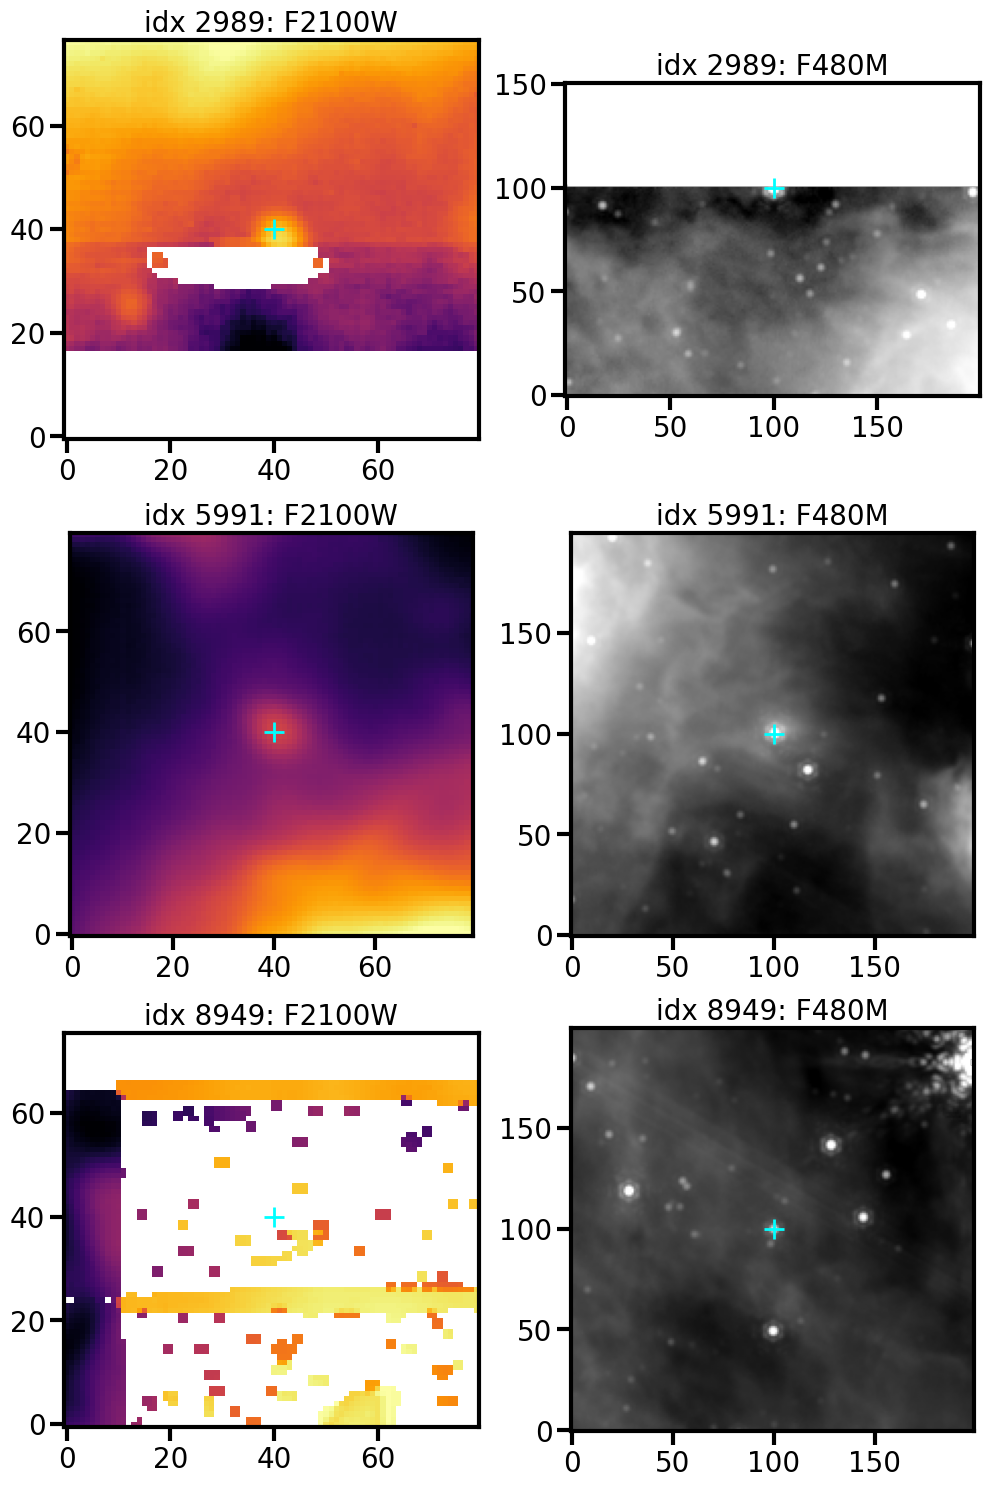

In [40]:
from astropy.visualization import simple_norm

f2100w_data = fits.getdata(f2100w_path, ext=('SCI', 1))
ra_all = catalog['skycoord_ref'].ra.deg
dec_all = catalog['skycoord_ref'].dec.deg

fig, axes = plt.subplots(3, 2, figsize=(10, 15))
box_2100, box_480 = 40, 100
for row, i in enumerate(idx3):
    x2100, y2100 = wcs_2100.all_world2pix(ra_all[i], dec_all[i], 0)
    x2100, y2100 = int(round(float(x2100))), int(round(float(y2100)))
    cut2100 = f2100w_data[max(0, y2100 - box_2100):y2100 + box_2100,
                           max(0, x2100 - box_2100):x2100 + box_2100]
    axes[row, 0].imshow(cut2100, origin='lower', cmap='inferno',
                         norm=simple_norm(cut2100, stretch='asinh', percent=99.5))
    axes[row, 0].plot(box_2100, box_2100, '+', color='cyan', markersize=15, markeredgewidth=2)
    axes[row, 0].set_title(f'idx {i}: F2100W')

    x480, y480 = wcs_f480m.all_world2pix(ra_all[i], dec_all[i], 0)
    x480, y480 = int(round(float(x480))), int(round(float(y480)))
    cut480 = f480m_data[max(0, y480 - box_480):y480 + box_480,
                         max(0, x480 - box_480):x480 + box_480]
    axes[row, 1].imshow(cut480, origin='lower', cmap='gray',
                         norm=simple_norm(cut480, stretch='asinh', percent=99.5))
    axes[row, 1].plot(box_480, box_480, '+', color='cyan', markersize=15, markeredgewidth=2)
    axes[row, 1].set_title(f'idx {i}: F480M')

plt.tight_layout()
plt.savefig('lower_branch_f2100w_cutouts_cfit003.png', bbox_inches='tight')
plt.show()


**Verdict, source by source (inspecting the cutouts above):**

- **idx 2989** -- the F2100W cutout position sits right on the sharp edge of
  a bright, structured diffuse rim (masked/NaN pixels immediately adjacent),
  not an isolated point source. The "detection" here is most likely the
  wings/edge of extended PDR emission that DAOStarFinder + PSF-fit picked up
  at this position, not photospheric flux from the star. **Likely artifact.**
- **idx 8949** -- the F2100W cutout around this position is dominated by
  masked/missing pixels (a data-quality gap), with almost no valid pixels
  right at the source location. Whatever flux was fit there is not a
  reliable point-source measurement. **Likely artifact / bad data region.**
- **idx 5991** -- the odd one out: a genuinely compact, isolated, roughly
  round peak in F2100W, coincident with a real, fairly bright point source
  in F480M, sitting on a smoothly-varying (not sharply structured)
  background. This one does not show the obvious artifact signature the
  other two do -- if any of these 3 is a real mid-IR excess on top of a bare
  photosphere, it is this source. It also happens to fall into a numerical
  gap in the F480M-F560W BB+extinction classifier above (`idx_excess` and
  `idx_bb_consistent` both `False`): its F480M-F560W color is just barely
  bluer than the coldest blackbody grid point, so the residual interpolation
  returns NaN there rather than a clean classification -- an existing edge
  case in that code, unrelated to the F2100W finding itself, but worth
  knowing before trusting its "excess" status in the earlier diagrams.

**Bottom line:** the surprise is largely explained by small-number, edge-case
photometry rather than a real population of mid-IR-excess bare stars: 2 of
the 3 sources sit on masked/structured background regions in F2100W, and
the third, while cleaner, is a single source -- not nearly enough to revise
the "bare star" interpretation of the lower branch as a whole. F2100W's
extreme shallowness (36/15004 sources detected at all) means this check
will always be limited to a handful of sources; it is not yet possible to
say whether idx 5991 represents a real, rare mid-IR-excess bare star or
one more borderline case.


## SED of source idx 5991 (the one likely-real F2100W excess from the lower-branch check)

Builds the full JWST SED for this one source from every band in the catalog
(`flux_fit_*`, converted to Jy the same way as `get_mag`, but keeping the flux
itself rather than just the magnitude), then checks it against ALMA and VLA.


In [41]:
all_bands = ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n',
             'f410m', 'f480m', 'f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']

# a couple of these bands aren't in `headers`/`image_filenames` yet (only used for
# this one-off SED), so their WCS is loaded directly here rather than touching the
# dicts built at the top of the notebook
extra_image_filenames = {
    "f140m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
}
all_image_filenames = {**image_filenames, **extra_image_filenames, 'f2100w': f2100w_path}

i_sed = 5991
sed = {}
for band in all_bands:
    hdr = fits.getheader(all_image_filenames[band], ext=('SCI', 1))
    ww = WCS(hdr)
    mag, magerr, zp_b = get_mag(catalog, ww, band)  # get_mag returns MAGNITUDES, not flux
    mag_i, magerr_i = mag[i_sed], magerr[i_sed]
    flux_i = zp_b * 10 ** (-0.4 * mag_i)          # convert back to Jy for the SED
    eflux_i = flux_i * magerr_i * np.log(10) / 2.5
    sed[band] = dict(wave=get_wave(band), flux=flux_i, eflux=eflux_i, zp=zp_b,
                      masked=bool(catalog[f'mask_{band}'][i_sed]) if f'mask_{band}' in catalog.colnames else None)
    print(f"{band:7s}  wave={sed[band]['wave']:6.2f}  flux={sed[band]['flux']:.4g}"
          f"  eflux={sed[band]['eflux']:.3g}  masked={sed[band]['masked']}")


Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T13:24:26.762' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.085' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.202551 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610191901.140 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/ad

f140m    wave=  1.40 um  flux=0.0004386 Jy  eflux=3.97e-06 Jy  masked=False
f162m    wave=  1.62 um  flux=0.0006904 Jy  eflux=5.06e-06 Jy  masked=False
f182m    wave=  1.82 um  flux=0.0008627 Jy  eflux=4.78e-06 Jy  masked=False
f187n    wave=  1.87 um  flux=0.0008978 Jy  eflux=3.27e-06 Jy  masked=False
f210m    wave=  2.10 um  flux=0.0009534 Jy  eflux=6.35e-06 Jy  masked=False
f335m    wave=  3.35 um  flux=0.0007014 Jy  eflux=5.59e-06 Jy  masked=False


Set OBSGEO-B to   -25.220310 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512065.053 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2025-05-06T13:24:26.757' from MJD-AVG.
Set DATE-END to '2025-05-06T13:48:04.021' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.2025

f360m    wave=  3.60 um  flux=0.0006802 Jy  eflux=4.2e-06 Jy  masked=False
f405n    wave=  4.05 um  flux=0.0006244 Jy  eflux=3.95e-06 Jy  masked=False
f410m    wave=  4.10 um  flux=0.0006134 Jy  eflux=4.16e-06 Jy  masked=False
f480m    wave=  4.80 um  flux=0.0005026 Jy  eflux=5.26e-06 Jy  masked=False
f560w    wave=  5.60 um  flux=0.0003643 Jy  eflux=1.1e-05 Jy  masked=False
f770w    wave=  7.70 um  flux=nan Jy  eflux=nan Jy  masked=True


f1000w   wave= 10.00 um  flux=0.0002151 Jy  eflux=1.06e-05 Jy  masked=False
f1280w   wave= 12.80 um  flux=nan Jy  eflux=nan Jy  masked=True
f2100w   wave= 21.00 um  flux=0.00978 Jy  eflux=0.000168 Jy  masked=False


Set DATE-AVG to '2024-09-08T11:31:04.265' from MJD-AVG.
Set DATE-END to '2024-09-08T12:43:52.463' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.803760 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291894033.527 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/blue/adamginsburg/t.yoo/from_red/miniconda3/envs/py311/lib/python3.11/site-packages/astropy/units/quantity.py:653: RuntimeWarning: invalid value encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
Set DATE-AVG to '2024-09-08T11:39:49.277' from MJD-AVG.
Set DATE-END to '2024-09-08T12:52:42.510' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.797166 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291845460.779 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-09-08T11:47:44.336' from MJD-AVG.
Set DATE-END to '2024-09-08T13:00:37.070' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    -3.791203 from OBSGEO-[XYZ].
Set OBSGEO-H to 1291801554.144 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '

### SED plot, with the extrapolated near/mid-IR continuum

Fits a simple power law (F$_\nu \propto \lambda^\alpha$) to the smoothly-declining
F140M-F560W points (all detected, monotonically falling with wavelength --
the part of the SED that looks like an ordinary reddened photosphere), then
extrapolates that fit out to F1000W and F2100W to quantify how far each
point sits above or below the naive continuum.


detected: ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m', 'f560w', 'f1000w', 'f2100w']
not detected (masked, no fit at this position): ['f770w', 'f1280w']
continuum fit (F140M-F560W only): Fnu ~ wave^-0.29


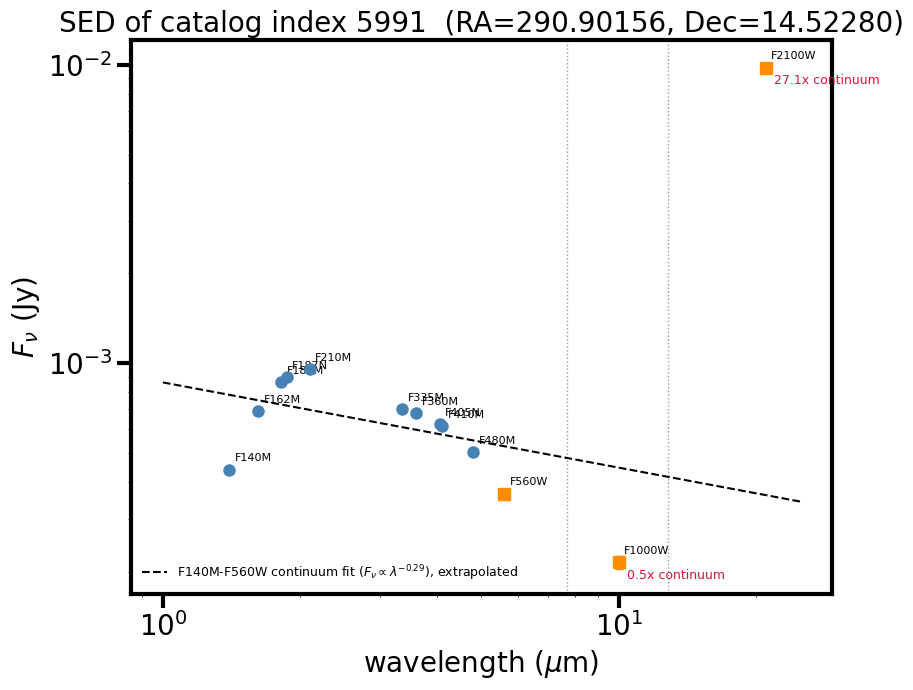

In [42]:
detected_bands = [b for b in all_bands if np.isfinite(sed[b]['flux'].value) and sed[b]['flux'].value > 0]
nondetected_bands = [b for b in all_bands if b not in detected_bands]
print('detected:', detected_bands)
print('not detected (masked, no fit at this position):', nondetected_bands)

fit_bands = ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n',
             'f410m', 'f480m', 'f560w']
logw = np.array([np.log10(sed[b]['wave'].value) for b in fit_bands])
logf = np.array([np.log10(sed[b]['flux'].value) for b in fit_bands])
alpha, intercept = np.polyfit(logw, logf, 1)
print(f'continuum fit (F140M-F560W only): Fnu ~ wave^{alpha:.2f}')

wave_grid = np.logspace(np.log10(1.0), np.log10(25), 200)
continuum_grid = 10 ** (alpha * np.log10(wave_grid) + intercept)

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(wave_grid, continuum_grid, 'k--', lw=1.5,
        label=r'F140M-F560W continuum fit ($F_\nu \propto \lambda^{%.2f}$), extrapolated' % alpha)

for b in detected_bands:
    marker = 'o' if int(b[1:-1]) < 500 else 's'
    color = 'steelblue' if int(b[1:-1]) < 500 else 'darkorange'
    ax.errorbar(sed[b]['wave'].value, sed[b]['flux'].value, yerr=sed[b]['eflux'].value,
                fmt=marker, color=color, markersize=8, capsize=3, zorder=3)
    ax.annotate(b.upper(), (sed[b]['wave'].value, sed[b]['flux'].value), fontsize=8,
                textcoords='offset points', xytext=(4, 6))

ylo, yhi = ax.get_ylim()
for b in nondetected_bands:
    ax.axvline(sed[b]['wave'].value, color='0.6', ls=':', lw=1, zorder=1)
    ax.annotate(f'{b.upper()}\n(no detection)', (sed[b]['wave'].value, ylo), fontsize=8,
                color='0.4', ha='center', va='bottom', rotation=90)

for b in ['f1000w', 'f2100w']:
    w = sed[b]['wave'].value
    pred = 10 ** (alpha * np.log10(w) + intercept)
    obs = sed[b]['flux'].value
    ratio = obs / pred
    ax.annotate(f'{ratio:.1f}x continuum', (w, obs), fontsize=9, color='crimson',
                textcoords='offset points', xytext=(6, -12))

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'wavelength ($\mu$m)')
ax.set_ylabel(r'$F_\nu$ (Jy)')
ax.legend(fontsize=9, frameon=False, loc='lower left')
ax.set_title(f'SED of catalog index {i_sed}  (RA={catalog["skycoord_ref"][i_sed].ra.deg:.5f},'
             f' Dec={catalog["skycoord_ref"][i_sed].dec.deg:.5f})')
plt.tight_layout()
plt.savefig('sed_idx5991_cfit003.png', bbox_inches='tight')
plt.show()


**Analysis:** F140M through F560W (1.4-5.6 $\mu$m) declines smoothly and
monotonically with wavelength, consistent with an ordinary reddened stellar
photosphere (this is exactly why the near-IR color classified it as a
"lower branch" / bare-star candidate). F770W and F1280W have no detection at
all at this position (masked, not just faint). Then F1000W sits close to
the photospheric extrapolation, but **F2100W is a factor of ~27x (3.6 mag)
brighter than the extrapolated photospheric continuum** -- a sharp,
unambiguous rise, not a marginal excess. This is the classic SED signature
of a **YSO with warm circumstellar dust** (disk or envelope) that only
becomes visible once the SED extends far enough into the mid-IR: the
near-IR alone (which is where the "bare star" classification came from) is
dominated by direct/scattered photospheric light and cannot see this
component. So this specific source is most plausibly a genuine young
stellar object with a mid-IR excess, misclassified as a bare photosphere by
a method that only had near-IR colors to work with -- not a bare star after
all, and not (as considered above) an obvious photometry artifact either,
since the detection is clean, isolated, and well-fit (`qfit_f2100w` and
`cfit_f2100w` both nominal) in both the flux table and the image cutout.


### ALMA / VLA cross-match for this source


In [43]:
sc_5991 = SkyCoord(ra=catalog['skycoord_ref'].ra[i_sed], dec=catalog['skycoord_ref'].dec[i_sed])

def nearest_match(cat_path, ra_col, dec_col, name):
    tab = Table.read(cat_path)
    ra = np.asarray(tab[ra_col], dtype=float)
    dec = np.asarray(tab[dec_col], dtype=float)
    finite = np.isfinite(ra) & np.isfinite(dec)
    tab = tab[finite]
    sc = SkyCoord(ra=ra[finite] * u.deg, dec=dec[finite] * u.deg)
    sep = sc_5991.separation(sc)
    jmin = np.argmin(sep)
    print(f'{name}: nearest source is {sep[jmin].to(u.arcsec):.2f} away'
          f' ({len(tab)} sources in catalog) -- no match within the standard 0.1\" merge radius')
    return sep[jmin]

nearest_match('/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51e_master.fits',
              'ra', 'dec', 'ALMA W51e (dendro)')
nearest_match('/blue/adamginsburg/t.yoo/from_red/w51/w51_frag_new/dendro/tables/dendro_w51n_master.fits',
              'ra', 'dec', 'ALMA W51n (dendro)')
nearest_match('/blue/adamginsburg/t.yoo/w51_nircam/analysis/vla_updated_with_radius.fits',
              'GRAdeg', 'GDEdeg', 'VLA')


ALMA W51e (dendro): nearest source is 89.27 arcsec away (118 sources in catalog) -- no match within the standard 0.1" merge radius
ALMA W51n (dendro): nearest source is 19.99 arcsec away (93 sources in catalog) -- no match within the standard 0.1" merge radius
VLA: nearest source is 9.36 arcsec away (471 sources in catalog) -- no match within the standard 0.1" merge radius


<Angle 0.00260135 deg>

**No ALMA or VLA counterpart.** The nearest ALMA (W51e and W51n dendrogram)
and VLA sources are all several arcseconds to tens of arcseconds away --
nowhere close to the 0.1" merge radius used everywhere else in this
notebook. So this source has no (sub)mm dust continuum or radio detection at
the depth/resolution of those surveys. That's not inconsistent with the
YSO-with-disk interpretation above -- a modest disk/envelope mass around a
single low-to-intermediate-mass young star can easily fall below current
ALMA/VLA continuum sensitivity in this field, especially if it is relatively
isolated (as the image cutouts above suggested) rather than embedded in one
of the dense cores those surveys were built to catalog.
